## Two-Stage Flight Delay Prediction Pipeline (60M OTPW)

**Goal:** Predict flight departure delays **2 hours before departure** using a connected two-stage approach on 31.2M flights from the 60-month OTPW dataset.

---

### Pipeline Architecture

| Stage | Task | Target | Models | Primary Metrics |
| --- | --- | --- | --- | --- |
| **Stage 1** | Binary Classification | `DEP_DEL15` (delayed >=15 min?) | LR, RF, GBT | AUC-ROC, AUC-PR, F1, Precision, Recall |
| **Stage 2** | Regression (delayed flights only) | `DEP_DELAY` (minutes) | Linear Reg, RF, GBT | RMSE, MAE, MAPE |

**Connected Pipeline Flow:**
1. **Stage 1** classifies ALL flights → predicts `DEP_DEL15`
2. Flights predicted as delayed (pred=1) AND actually delayed (`DEP_DEL15 = 1`) are **fed into Stage 2**
3. **Stage 2** predicts delay duration in minutes using 2 clipping variants (P99, No Clip)

---

### Data Overview

| Item | Value |
| --- | --- |
| **Source** | `OTPW_60M_Backup/` (60-month On-Time Performance + Weather, parquet) |
| **Total rows** | 31,197,330 flights (Train 23,431,665 + Test 7,765,665) |
| **Raw columns** | 216 → 34 kept (pre-departure only, no leakage) |
| **Engineered columns** | 34 → \~70 (after feature engineering) |
| **Feature vector dim** | 823 (sparse, \~54 non-zeros per row → 15× memory savings vs dense, 93% sparse) |
| **Class imbalance** | 4.3:1 neg:pos in training set; Q4 test: 16.3% delayed |

### Data Split (Time-Series — No Random Splits)

| Split | Period | Rows | Usage |
| --- | --- | --- | --- |
| **Train + Validation** | Q1–Q3 (Jan–Sep) | 23,431,665 | Simple temporal train/val split |
| **Blind Test** | Q4 (Oct–Dec) | 7,765,665 | Final evaluation only — never seen during training |

**Temporal Train/Validation Split:**

The training set is partitioned into 5 temporal folds. Models train on folds 0–3 (months 1–8) and validate on fold 4 (month 9). The best configuration is then retrained on all folds (months 1–9) before blind test evaluation. This is a single temporal split (NOT expanding-window CV) — chosen because CrossValidator hangs on driver with high-dimensional sparse vectors.

| Fold | Months | Rows |
| --- | --- | --- |
| 0 | Jan–Feb | 4,709,322 |
| 1 | Mar–Apr | 5,243,343 |
| 2 | May–Jun | 5,383,764 |
| 3 | Jul–Aug | 5,563,407 |
| 4 (val) | Sep | 2,531,829 |

---

### Pipeline Steps

| Step | Cell | Description |
| --- | --- | --- |
| 0 | 2 | **Imports** — PySpark, ML, matplotlib, pandas, MLflow |
| 1 | 3 | **Configuration** — Paths, targets (`DEP_DEL15`, `DEP_DELAY`), feature lists, fold definitions |
| 2 | 4 | **Load Data** — Read 60M OTPW parquet (31,197,330 rows × 216 cols) |
| 3 | 5 | **Column Selection + Train/Test Split** — Keep 34 pre-departure columns, temporal Q1–Q3 / Q4 split |
| 4 | 6 | **Data Cleaning** — Cast weather strings to numeric, airport+month mean imputation (fallback: overall mean) |
| 5 | 7 | **Feature Engineering** — Time cyclical, weather composites, congestion/rolling, RFM (7/14/30d), target encoding, route |
| 6 | 8–9 | **Checkpoint 1 + Sparse Pipeline** — Save clean parquet, rebuild ML pipeline with `withMean=False` (sparse vectors, avoids OOM) |
| 7 | 10 | **Temporal Folds + Helper Functions** — Define `run_cv_classification`, `run_cv_regression`, `compute_class_weight_ratio` |
| 8a | 11 | **Stage 1: Logistic Regression** — Class-weighted, grid search (regParam, elasticNet) |
| 8b | 12 | **Stage 1: Random Forest** — Grid search (numTrees=[50,100], maxDepth=5) |
| 8c | 13 | **Stage 1: GBT** — Grid search (maxIter=[20,50], maxDepth=5, stepSize=0.1) |
| 9 | 14 | **Stage 1 Blind Test (Q4) + Checkpoint 2** — Evaluate all 3 classifiers, save models + CSV results |
| 9b–9e | 15–18 | **Stage 1 Undersampled** — Repeat 3 models with 1:1 undersampling, blind test, checkpoint |
| — | 19 | **Checkpoint 2 Reload** — Skip Stage 1, reload clean data + pipeline + saved models + results |
| — | 20 | **Classification vs Ground Truth Comparison** — Confusion matrix: predicted vs actual delayed |
| 10 | 22 | **Stage 2 Setup** — Percentile clipping (P99=359 min, No Clip), out-of-fold classifier for Approach B |
| 11 | 23 | **Stage 2 Regression Training** — 2 label variants × 2 approaches × 3 models = 12 models, CV RMSE + MAPE |
| 12 | 24 | **Stage 2 Blind Test (Q4) + Checkpoint 3** — Evaluate all 12 models on connected + GT test sets |
| 13 | 25 | **End-to-End Connected Pipeline** — Full Stage 1 → Stage 2 operational evaluation + stakeholder summary |
| 14 | 26 | **Visualizations** — Classification model comparison, regression GT vs connected, feature importance, CV vs blind |

---

### Feature Engineering Summary

| Category | Count | Features | Purpose |
| --- | --- | --- | --- |
| **Time** | 8 | dep_hour, cyclical hour/month (sin/cos), is_weekend, is_peak_hour, days_to_holiday | Temporal patterns |
| **Weather Composites** | 5 | dew_point_depression, has_precipitation, low_visibility, high_wind, weather_severity | Combined weather severity |
| **Congestion** | 4 | origin/dest/tail rolling delay rate, origin hourly flight count | Airport and aircraft cascade effects |
| **RFM** | 12 | 7d/14d/30d avg_delay, flight_freq, pct_delayed (origin + carrier) | Multi-horizon performance trends |
| **Target Encoding** | 4 | origin/dest/carrier/route avg delay rate | Historical delay propensity |
| **Categorical (OHE)** | 4 | OP_UNIQUE_CARRIER, ORIGIN, DEST, DEP_TIME_BLK | Airline, airport, time block |
| **Numeric (raw)** | \~19 | CRS_DEP_TIME, CRS_ARR_TIME, CRS_ELAPSED_TIME, DISTANCE, DISTANCE_GROUP, DAY_OF_MONTH, DAY_OF_WEEK, 12 weather measurements | Schedule and conditions |
| **Total numeric features** | 52 | All above (incl 12 RFM) fed into VectorAssembler | |

**Multi-Timeframe RFM Rationale:**
* **7-day**: Detects short-term disruptions (storms at ORD, crew shortages)
* **14-day**: Captures biweekly operational patterns and recovery cycles
* **30-day**: Reflects seasonal/monthly trends (summer thunderstorms, holiday surges)

---

### Stage 1: Classification Results

#### Two Class-Balancing Strategies

| Strategy | How | Train Size |
| --- | --- | --- |
| **Class Weighting** | 4.3× `weightCol` for delayed class | 23,431,665 |
| **1:1 Undersampling** | Downsample majority to match minority | \~8,118,612 (\~4.06M per class) |

#### CV Validation (fold 4 = Sep) — Class Weighting

| Model | AUC-ROC | AUC-PR | F1 | Precision | Recall | Time |
| --- | --- | --- | --- | --- | --- | --- |
| Logistic Regression | 0.7730 | 0.4242 | 0.8496 | 0.8529 | 0.8467 | 865s |
| Random Forest | 0.7525 | 0.3993 | 0.7990 | 0.7442 | 0.8626 | 909s |
| **GBT** | **0.7857** | **0.4660** | **0.8526** | **0.8571** | **0.8779** | 10,667s |

#### CV Validation (fold 4 = Sep) — 1:1 Undersampling

| Model | AUC-ROC | AUC-PR | F1 | Precision | Recall | Time |
| --- | --- | --- | --- | --- | --- | --- |
| LR (Undersampled) | 0.7730 | 0.4242 | 0.8517 | 0.8531 | 0.8503 | 573s |
| RF (Undersampled) | 0.7387 | 0.3643 | 0.8118 | 0.8361 | 0.7952 | 526s |
| **GBT (Undersampled)** | **0.7853** | **0.4643** | **0.8499** | **0.8580** | **0.8435** | 5,758s |

#### Q4 Blind Test — All 6 Models

| Strategy | Model | AUC-ROC | AUC-PR | F1 | Precision | Recall |
| --- | --- | --- | --- | --- | --- | --- |
| Class Weighting | Logistic Regression | 0.7840 | 0.4919 | 0.8247 | 0.8367 | 0.8163 |
| Class Weighting | Random Forest | 0.7623 | 0.4555 | 0.7626 | 0.7004 | 0.8369 |
| Class Weighting | GBT | 0.7969 | 0.5263 | 0.8414 | 0.8448 | 0.8629 |
| 1:1 Undersampling | LR (Undersampled) | 0.7840 | 0.4920 | 0.8248 | 0.8367 | 0.8164 |
| 1:1 Undersampling | RF (Undersampled) | 0.7431 | 0.4057 | 0.7750 | 0.8157 | 0.7519 |
| **1:1 Undersampling** | **GBT (Undersampled)** | **0.7970** | **0.5265** | 0.8206 | 0.8405 | 0.8082 |

**Best classifier by AUC-ROC: GBT (Undersampled) = 0.7970** (used for Stage 2 pipeline)\
**Best classifier by AUC-PR: GBT (Undersampled) = 0.5265**

#### Classification vs Ground Truth (Q4)

| | Actually Delayed | Actually On-Time |
| --- | --- | --- |
| **Predicted Delayed** | TP: 782,409 | FP: 1,004,857 |
| **Predicted On-Time** | FN: 484,314 | TN: 5,494,085 |

The GBT (Undersampled) classifier predicts 1,787,266 delayed (23.0%) vs 1,266,723 actually delayed (16.3%).

---

### Stage 2: Regression Design

**Two Approaches:**

| Approach | Training Data | Test Data | Rationale |
| --- | --- | --- | --- |
| **A** | Ground truth: `DEP_DEL15 = 1` (4,409,306 rows) | Both: GT `DEP_DEL15 = 1` (1,266,723) + Connected pred=1 & `DEP_DEL15 = 1` (782,409) | Highest quality training signal |
| **B (Fully Connected)** | Out-of-fold classifier pred=1 AND `DEP_DEL15 = 1` (2,932,511 rows) | Connected: pred=1 & `DEP_DEL15 = 1` (782,409) | Matches production noise level |

**Out-of-Fold Predictions (Approach B):** For each of 5 temporal folds, a fresh GBT classifier is trained on the other 4 folds and predicts on the held-out fold. This prevents in-sample bias — every training example gets a prediction from a model that never saw it. Took 132 min for 5 classifiers.

**Two Label Variants (Clipping Strategies):**

| Variant | Threshold | Mean | Median | Max | Rows Clipped |
| --- | --- | --- | --- | --- | --- |
| **Clip@P99** | 359 min | 63.8 | 41.0 | 359 | 44,076 (1.0%) |
| **No Clip** | None | 66.1 | 41.0 | 2,755 | 0 |

All regression data filtered to `DEP_DEL15 = 1` — false positives from the classifier are excluded from both training and evaluation. Since `DEP_DEL15 = 1` means delay >= 15 min, the regression target `DEP_DELAY` ranges from 15 to 2,755 minutes.

---

### Stage 2: Regression Results

**Approach A — CV Summary (Ground-Truth Trained):**

| Variant | Model | CV RMSE | MAE | MAPE (%) | Time |
| --- | --- | --- | --- | --- | --- |
| Clip@P99 | **GBT** | **57.83** | **38.54** | 92.8 | 2,648s |
| Clip@P99 | Random Forest | 58.50 | 39.98 | 100.5 | 1,218s |
| Clip@P99 | Linear Regression | 58.26 | 39.12 | 95.2 | 29s |
| No Clip | GBT | 75.33 | 41.80 | 98.8 | 3,262s |
| No Clip | Random Forest | 76.01 | 43.19 | 106.3 | 1,271s |
| No Clip | Linear Regression | 75.77 | 42.25 | 100.4 | 28s |

**Approach B — CV Summary (OOF Classifier-Trained):**

| Variant | Model | CV RMSE | MAE | MAPE (%) | Time |
| --- | --- | --- | --- | --- | --- |
| Clip@P99 | **GBT** | **56.86** | **39.19** | 88.4 | 2,614s |
| Clip@P99 | Random Forest | 57.72 | 40.77 | 96.1 | 661s |
| Clip@P99 | Linear Regression | 57.29 | 39.86 | 91.3 | 38s |
| No Clip | GBT | 73.35 | 42.21 | 94.0 | 2,571s |
| No Clip | Random Forest | 74.04 | 43.54 | 100.7 | 521s |
| No Clip | Linear Regression | 73.59 | 42.55 | 95.3 | 38s |

Total regression training time: 248 min (4.1 hrs).

**Approach A — Q4 Blind Test (Connected Pipeline, Clip@P99):**

| Model | RMSE | MAE | R² | MAPE (%) |
| --- | --- | --- | --- | --- |
| **GBT** | **56.82** | **39.17** | **0.0886** | 92.5 |
| Linear Regression | 57.21 | 39.98 | 0.0762 | 96.4 |
| Random Forest | 57.57 | 40.04 | 0.0644 | 96.3 |

**Approach A — Q4 Blind Test (Ground Truth, Clip@P99 — upper bound):**

| Model | RMSE | MAE | R² | MAPE (%) |
| --- | --- | --- | --- | --- |
| **GBT** | **58.09** | **38.76** | **0.0852** | 95.8 |
| Linear Regression | 58.56 | 39.35 | 0.0701 | 98.1 |
| Random Forest | 58.82 | 40.28 | 0.0621 | 103.8 |

**Approach B — Q4 Blind Test (Connected Pipeline, Clip@P99):**

| Model | RMSE | MAE | R² | MAPE (%) |
| --- | --- | --- | --- | --- |
| **GBT** | **56.78** | **39.18** | **0.0900** | 92.7 |
| Linear Regression | 57.20 | 39.71 | 0.0763 | 94.7 |
| Random Forest | 57.71 | 40.69 | 0.0599 | 99.9 |

**Best Per Variant (Connected RMSE):**

| Variant | Approach A | Approach B | Winner |
| --- | --- | --- | --- |
| Clip@P99 | GBT RMSE=56.82, MAE=39.17 | GBT RMSE=56.78, MAE=39.18 | **B** |
| No Clip | GBT RMSE=74.40, MAE=42.47 | GBT RMSE=74.42, MAE=42.31 | **A** |

---

### End-to-End Connected Pipeline (Q4)

| Metric | Value |
| --- | --- |
| **Stage 1 AUC-ROC** | 0.7970 (GBT, Undersampled) |
| **Stage 1 F1** | 0.8206 |
| **Stage 1 Precision** | 0.8405 |
| **Stage 1 Recall** | 0.8082 |
| **Stage 2 MAE** | 41.28 min (GBT, Clip@P99) |
| **Stage 2 RMSE** | 74.30 min |
| **Stage 2 R²** | 0.0650 |
| **Stage 2 MAPE** | 92.59% |
| **Flights evaluated** | 782,409 (pred=1 AND DEP_DEL15=1) |
| **Pipeline coverage** | 1,787,266 of 7,765,665 Q4 flights flagged for delay protocol (23.0%) |

---

### Key Design Decisions

| Decision | Rationale |
| --- | --- |
| **Simple temporal train/val split** | Train months 1–8, validate month 9; CrossValidator hangs on driver with 823-dim sparse vectors |
| **No random splits** | Q1–Q3 train, Q4 blind test preserves temporal ordering |
| **Two class-balancing strategies** | Class Weighting (4.3:1 ratio) + 1:1 Undersampling; enables direct comparison across 6 models |
| **Percentile clipping** (P99) | Data-driven threshold (359 min) preserves 99% of distribution while reducing outlier pull |
| **Out-of-fold predictions** (Approach B) | Prevents in-sample classifier bias; matches production noise level (132 min for 5 classifiers) |
| **DEP_DEL15 = 1 filter** | Regression only on flights delayed >=15 min; target `DEP_DELAY` ranges 15–2,755 min |
| **Sparse vectors** (`withMean=False`) | \~54 non-zeros per 823-dim vector → 15× memory savings; avoids OOM on m6g.xlarge (16GB/executor) |
| **maxMemoryInMB=512 + repartition(400)** | Prevents OOM during GBT/RF findBestSplits on 60M scale |
| **Multi-timeframe RFM** (7d, 14d, 30d) | Captures short-term disruptions, biweekly patterns, and seasonal trends |
| **OHE + StandardScaler** | Proper categorical representation for LR; scale-invariance for tree models |

---

### Checkpoints

| Checkpoint | Location | Contents |
| --- | --- | --- |
| **1** | `nithya_60m_pipeline/checkpoint_1_*` | Clean, feature-engineered train + test parquet; sparse pipeline model |
| **2** | `nithya_60m_pipeline/checkpoint_2_*` | Classification models (LR, RF, GBT — weighted + undersampled) + blind test metrics CSV |
| **3** | `nithya_60m_pipeline/checkpoint_3_*` | Regression models (12 total: 2 approaches × 2 variants × 3 models) + metrics CSV |

---

### Stakeholder Summary

**For operations teams:** Stage 1 AUC-ROC = 0.7970 means the GBT classifier can meaningfully distinguish delayed from on-time flights. At 80.8% weighted recall, we catch most actual delays with 84.1% precision.

**For passengers:** Stage 2 MAE = 41.28 minutes means delay duration predictions are accurate within \~41 minutes on average. Passengers can be told: *"Your flight is delayed by approximately X minutes."*

**For data scientists:** Approach B (OOF classifier-trained) slightly outperforms Approach A on connected blind test (Clip@P99 GBT: RMSE 56.78 vs 56.82) due to better train-test distribution matching. The pipeline flags 23.0% of Q4 flights for delay protocol, covering 782,409 true positives for Stage 2 evaluation.

In [0]:
# ============================================================
# Step 0: All Imports
# ============================================================
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, sum as spark_sum, when, avg, expr, countDistinct,
    count as spark_count, floor, sin, cos, lit, abs as spark_abs,
    datediff, to_date, least as spark_least, concat, trim,
    regexp_replace, coalesce, mean as spark_mean, round as spark_round
)
from pyspark.sql.types import DoubleType, IntegerType, StringType
from pyspark.sql.window import Window

# ML - Feature Engineering
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)
from pyspark.ml import Pipeline, PipelineModel

# ML - Classification (Stage 1)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)

# ML - Regression (Stage 2)
from pyspark.ml.regression import (
    LinearRegression, RandomForestRegressor, GBTRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator

# ML - Tuning
from pyspark.ml.tuning import ParamGridBuilder

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import time
import json
import os
import mlflow
import mlflow.spark

print("All imports loaded successfully.")

All imports loaded successfully.


In [0]:
# ============================================================
# Step 1: Configuration & Checkpoint Paths
# ============================================================

# ── Paths ──
data_BASE_DIR = "dbfs:/mnt/mids-w261/"
path_60m = "dbfs:/mnt/mids-w261/OTPW_60M_Backup/"

SECTION = "01"
GROUP_NUM = "01"
CHECKPOINT_BASE = f"dbfs:/mnt/mids-w261/student-groups/Group_{SECTION}_{GROUP_NUM}/"

# ── Checkpoint directories (60M pipeline) ──
CHKPT_CLEAN_DATA   = f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_1_clean_data/"
CHKPT_CLEAN_TRAIN  = f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_1_train/"
CHKPT_CLEAN_TEST   = f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_1_test/"
CHKPT_CLASS_MODELS = f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_2_classification/"
CHKPT_CLASS_RESULTS= f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_2_class_results/"
CHKPT_REG_MODELS   = f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_3_regression/"
CHKPT_REG_RESULTS  = f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_3_reg_results/"
CHKPT_PIPELINE_MDL = f"{CHECKPOINT_BASE}nithya_60m_pipeline/pipeline_model/"

# ── Targets ──
CLASS_TARGET = "DEP_DEL15"   # Stage 1: binary classification
REG_TARGET   = "DEP_DELAY"   # Stage 2: regression (minutes)

# ── Feature columns (pre-departure only, no leakage) ──
FLIGHT_COLS = [
    'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
    'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM',
    'ORIGIN', 'DEST',
    'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME',
    'DISTANCE', 'DISTANCE_GROUP', 'DEP_TIME_BLK',
]

TIME_COLS = ['sched_depart_date_time_UTC', 'two_hours_prior_depart_UTC']

WEATHER_COLS = [
    'HourlyAltimeterSetting', 'HourlyDewPointTemperature',
    'HourlyDryBulbTemperature', 'HourlyPrecipitation',
    'HourlyPressureChange', 'HourlyPressureTendency',
    'HourlyRelativeHumidity', 'HourlySeaLevelPressure',
    'HourlyStationPressure', 'HourlyVisibility',
    'HourlyWetBulbTemperature', 'HourlyWindDirection',
    'HourlyWindGustSpeed', 'HourlyWindSpeed',
]

CATEGORICAL_COLS = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK']

# All columns to keep from raw data (targets + features)
KEEP_COLS = [CLASS_TARGET, REG_TARGET] + FLIGHT_COLS + TIME_COLS + WEATHER_COLS

# ── Rolling-window CV folds (expanding window, time-series safe) ──
CV_FOLDS_MONTHLY = [
    {'name': 'Fold 1', 'train_months': [1, 2, 3],             'val_months': [4]},
    {'name': 'Fold 2', 'train_months': [1, 2, 3, 4],          'val_months': [5]},
    {'name': 'Fold 3', 'train_months': [1, 2, 3, 4, 5],       'val_months': [6]},
    {'name': 'Fold 4', 'train_months': [1, 2, 3, 4, 5, 6],    'val_months': [7]},
    {'name': 'Fold 5', 'train_months': [1, 2, 3, 4, 5, 6, 7], 'val_months': [8, 9]},
]

# Regression clip threshold
CLIP_THRESHOLD = 85  # minutes

print("Configuration loaded (60M dataset).")
print(f"Data path: {path_60m}")
print(f"Checkpoint base: {CHECKPOINT_BASE}")
print(f"Classification target: {CLASS_TARGET}")
print(f"Regression target: {REG_TARGET}")
print(f"Columns to keep from raw: {len(KEEP_COLS)}")

Configuration loaded (60M dataset).
Data path: dbfs:/mnt/mids-w261/OTPW_60M_Backup/
Checkpoint base: dbfs:/mnt/mids-w261/student-groups/Group_01_01/
Classification target: DEP_DEL15
Regression target: DEP_DELAY
Columns to keep from raw: 34


In [0]:
# ============================================================
# Step 2: Load 60M OTPW Dataset (Parquet)
# ============================================================
print("Loading 60M OTPW from parquet...")
start_load = time.time()

df_raw = spark.read.parquet(path_60m)

load_time = time.time() - start_load
print(f"Load time: {load_time:.0f}s")
print(f"Total rows: {df_raw.count():,}")
print(f"Total columns: {len(df_raw.columns)}")

# Show column names sorted
print(f"\nColumn names:")
for c in sorted(df_raw.columns):
    print(f"  {c}")

Loading 60M OTPW from parquet...
Load time: 1s
Total rows: 31,673,119
Total columns: 214

Column names:
  ACTUAL_ELAPSED_TIME
  AIR_TIME
  ARR_DEL15
  ARR_DELAY
  ARR_DELAY_GROUP
  ARR_DELAY_NEW
  ARR_TIME
  ARR_TIME_BLK
  AWND
  BackupDirection
  BackupDistance
  BackupDistanceUnit
  BackupElements
  BackupElevation
  BackupEquipment
  BackupLatitude
  BackupLongitude
  BackupName
  CANCELLATION_CODE
  CANCELLED
  CARRIER_DELAY
  CDSD
  CLDD
  CRS_ARR_TIME
  CRS_DEP_TIME
  CRS_ELAPSED_TIME
  DATE
  DAY_OF_MONTH
  DAY_OF_WEEK
  DEP_DEL15
  DEP_DELAY
  DEP_DELAY_GROUP
  DEP_DELAY_NEW
  DEP_TIME
  DEP_TIME_BLK
  DEST
  DEST_AIRPORT_ID
  DEST_AIRPORT_SEQ_ID
  DEST_CITY_MARKET_ID
  DEST_CITY_NAME
  DEST_STATE_ABR
  DEST_STATE_FIPS
  DEST_STATE_NM
  DEST_WAC
  DISTANCE
  DISTANCE_GROUP
  DIVERTED
  DSNW
  DailyAverageDewPointTemperature
  DailyAverageDryBulbTemperature
  DailyAverageRelativeHumidity
  DailyAverageSeaLevelPressure
  DailyAverageStationPressure
  DailyAverageWetBulbTemperatur

In [0]:
# ============================================================
# Step 3: Column Selection (Remove Leakage) + Train/Test Split
# ============================================================
# Keep ONLY features available ≥2 hours BEFORE departure.
# DEP_DELAY is kept as Stage 2 regression target (NOT used as feature).
# DEP_DEL15 is the Stage 1 classification target.

# Select only columns we need (214 → ~35)
available_cols = [c for c in KEEP_COLS if c in df_raw.columns]
# Add YEAR for temporal reference (not used as feature)
if 'YEAR' in df_raw.columns and 'YEAR' not in available_cols:
    available_cols.append('YEAR')
df_selected = df_raw.select(available_cols)

# ── Cast string columns to proper numeric types ──
# The 60M parquet stores ALL columns as strings, so we must cast.
int_cols = ['QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
            'CRS_DEP_TIME', 'CRS_ARR_TIME', 'DISTANCE_GROUP', 'OP_CARRIER_FL_NUM']
double_cols = ['CRS_ELAPSED_TIME', 'DISTANCE']

for c in int_cols:
    if c in df_selected.columns:
        df_selected = df_selected.withColumn(c, col(c).cast(IntegerType()))
for c in double_cols:
    if c in df_selected.columns:
        df_selected = df_selected.withColumn(c, col(c).cast(DoubleType()))

# Drop rows where BOTH targets are null
df_selected = df_selected.filter(
    col(CLASS_TARGET).isNotNull() & col(REG_TARGET).isNotNull()
)

# Cast targets to proper types
df_selected = df_selected.withColumn(CLASS_TARGET, col(CLASS_TARGET).cast(DoubleType()))
df_selected = df_selected.withColumn(REG_TARGET, 
    expr(f"try_cast(`{REG_TARGET}` as double)"))
df_selected = df_selected.filter(col(REG_TARGET).isNotNull())

# ── Temporal Train/Test Split (REQUIRED for time-series) ──
# Q1–Q3 → training + validation  |  Q4 → blind test
train_val = df_selected.filter(col('QUARTER').isin(1, 2, 3))
test = df_selected.filter(col('QUARTER') == 4)

print(f"Columns kept: {len(available_cols)} (from {len(df_raw.columns)})")
print(f"\nTrain+Val (Q1-Q3): {train_val.count():,} rows")
print(f"Test (Q4):         {test.count():,} rows")

# Show year distribution
if 'YEAR' in train_val.columns:
    print("\nYear distribution in Train+Val:")
    train_val.groupBy('YEAR').count().orderBy('YEAR').show()
    print("Year distribution in Test:")
    test.groupBy('YEAR').count().orderBy('YEAR').show()

print(f"\nTarget distributions (Train+Val):")
print("\nClassification target (DEP_DEL15):")
train_val.groupBy(CLASS_TARGET).count().orderBy(CLASS_TARGET).show()
print("Regression target (DEP_DELAY) summary:")
train_val.select(REG_TARGET).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

Columns kept: 35 (from 214)

Train+Val (Q1-Q3): 23,431,665 rows
Test (Q4):         7,765,665 rows

Year distribution in Train+Val:
+----+-------+
|YEAR|  count|
+----+-------+
|2015|4308892|
|2016|4176810|
|2017|4201053|
|2018|5310550|
|2019|5434360|
+----+-------+

Year distribution in Test:
+----+-------+
|YEAR|  count|
+----+-------+
|2015|1417289|
|2016|1370051|
|2017|1371539|
|2018|1777180|
|2019|1829606|
+----+-------+


Target distributions (Train+Val):

Classification target (DEP_DEL15):
+---------+--------+
|DEP_DEL15|   count|
+---------+--------+
|      0.0|19022359|
|      1.0| 4409306|
+---------+--------+

Regression target (DEP_DELAY) summary:
+-------+-----------------+
|summary|        DEP_DELAY|
+-------+-----------------+
|  count|         23431665|
|   mean|10.42497517782027|
| stddev|44.24270812822046|
|    min|           -234.0|
|    25%|             -5.0|
|    50%|             -2.0|
|    75%|              7.0|
|    max|           2755.0|
+-------+----------------

In [0]:
# ============================================================
# Step 4: Data Cleaning & Imputation
# ============================================================
# - Cast weather strings to numeric (remove quality flags)
# - Weather nulls: airport+month mean → overall mean fallback
# - Flight numeric nulls: overall mean
# - StringIndexer for categoricals
# - DEP_DELAY is kept as-is (target, not imputed)

from pyspark.sql.functions import avg as spark_avg

# ── 1. Cast weather columns to numeric ──
weather_string_cols = [
    'HourlyAltimeterSetting', 'HourlyDewPointTemperature',
    'HourlyDryBulbTemperature', 'HourlyPrecipitation',
    'HourlyRelativeHumidity', 'HourlySeaLevelPressure',
    'HourlyStationPressure', 'HourlyVisibility',
    'HourlyWetBulbTemperature', 'HourlyWindDirection',
    'HourlyWindGustSpeed', 'HourlyWindSpeed',
]

for c in weather_string_cols:
    train_val = train_val.withColumn(
        c, expr(f"try_cast(regexp_replace(`{c}`, '[^0-9.-]', '') as double)"))
    test = test.withColumn(
        c, expr(f"try_cast(regexp_replace(`{c}`, '[^0-9.-]', '') as double)"))

# ── 2. Smart imputation: airport+month mean via window ──
w_airport_month = Window.partitionBy('ORIGIN', 'MONTH')
for c in weather_string_cols:
    airport_month_avg = spark_avg(col(c)).over(w_airport_month)
    train_val = train_val.withColumn(c, coalesce(col(c), airport_month_avg))
    test = test.withColumn(c, coalesce(col(c), airport_month_avg))

# ── 3. Overall mean fallback for remaining nulls ──
flight_numeric_cols = [
    f.name for f in train_val.schema.fields
    if f.dataType.typeName() in ('double', 'integer', 'long')
    and f.name not in weather_string_cols
    and f.name not in (CLASS_TARGET, REG_TARGET)
]

all_impute_cols = weather_string_cols + flight_numeric_cols
means_tv = train_val.select([spark_mean(c).alias(c) for c in all_impute_cols]).collect()[0]
means_te = test.select([spark_mean(c).alias(c) for c in all_impute_cols]).collect()[0]

fill_map_tv = {c: (means_tv[c] or 0) for c in all_impute_cols}
fill_map_te = {c: (means_te[c] or 0) for c in all_impute_cols}

train_val = train_val.fillna(fill_map_tv)
test = test.fillna(fill_map_te)

print(f"Weather cols cast + imputed: {len(weather_string_cols)}")
print(f"Flight numeric cols imputed: {len(flight_numeric_cols)}")

# ── 4. Fill categorical nulls ──
for c in CATEGORICAL_COLS:
    train_val = train_val.fillna('UNKNOWN', subset=[c])
    test = test.fillna('UNKNOWN', subset=[c])
    train_val = train_val.withColumn(c, when(trim(col(c)) == '', 'UNKNOWN').otherwise(col(c)))
    test = test.withColumn(c, when(trim(col(c)) == '', 'UNKNOWN').otherwise(col(c)))

# ── 5. Fill TAIL_NUM nulls ──
train_val = train_val.fillna('UNKNOWN', subset=['TAIL_NUM'])
test = test.fillna('UNKNOWN', subset=['TAIL_NUM'])

print(f"\nCleaned datasets:")
print(f"  Train+Val: {train_val.count():,} rows x {len(train_val.columns)} cols")
print(f"  Test:      {test.count():,} rows x {len(test.columns)} cols")

Weather cols cast + imputed: 12
Flight numeric cols imputed: 10

Cleaned datasets:
  Train+Val: 23,431,665 rows x 35 cols
  Test:      7,765,665 rows x 35 cols


In [0]:
# ============================================================
# Step 5: Feature Engineering
# ============================================================
# (A) Time features  (B) Weather composites  (C) Congestion/rolling
# (D) RFM features   (E) Target encoding     (F) Route feature

# =============================================================
# (A) TIME FEATURES
# =============================================================

# A1. Hour of day + cyclical encoding
train_val = train_val.withColumn('dep_hour', floor(col('CRS_DEP_TIME') / 100))
test = test.withColumn('dep_hour', floor(col('CRS_DEP_TIME') / 100))

for ds_name in ['train_val', 'test']:
    ds = train_val if ds_name == 'train_val' else test
    ds = ds.withColumn('dep_hour_sin', sin(2 * math.pi * col('dep_hour') / 24)) \
           .withColumn('dep_hour_cos', cos(2 * math.pi * col('dep_hour') / 24)) \
           .withColumn('month_sin', sin(2 * math.pi * col('MONTH') / 12)) \
           .withColumn('month_cos', cos(2 * math.pi * col('MONTH') / 12)) \
           .withColumn('is_weekend', when(col('DAY_OF_WEEK').isin(6, 7), 1).otherwise(0)) \
           .withColumn('is_peak_hour',
               when((col('dep_hour').between(6, 9)) | (col('dep_hour').between(16, 20)), 1).otherwise(0))
    if ds_name == 'train_val':
        train_val = ds
    else:
        test = ds

# A2. Days to nearest holiday
holidays_2015 = [
    '2015-01-01', '2015-01-19', '2015-02-14', '2015-02-16',
    '2015-05-25', '2015-07-03', '2015-07-04', '2015-09-07',
    '2015-10-31', '2015-11-26', '2015-11-27', '2015-12-24',
    '2015-12-25', '2015-12-31',
]
for ds_name in ['train_val', 'test']:
    ds = train_val if ds_name == 'train_val' else test
    holiday_exprs = [spark_abs(datediff(col('FL_DATE'), to_date(lit(h)))) for h in holidays_2015]
    ds = ds.withColumn('days_to_holiday', spark_least(*holiday_exprs))
    if ds_name == 'train_val': train_val = ds
    else: test = ds

# =============================================================
# (B) WEATHER COMPOSITES
# =============================================================
for ds_name in ['train_val', 'test']:
    ds = train_val if ds_name == 'train_val' else test
    ds = ds.withColumn('dew_point_depression',
            col('HourlyDryBulbTemperature') - col('HourlyDewPointTemperature')) \
        .withColumn('has_precipitation',
            when(col('HourlyPrecipitation') > 0, 1).otherwise(0)) \
        .withColumn('low_visibility',
            when(col('HourlyVisibility') < 3.0, 1).otherwise(0)) \
        .withColumn('high_wind',
            when((col('HourlyWindSpeed') > 15) | (col('HourlyWindGustSpeed') > 25), 1).otherwise(0))
    ds = ds.withColumn('weather_severity',
        col('has_precipitation') + col('low_visibility') + col('high_wind') +
        when(col('dew_point_depression') < 5, 1).otherwise(0))
    if ds_name == 'train_val': train_val = ds
    else: test = ds

# =============================================================
# (C) CONGESTION & ROLLING DELAY FEATURES
# =============================================================
window_origin = Window.partitionBy('ORIGIN', 'FL_DATE').orderBy('CRS_DEP_TIME').rowsBetween(Window.unboundedPreceding, -1)
window_dest = Window.partitionBy('DEST', 'FL_DATE').orderBy('CRS_DEP_TIME').rowsBetween(Window.unboundedPreceding, -1)
window_tail = Window.partitionBy('TAIL_NUM', 'FL_DATE').orderBy('CRS_DEP_TIME').rowsBetween(Window.unboundedPreceding, -1)
window_hour = Window.partitionBy('ORIGIN', 'FL_DATE', 'dep_hour')

for ds_name in ['train_val', 'test']:
    ds = train_val if ds_name == 'train_val' else test
    ds = ds.withColumn('origin_rolling_delay_rate', avg(col(CLASS_TARGET)).over(window_origin)) \
           .withColumn('dest_rolling_delay_rate', avg(col(CLASS_TARGET)).over(window_dest)) \
           .withColumn('tail_rolling_delay_rate', avg(col(CLASS_TARGET)).over(window_tail)) \
           .withColumn('origin_hourly_flights', spark_count('*').over(window_hour))
    ds = ds.fillna(0, subset=['origin_rolling_delay_rate', 'dest_rolling_delay_rate', 'tail_rolling_delay_rate'])
    if ds_name == 'train_val': train_val = ds
    else: test = ds

# =============================================================
# (D) RFM FEATURES — Multi-Timeframe (7-day, 14-day, 30-day)
# =============================================================
# Pre-aggregate at daily level then compute rolling windows at
# 3 horizons: 7-day (weekly), 14-day (biweekly), 30-day (monthly).
# Multiple timeframes let the model capture short-term surges
# vs longer-term seasonal trends.

# Parse FL_DATE and create day_num for time-series ordering
train_val = train_val.withColumn('fl_date_parsed', to_date(col('FL_DATE'), 'yyyy-MM-dd'))
test = test.withColumn('fl_date_parsed', to_date(col('FL_DATE'), 'yyyy-MM-dd'))
ref_date = to_date(lit('2015-01-01'), 'yyyy-MM-dd')
train_val = train_val.withColumn('day_num', datediff(col('fl_date_parsed'), ref_date))
test = test.withColumn('day_num', datediff(col('fl_date_parsed'), ref_date))

# Combine for RFM computation (uses past data only — no leakage)
all_data = train_val.unionByName(test)

# ── Daily aggregates per ORIGIN (~350 origins x 365 days) ──
origin_daily = all_data.groupBy('ORIGIN', 'day_num').agg(
    avg(col(REG_TARGET)).alias('daily_avg_delay_origin'),
    spark_count('*').alias('daily_flight_count_origin'),
    avg(when(col(CLASS_TARGET) == 1, 1.0).otherwise(0.0)).alias('daily_pct_delayed_origin'))

# ── Daily aggregates per CARRIER (~15 carriers x 365 days) ──
carrier_daily = all_data.groupBy('OP_UNIQUE_CARRIER', 'day_num').agg(
    avg(col(REG_TARGET)).alias('daily_avg_delay_carrier'))

# ── Define windows for 7-day, 14-day, 30-day horizons ──
RFM_WINDOWS = [7, 14, 30]

# Origin RFM across all timeframes
origin_rfm_selects = ['ORIGIN', 'day_num']
for days in RFM_WINDOWS:
    w = Window.partitionBy('ORIGIN').orderBy('day_num').rangeBetween(-days, -1)
    origin_daily = origin_daily \
        .withColumn(f'avg_delay_origin_{days}d', avg('daily_avg_delay_origin').over(w)) \
        .withColumn(f'flight_freq_origin_{days}d', F.sum('daily_flight_count_origin').over(w)) \
        .withColumn(f'pct_delayed_origin_{days}d', avg('daily_pct_delayed_origin').over(w))
    origin_rfm_selects += [f'avg_delay_origin_{days}d', f'flight_freq_origin_{days}d', f'pct_delayed_origin_{days}d']

origin_rfm = origin_daily.select(origin_rfm_selects)

# Carrier RFM across all timeframes
carrier_rfm_selects = ['OP_UNIQUE_CARRIER', 'day_num']
for days in RFM_WINDOWS:
    w = Window.partitionBy('OP_UNIQUE_CARRIER').orderBy('day_num').rangeBetween(-days, -1)
    carrier_daily = carrier_daily \
        .withColumn(f'avg_delay_carrier_{days}d', avg('daily_avg_delay_carrier').over(w))
    carrier_rfm_selects += [f'avg_delay_carrier_{days}d']

carrier_rfm = carrier_daily.select(carrier_rfm_selects)

# Join RFM back to main DataFrames
train_val = train_val.join(origin_rfm, on=['ORIGIN', 'day_num'], how='left')
train_val = train_val.join(carrier_rfm, on=['OP_UNIQUE_CARRIER', 'day_num'], how='left')
test = test.join(origin_rfm, on=['ORIGIN', 'day_num'], how='left')
test = test.join(carrier_rfm, on=['OP_UNIQUE_CARRIER', 'day_num'], how='left')

# Build full RFM column list
RFM_COLS = []
for days in RFM_WINDOWS:
    RFM_COLS += [
        f'avg_delay_origin_{days}d', f'flight_freq_origin_{days}d',
        f'pct_delayed_origin_{days}d', f'avg_delay_carrier_{days}d'
    ]

train_val = train_val.fillna(0.0, subset=RFM_COLS)
test = test.fillna(0.0, subset=RFM_COLS)

# Cast frequency columns to double
for days in RFM_WINDOWS:
    train_val = train_val.withColumn(f'flight_freq_origin_{days}d', col(f'flight_freq_origin_{days}d').cast(DoubleType()))
    test = test.withColumn(f'flight_freq_origin_{days}d', col(f'flight_freq_origin_{days}d').cast(DoubleType()))

# =============================================================
# (E) TARGET-ENCODED FEATURES (computed on train_val only)
# =============================================================
train_val = train_val.withColumn('route', concat(col('ORIGIN'), lit('_'), col('DEST')))
test = test.withColumn('route', concat(col('ORIGIN'), lit('_'), col('DEST')))

origin_rates = train_val.groupBy('ORIGIN').agg(avg(CLASS_TARGET).alias('origin_avg_delay_rate'))
dest_rates = train_val.groupBy('DEST').agg(avg(CLASS_TARGET).alias('dest_avg_delay_rate'))
carrier_rates = train_val.groupBy('OP_UNIQUE_CARRIER').agg(avg(CLASS_TARGET).alias('carrier_avg_delay_rate'))
route_rates = train_val.groupBy('route').agg(avg(CLASS_TARGET).alias('route_avg_delay_rate'))

for rates_df, join_col in [(origin_rates, 'ORIGIN'), (dest_rates, 'DEST'),
                            (carrier_rates, 'OP_UNIQUE_CARRIER'), (route_rates, 'route')]:
    train_val = train_val.join(rates_df, on=join_col, how='left')
    test = test.join(rates_df, on=join_col, how='left')

global_delay_rate = float(train_val.select(avg(CLASS_TARGET)).collect()[0][0])
target_enc_cols = ['origin_avg_delay_rate', 'dest_avg_delay_rate',
                   'carrier_avg_delay_rate', 'route_avg_delay_rate']
train_val = train_val.fillna(global_delay_rate, subset=target_enc_cols)
test = test.fillna(global_delay_rate, subset=target_enc_cols)

print("="*70)
print("FEATURE ENGINEERING COMPLETE")
print("="*70)
print(f"  Time features: dep_hour, cyclical(hour/month), is_weekend, is_peak_hour, days_to_holiday")
print(f"  Weather composites: dew_point_depression, has_precipitation, low_visibility, high_wind, weather_severity")
print(f"  Congestion: origin/dest/tail_rolling_delay_rate, origin_hourly_flights")
print(f"  RFM (multi-timeframe):")
for days in RFM_WINDOWS:
    print(f"    {days}-day: avg_delay_origin, flight_freq_origin, pct_delayed_origin, avg_delay_carrier")
print(f"  RFM total columns: {len(RFM_COLS)}")
print(f"  Target encoding: origin/dest/carrier/route_avg_delay_rate")
print(f"\nTrain+Val columns: {len(train_val.columns)}")
print(f"Test columns:      {len(test.columns)}")

FEATURE ENGINEERING COMPLETE
  Time features: dep_hour, cyclical(hour/month), is_weekend, is_peak_hour, days_to_holiday
  Weather composites: dew_point_depression, has_precipitation, low_visibility, high_wind, weather_severity
  Congestion: origin/dest/tail_rolling_delay_rate, origin_hourly_flights
  RFM (multi-timeframe):
    7-day: avg_delay_origin, flight_freq_origin, pct_delayed_origin, avg_delay_carrier
    14-day: avg_delay_origin, flight_freq_origin, pct_delayed_origin, avg_delay_carrier
    30-day: avg_delay_origin, flight_freq_origin, pct_delayed_origin, avg_delay_carrier
  RFM total columns: 12
  Target encoding: origin/dest/carrier/route_avg_delay_rate

Train+Val columns: 71
Test columns:      71


In [0]:
# ============================================================
# Step 6: CHECKPOINT 1 — Save Clean Data + Build SPARSE Feature Pipeline
# ============================================================
# Uses withMean=False to keep vectors SPARSE (~50 non-zeros per
# ~700-dim vector) → avoids OOM on 23M+ rows with m6g.xlarge.
# Assembled features saved to parquet (not cached) for 60M scale.

from pyspark import StorageLevel

# ── Save clean engineered data to parquet ──
train_val.write.mode('overwrite').parquet(CHKPT_CLEAN_TRAIN)
test.write.mode('overwrite').parquet(CHKPT_CLEAN_TEST)
print(f"Checkpoint 1 saved:")
print(f"  Train: {CHKPT_CLEAN_TRAIN}")
print(f"  Test:  {CHKPT_CLEAN_TEST}")

# ── Feature columns for the ML pipeline ──
numeric_features = [
    # Schedule / calendar
    'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME',
    'DISTANCE', 'DISTANCE_GROUP', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
    # Weather (cleaned)
    'HourlyAltimeterSetting', 'HourlyDewPointTemperature',
    'HourlyDryBulbTemperature', 'HourlyPrecipitation',
    'HourlyRelativeHumidity', 'HourlySeaLevelPressure',
    'HourlyStationPressure', 'HourlyVisibility',
    'HourlyWetBulbTemperature', 'HourlyWindDirection',
    'HourlyWindGustSpeed', 'HourlyWindSpeed',
    # Engineered — time
    'dep_hour', 'dep_hour_sin', 'dep_hour_cos',
    'month_sin', 'month_cos',
    'is_weekend', 'is_peak_hour', 'days_to_holiday',
    # Engineered — weather composites
    'dew_point_depression', 'has_precipitation',
    'low_visibility', 'high_wind', 'weather_severity',
    # Engineered — congestion & rolling
    'origin_rolling_delay_rate', 'dest_rolling_delay_rate',
    'tail_rolling_delay_rate', 'origin_hourly_flights',
    # Engineered — target encoding
    'origin_avg_delay_rate', 'dest_avg_delay_rate',
    'carrier_avg_delay_rate', 'route_avg_delay_rate',
]

# Add multi-timeframe RFM columns (7d, 14d, 30d)
numeric_features += RFM_COLS

print(f"Total numeric features: {len(numeric_features)}")
print(f"  Including {len(RFM_COLS)} RFM features across {len(RFM_WINDOWS)} timeframes")

# ── Build ML Pipeline: StringIndexer → OHE → VectorAssembler → StandardScaler (SPARSE) ──
stages = []
encoded_cols = []
for c in CATEGORICAL_COLS:
    indexer = StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep')
    encoder = OneHotEncoder(inputCol=f'{c}_idx', outputCol=f'{c}_ohe')
    stages += [indexer, encoder]
    encoded_cols.append(f'{c}_ohe')

assembler = VectorAssembler(
    inputCols=numeric_features + encoded_cols,
    outputCol='features_raw', handleInvalid='skip')
stages.append(assembler)

# KEY: withMean=False keeps vectors SPARSE → avoids OOM on 23M rows
scaler = StandardScaler(inputCol='features_raw', outputCol='features',
                        withMean=False, withStd=True)
stages.append(scaler)

ml_pipeline = Pipeline(stages=stages)

# Fit on train_val ONLY (no test leakage into scaler/encoder)
print("\nFitting ML pipeline (StringIndexer → OHE → Assembler → Scaler withMean=False)...")
start_pipe = time.time()
pipeline_model = ml_pipeline.fit(train_val)
pipe_time = time.time() - start_pipe
print(f"Pipeline fit in {pipe_time:.0f}s")

# ── Transform and SAVE to parquet (avoids OOM from caching 23M+ rows) ──
CHKPT_ASSEMBLED_TRAIN = f"{CHECKPOINT_BASE}nithya_60m_pipeline/assembled_train/"
CHKPT_ASSEMBLED_TEST  = f"{CHECKPOINT_BASE}nithya_60m_pipeline/assembled_test/"

select_cols = ['MONTH', 'day_num', 'features', CLASS_TARGET, REG_TARGET]

print("\nTransforming + saving assembled features to parquet...")
pipeline_model.transform(train_val).select(select_cols) \
    .write.mode('overwrite').parquet(CHKPT_ASSEMBLED_TRAIN)
pipeline_model.transform(test).select(select_cols) \
    .write.mode('overwrite').parquet(CHKPT_ASSEMBLED_TEST)

# ── Reload from parquet (lazy, no memory overhead) ──
train_assembled = spark.read.parquet(CHKPT_ASSEMBLED_TRAIN)
test_assembled = spark.read.parquet(CHKPT_ASSEMBLED_TEST)

# Use DISK_ONLY storage to avoid OOM (spills to disk when memory is full)
train_assembled.persist(StorageLevel.DISK_ONLY)
test_assembled.persist(StorageLevel.DISK_ONLY)

# Save pipeline model
pipeline_model.write().overwrite().save(CHKPT_PIPELINE_MDL)

tv_count = train_assembled.count()
te_count = test_assembled.count()

print(f"\nPipeline fit+transform in {pipe_time:.0f}s")
feat_sample = train_assembled.first()['features']
print(f"Feature vector dimension: {feat_sample.size}")
from pyspark.ml.linalg import SparseVector
if isinstance(feat_sample, SparseVector):
    nnz = len(feat_sample.indices)
    print(f"Non-zeros: ~{nnz}/{feat_sample.size} → {100 - 100*nnz/feat_sample.size:.0f}% sparse")
    print(f"Memory savings: ~{feat_sample.size / max(nnz, 1):.0f}× vs dense")

print(f"\nAssembled datasets:")
print(f"  Train+Val: {tv_count:,} rows")
print(f"  Test:      {te_count:,} rows")
print(f"\nPipeline model saved: {CHKPT_PIPELINE_MDL}")

Checkpoint 1 saved:
  Train: dbfs:/mnt/mids-w261/student-groups/Group_01_01/nithya_60m_pipeline/checkpoint_1_train/
  Test:  dbfs:/mnt/mids-w261/student-groups/Group_01_01/nithya_60m_pipeline/checkpoint_1_test/
Total numeric features: 52
  Including 12 RFM features across 3 timeframes

Fitting ML pipeline (StringIndexer → OHE → Assembler → Scaler withMean=False)...
Pipeline fit in 85s

Transforming + saving assembled features to parquet...

Pipeline fit+transform in 85s
Feature vector dimension: 823
Non-zeros: ~48/823 → 94% sparse
Memory savings: ~17× vs dense

Assembled datasets:
  Train+Val: 23,431,665 rows
  Test:      7,765,665 rows

Pipeline model saved: dbfs:/mnt/mids-w261/student-groups/Group_01_01/nithya_60m_pipeline/pipeline_model/


In [0]:
# ============================================================
# Step 6b: RELOAD FROM CHECKPOINT + SPARSE PIPELINE REBUILD
# ============================================================
# Rebuilds ML pipeline with withMean=False → SPARSE vectors.
# Saves assembled features to parquet instead of caching in memory
# to avoid OOM on 60M dataset (23M+ train rows) with m6g.xlarge.
# Run cells 2-3 (imports + config) first if kernel was restarted.
# ============================================================

from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark import StorageLevel
import time

CHKPT_ASSEMBLED_TRAIN = f"{CHECKPOINT_BASE}nithya_60m_pipeline/assembled_train/"
CHKPT_ASSEMBLED_TEST  = f"{CHECKPOINT_BASE}nithya_60m_pipeline/assembled_test/"

# ── Load clean engineered data from checkpoint ──
print("Loading checkpoint 1 data...")
start = time.time()
train_val = spark.read.parquet(CHKPT_CLEAN_TRAIN)
test = spark.read.parquet(CHKPT_CLEAN_TEST)

tv_raw = train_val.count()
te_raw = test.count()
print(f"  Train: {tv_raw:,} rows | Test: {te_raw:,} rows")

# ── Redefine feature columns (same as Cell 8, self-contained) ──
RFM_WINDOWS = [7, 14, 30]
RFM_COLS = []
for days in RFM_WINDOWS:
    RFM_COLS += [
        f'avg_delay_origin_{days}d', f'flight_freq_origin_{days}d',
        f'pct_delayed_origin_{days}d', f'avg_delay_carrier_{days}d'
    ]

numeric_features = [
    # Schedule / calendar
    'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME',
    'DISTANCE', 'DISTANCE_GROUP', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
    # Weather (cleaned)
    'HourlyAltimeterSetting', 'HourlyDewPointTemperature',
    'HourlyDryBulbTemperature', 'HourlyPrecipitation',
    'HourlyRelativeHumidity', 'HourlySeaLevelPressure',
    'HourlyStationPressure', 'HourlyVisibility',
    'HourlyWetBulbTemperature', 'HourlyWindDirection',
    'HourlyWindGustSpeed', 'HourlyWindSpeed',
    # Engineered — time
    'dep_hour', 'dep_hour_sin', 'dep_hour_cos',
    'month_sin', 'month_cos',
    'is_weekend', 'is_peak_hour', 'days_to_holiday',
    # Engineered — weather composites
    'dew_point_depression', 'has_precipitation',
    'low_visibility', 'high_wind', 'weather_severity',
    # Engineered — congestion & rolling
    'origin_rolling_delay_rate', 'dest_rolling_delay_rate',
    'tail_rolling_delay_rate', 'origin_hourly_flights',
    # Engineered — target encoding
    'origin_avg_delay_rate', 'dest_avg_delay_rate',
    'carrier_avg_delay_rate', 'route_avg_delay_rate',
] + RFM_COLS

CATEGORICAL_COLS_PIPELINE = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK']

print(f"  Numeric features: {len(numeric_features)} (incl {len(RFM_COLS)} RFM)")
print(f"  Categorical cols: {len(CATEGORICAL_COLS_PIPELINE)} (OHE)")

# ── Build pipeline with withMean=FALSE → SPARSE vectors ──
stages = []
encoded_cols = []
for c in CATEGORICAL_COLS_PIPELINE:
    indexer = StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep')
    encoder = OneHotEncoder(inputCol=f'{c}_idx', outputCol=f'{c}_ohe')
    stages += [indexer, encoder]
    encoded_cols.append(f'{c}_ohe')

assembler = VectorAssembler(
    inputCols=numeric_features + encoded_cols,
    outputCol='features_raw', handleInvalid='skip')
stages.append(assembler)

# KEY CHANGE: withMean=False keeps vectors SPARSE
scaler = StandardScaler(inputCol='features_raw', outputCol='features',
                        withMean=False, withStd=True)
stages.append(scaler)

ml_pipeline = Pipeline(stages=stages)

print("\nFitting pipeline (withMean=False → sparse vectors)...")
pipe_start = time.time()
pipeline_model = ml_pipeline.fit(train_val)
pipe_time = time.time() - pipe_start
print(f"  Pipeline fit in {pipe_time:.0f}s")

# ── Transform and SAVE to parquet (avoids OOM from caching 23M+ rows) ──
select_cols = ['MONTH', 'day_num', 'features', CLASS_TARGET, REG_TARGET]

print("\nTransforming + saving assembled features to parquet...")
pipeline_model.transform(train_val).select(select_cols) \
    .write.mode('overwrite').parquet(CHKPT_ASSEMBLED_TRAIN)
pipeline_model.transform(test).select(select_cols) \
    .write.mode('overwrite').parquet(CHKPT_ASSEMBLED_TEST)

# ── Reload from parquet (lazy, no memory overhead) ──
train_assembled = spark.read.parquet(CHKPT_ASSEMBLED_TRAIN)
test_assembled = spark.read.parquet(CHKPT_ASSEMBLED_TEST)

# Use DISK_ONLY storage to avoid OOM (spills to disk when memory is full)
train_assembled.persist(StorageLevel.DISK_ONLY)
test_assembled.persist(StorageLevel.DISK_ONLY)

tv_count = train_assembled.count()
te_count = test_assembled.count()

elapsed = time.time() - start
print(f"\nCheckpoint reloaded + sparse pipeline rebuilt in {elapsed:.0f}s")
print(f"  Train: {tv_count:,} rows | Test: {te_count:,} rows")
feat_sample = train_assembled.first()['features']
print(f"  Feature dim: {feat_sample.size}")
from pyspark.ml.linalg import SparseVector
if isinstance(feat_sample, SparseVector):
    nnz = len(feat_sample.indices)
    print(f"  Non-zeros: ~{nnz}/{feat_sample.size} → {100 - 100*nnz/feat_sample.size:.0f}% sparse")
    print(f"  Memory savings: ~{feat_sample.size / max(nnz, 1):.0f}× vs dense")
else:
    print(f"  Vector type: dense")

# Save sparse pipeline model
pipeline_model.write().overwrite().save(CHKPT_PIPELINE_MDL)
print(f"  Sparse pipeline saved: {CHKPT_PIPELINE_MDL}")

Loading checkpoint 1 data...
  Train: 23,431,665 rows | Test: 7,765,665 rows
  Numeric features: 52 (incl 12 RFM)
  Categorical cols: 4 (OHE)

Fitting pipeline (withMean=False → sparse vectors)...
  Pipeline fit in 42s

Transforming + saving assembled features to parquet...

Checkpoint reloaded + sparse pipeline rebuilt in 190s
  Train: 23,431,665 rows | Test: 7,765,665 rows
  Feature dim: 823
  Non-zeros: ~54/823 → 93% sparse
  Memory savings: ~15× vs dense
  Sparse pipeline saved: dbfs:/mnt/mids-w261/student-groups/Group_01_01/nithya_60m_pipeline/pipeline_model/


In [0]:
# ============================================================
# Step 7: Temporal Train/Val Split + Helper Functions
# ============================================================
# APPROACH: Simple train/validate split using temporal folds.
#   Train  = Folds 0-3 (months 1-8)
#   Val    = Fold 4    (month 9)
#   Blind  = Q4        (months 10-12, held out since Step 3)
#
# PRIMARY METRICS:
#   Classification: AUC-PR (best for imbalanced data)
#   Regression:     MAPE   (interpretable % error)
#   All 5+ metrics printed for every config regardless.
# ============================================================

from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark import StorageLevel
import time, os

NUM_CV_FOLDS = 5
FOLD_COL = 'cv_fold'
VAL_FOLD = 4  # month 9

# ── Add temporal fold column ──
def add_temporal_fold_col(df, fold_col=FOLD_COL):
    return df.withColumn(fold_col,
        when(col('MONTH').isin(1, 2), 0)
        .when(col('MONTH').isin(3, 4), 1)
        .when(col('MONTH').isin(5, 6), 2)
        .when(col('MONTH').isin(7, 8), 3)
        .when(col('MONTH') == 9, 4)
        .otherwise(0)
        .cast(IntegerType())
    )

train_assembled = add_temporal_fold_col(train_assembled)

print("Temporal fold distribution (train+val):")
train_assembled.groupBy(FOLD_COL).count().orderBy(FOLD_COL).show()


# ── CVResult wrapper (mimics CrossValidatorModel interface) ──
class CVResult:
    """Wrapper so downstream cells can use .bestModel, .avgMetrics, and .allMetrics."""
    def __init__(self, bestModel, avgMetrics, allMetrics=None):
        self.bestModel = bestModel
        self.avgMetrics = avgMetrics          # list of PRIMARY metric per config (AUC-PR for cls)
        self.allMetrics = allMetrics or []    # list of dicts with all 5 metrics per config


# ── Classification evaluators (same 5 metrics as blind test) ──
_auc_eval = BinaryClassificationEvaluator(labelCol=CLASS_TARGET, rawPredictionCol='rawPrediction', metricName='areaUnderROC')
_pr_eval  = BinaryClassificationEvaluator(labelCol=CLASS_TARGET, rawPredictionCol='rawPrediction', metricName='areaUnderPR')
_f1_eval  = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='f1')
_prec_eval = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='weightedPrecision')
_rec_eval  = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='weightedRecall')


# ── Classification: train/val split — selects best by AUC-PR ──
def run_cv_classification(estimator, param_grid, train_data,
                          label_col=CLASS_TARGET, fold_col=FOLD_COL,
                          num_folds=NUM_CV_FOLDS):
    """Train configs on folds 0-3, validate on fold 4, retrain best on all.
    Selects best config by AUC-PR (primary metric for imbalanced data).
    Returns all 5 metrics (AUC-ROC, AUC-PR, F1, Precision, Recall) per config."""
    train_split = train_data.filter(col(fold_col) < VAL_FOLD)
    val_split   = train_data.filter(col(fold_col) == VAL_FOLD)

    start = time.time()
    pr_metrics = []      # AUC-PR per config (PRIMARY — stored in avgMetrics)
    all_metrics = []     # full 5-metric dicts
    best_pr = -1
    best_idx = 0

    for i, params in enumerate(param_grid):
        est = estimator.copy(params)
        model = est.fit(train_split)
        preds = model.transform(val_split)

        m_auc  = _auc_eval.evaluate(preds)
        m_pr   = _pr_eval.evaluate(preds)
        m_f1   = _f1_eval.evaluate(preds)
        m_prec = _prec_eval.evaluate(preds)
        m_rec  = _rec_eval.evaluate(preds)

        pr_metrics.append(m_pr)
        all_metrics.append({
            'AUC-ROC': round(m_auc, 4), 'AUC-PR': round(m_pr, 4),
            'F1': round(m_f1, 4), 'Precision': round(m_prec, 4),
            'Recall': round(m_rec, 4)
        })

        print(f"    Config {i+1}/{len(param_grid)}: "
              f"AUC-ROC={m_auc:.4f}  AUC-PR={m_pr:.4f}  "
              f"F1={m_f1:.4f}  Prec={m_prec:.4f}  Rec={m_rec:.4f}")

        if m_pr > best_pr:
            best_pr = m_pr
            best_idx = i

    # Retrain best config on ALL training data (folds 0-4)
    print(f"  Retraining best config ({best_idx+1}) on full train data...")
    best_est = estimator.copy(param_grid[best_idx])
    final_model = best_est.fit(train_data)

    elapsed = time.time() - start
    best = all_metrics[best_idx]
    print(f"  Best val AUC-PR: {best['AUC-PR']:.4f} "
          f"(config {best_idx+1}/{len(param_grid)}) in {elapsed:.0f}s")
    return CVResult(final_model, pr_metrics, all_metrics), elapsed


# ── Regression: train/val split (NO CrossValidator) ──
def run_cv_regression(estimator, param_grid, train_data,
                     label_col='label_clipped', fold_col=FOLD_COL,
                     num_folds=NUM_CV_FOLDS):
    """Train configs on folds 0-3, validate on fold 4, retrain best on all."""
    evaluator = RegressionEvaluator(
        labelCol=label_col, predictionCol='prediction', metricName='rmse'
    )
    train_split = train_data.filter(col(fold_col) < VAL_FOLD)
    val_split   = train_data.filter(col(fold_col) == VAL_FOLD)

    start = time.time()
    metrics = []
    best_rmse = float('inf')
    best_idx = 0

    for i, params in enumerate(param_grid):
        est = estimator.copy(params)
        model = est.fit(train_split)
        rmse = evaluator.evaluate(model.transform(val_split))
        metrics.append(rmse)
        print(f"    Config {i+1}/{len(param_grid)}: RMSE = {rmse:.4f}")
        if rmse < best_rmse:
            best_rmse = rmse
            best_idx = i

    # Retrain best config on ALL training data (folds 0-4)
    print(f"  Retraining best config ({best_idx+1}) on full train data...")
    best_est = estimator.copy(param_grid[best_idx])
    final_model = best_est.fit(train_data)

    elapsed = time.time() - start
    print(f"  Best val RMSE: {metrics[best_idx]:.4f} "
          f"(config {best_idx+1}/{len(param_grid)}) in {elapsed:.0f}s")
    return CVResult(final_model, metrics), elapsed


def compute_class_weight_ratio(data, label_col=CLASS_TARGET):
    counts = data.groupBy(label_col).count().collect()
    count_dict = {int(row[label_col]): row['count'] for row in counts}
    ratio = count_dict.get(0, 1) / count_dict.get(1, 1)
    print(f"Class ratio (neg:pos) = {ratio:.1f}:1")
    return ratio


print("\nFunctions defined (simple train/val split — NO CrossValidator).")
print(f"  Train: folds 0-3 (months 1-8) | Val: fold 4 (month 9)")
print(f"  Final model retrained on all folds (months 1-9)")
print(f"  Classification primary metric: AUC-PR (selects best config)")
print(f"  All metrics printed: AUC-ROC, AUC-PR, F1, Precision, Recall")

Temporal fold distribution (train+val):
+-------+-------+
|cv_fold|  count|
+-------+-------+
|      0|4709322|
|      1|5243343|
|      2|5383764|
|      3|5563407|
|      4|2531829|
+-------+-------+


Functions defined (simple train/val split — NO CrossValidator).
  Train: folds 0-3 (months 1-8) | Val: fold 4 (month 9)
  Final model retrained on all folds (months 1-9)
  Classification primary metric: AUC-PR (selects best config)
  All metrics printed: AUC-ROC, AUC-PR, F1, Precision, Recall


In [0]:
# ============================================================
# Step 8a: STAGE 1 — Logistic Regression
# ============================================================
# Repartition to 400 partitions to reduce per-executor memory
# during InstanceBlock creation (avoids OOM on m6g.xlarge).

class_ratio = compute_class_weight_ratio(train_assembled)
train_cv = train_assembled.withColumn(
    'classWeight',
    when(col(CLASS_TARGET) == 1.0, class_ratio).otherwise(1.0)
)
test_assembled = test_assembled.withColumn(
    'classWeight',
    when(col(CLASS_TARGET) == 1.0, class_ratio).otherwise(1.0)
)

# Repartition to smaller partitions for LR (reduces InstanceBlock memory)
train_cv_lr = train_cv.repartition(400)

print("\n--- Logistic Regression ---")
lr = LogisticRegression(
    featuresCol='features', labelCol=CLASS_TARGET,
    weightCol='classWeight', maxIter=100,
    aggregationDepth=4
)
lr_grid = (ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .build())
print(f"  Grid: {len(lr_grid)} configs")
lr_cv_model, lr_time = run_cv_classification(lr, lr_grid, train_cv_lr)
print(f"  LR done in {lr_time:.0f}s")

Class ratio (neg:pos) = 4.3:1

--- Logistic Regression ---
  Grid: 4 configs
    Config 1/4: AUC-ROC=0.7730  AUC-PR=0.4242  F1=0.8496  Prec=0.8529  Rec=0.8467
    Config 2/4: AUC-ROC=0.7716  AUC-PR=0.4195  F1=0.8490  Prec=0.8526  Rec=0.8458
    Config 3/4: AUC-ROC=0.7659  AUC-PR=0.4182  F1=0.8405  Prec=0.8488  Rec=0.8339
    Config 4/4: AUC-ROC=0.7668  AUC-PR=0.4110  F1=0.8475  Prec=0.8517  Rec=0.8438
  Retraining best config (1) on full train data...
  Best val AUC-PR: 0.4242 (config 1/4) in 865s
  LR done in 865s


In [0]:
# ============================================================
# Step 8b: STAGE 1 — Random Forest
# ============================================================
# 60M scale: 20.9M train rows × 823 features causes OOM in
# findBestSplits. Repartition to 400 + featureSubsetStrategy='sqrt'
# to limit per-task memory footprint.

print("--- Random Forest ---")
train_cv_rf = train_cv.repartition(400)
rf_cls = RandomForestClassifier(
    featuresCol='features', labelCol=CLASS_TARGET, seed=42,
    featureSubsetStrategy='sqrt',
    maxMemoryInMB=512
)
rf_grid = (ParamGridBuilder()
    .addGrid(rf_cls.numTrees, [50, 100])
    .addGrid(rf_cls.maxDepth, [5])
    .build())
print(f"  Grid: {len(rf_grid)} configs")
rf_cv_model, rf_time = run_cv_classification(rf_cls, rf_grid, train_cv_rf)
print(f"  RF done in {rf_time:.0f}s")

--- Random Forest ---
  Grid: 2 configs
    Config 1/2: AUC-ROC=0.7487  AUC-PR=0.3934  F1=0.7990  Prec=0.7442  Rec=0.8626
    Config 2/2: AUC-ROC=0.7525  AUC-PR=0.3993  F1=0.7990  Prec=0.7442  Rec=0.8626
  Retraining best config (2) on full train data...
  Best val AUC-PR: 0.3993 (config 2/2) in 909s
  RF done in 909s


In [0]:
# ============================================================
# Step 8c: STAGE 1 — GBT + Classification Summary
# ============================================================
# Repartition to 400 to avoid OOM in findBestSplits on 60M scale.

print("--- Gradient Boosted Trees ---")
train_cv_gbt = train_cv.repartition(400)
gbt_cls = GBTClassifier(
    featuresCol='features', labelCol=CLASS_TARGET,
    seed=42, subsamplingRate=0.8,
    maxMemoryInMB=512
)
gbt_grid = (ParamGridBuilder()
    .addGrid(gbt_cls.maxIter, [20, 50])
    .addGrid(gbt_cls.maxDepth, [5])
    .addGrid(gbt_cls.stepSize, [0.1])
    .build())
print(f"  Grid: {len(gbt_grid)} configs")
gbt_cv_model, gbt_time = run_cv_classification(gbt_cls, gbt_grid, train_cv_gbt)
print(f"  GBT done in {gbt_time:.0f}s")

# ── Stage 1 Validation Summary (all 5 metrics) ──
print("\n" + "="*70)
print("  STAGE 1 VALIDATION SUMMARY (Fold 4 = Month 9)")
print("  Primary metric: AUC-PR (selects best config)")
print("="*70)

# Best config metrics per model (selected by max AUC-PR)
def best_config_metrics(cv_model, model_name, train_time):
    best_idx = cv_model.avgMetrics.index(max(cv_model.avgMetrics))  # max AUC-PR
    best = cv_model.allMetrics[best_idx]
    return {
        'Model': model_name,
        'AUC-PR': best['AUC-PR'],
        'AUC-ROC': best['AUC-ROC'],
        'F1': best['F1'],
        'Precision': best['Precision'],
        'Recall': best['Recall'],
        'Time(s)': round(train_time, 1)
    }

cls_cv_summary = pd.DataFrame([
    best_config_metrics(lr_cv_model, 'Logistic Regression', lr_time),
    best_config_metrics(rf_cv_model, 'Random Forest', rf_time),
    best_config_metrics(gbt_cv_model, 'GBT', gbt_time),
])
print(cls_cv_summary.to_markdown(index=False))

--- Gradient Boosted Trees ---
  Grid: 2 configs
    Config 1/2: AUC-ROC=0.7810  AUC-PR=0.4585  F1=0.8520  Prec=0.8557  Rec=0.8771
    Config 2/2: AUC-ROC=0.7857  AUC-PR=0.4660  F1=0.8526  Prec=0.8571  Rec=0.8779
  Retraining best config (2) on full train data...
  Best val AUC-PR: 0.4660 (config 2/2) in 10667s
  GBT done in 10667s

  STAGE 1 VALIDATION SUMMARY (Fold 4 = Month 9)
  Primary metric: AUC-PR (selects best config)
| Model               |   AUC-PR |   AUC-ROC |     F1 |   Precision |   Recall |   Time(s) |
|:--------------------|---------:|----------:|-------:|------------:|---------:|----------:|
| Logistic Regression |   0.4242 |    0.773  | 0.8496 |      0.8529 |   0.8467 |     865.3 |
| Random Forest       |   0.3993 |    0.7525 | 0.799  |      0.7442 |   0.8626 |     909.4 |
| GBT                 |   0.466  |    0.7857 | 0.8526 |      0.8571 |   0.8779 |   10666.9 |


In [0]:
# ============================================================
# Step 9: STAGE 1 BLIND TEST (Q4) + CHECKPOINT 2
# ============================================================
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, RegressionEvaluator

auc_eval = BinaryClassificationEvaluator(labelCol=CLASS_TARGET, rawPredictionCol='rawPrediction', metricName='areaUnderROC')
pr_eval = BinaryClassificationEvaluator(labelCol=CLASS_TARGET, rawPredictionCol='rawPrediction', metricName='areaUnderPR')
f1_eval = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='f1')
precision_eval = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='weightedPrecision')
recall_eval = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='weightedRecall')

print("="*70)
print("  STAGE 1: BLIND TEST EVALUATION (Q4)")
print("  Primary metric: AUC-PR")
print("="*70)

cls_blind_results = []
cls_models = {}

models_to_eval = [
    ('Logistic Regression', 'lr', lr_cv_model),
    ('Random Forest', 'rf', rf_cv_model),
    ('GBT', 'gbt', gbt_cv_model),
]

for model_name, key, cv_model in models_to_eval:
    print(f"\n--- {model_name} ---")
    best_model = cv_model.bestModel
    preds = best_model.transform(test_assembled)

    m_auc = auc_eval.evaluate(preds)
    m_pr = pr_eval.evaluate(preds)
    m_f1 = f1_eval.evaluate(preds)
    m_prec = precision_eval.evaluate(preds)
    m_rec = recall_eval.evaluate(preds)

    cls_blind_results.append({
        'Model': model_name, 'AUC-PR': m_pr, 'AUC-ROC': m_auc,
        'F1': m_f1, 'Precision': m_prec, 'Recall': m_rec
    })
    cls_models[key] = best_model
    print(f"  AUC-PR={m_pr:.4f}, AUC-ROC={m_auc:.4f}, F1={m_f1:.4f}")
    print(f"  Precision={m_prec:.4f}, Recall={m_rec:.4f}")

cls_blind_df = pd.DataFrame(cls_blind_results).round(4)
print("\n" + "="*70)
print("  STAGE 1: BLIND TEST RESULTS SUMMARY")
print("="*70)
print(cls_blind_df.to_markdown(index=False))

# ── CHECKPOINT 2: Save classification models ──
for name, model in cls_models.items():
    model.write().overwrite().save(f"{CHKPT_CLASS_MODELS}{name}_model/")

dbfs_cls_path = CHKPT_CLASS_RESULTS.replace('dbfs:', '/dbfs')
os.makedirs(dbfs_cls_path, exist_ok=True)
cls_blind_df.to_csv(f"{dbfs_cls_path}stage1_blind_test_results.csv", index=False)
cls_cv_summary.to_csv(f"{dbfs_cls_path}stage1_cv_results.csv", index=False)
print(f"\nCheckpoint 2 saved: {CHKPT_CLASS_MODELS}")

# ── Select best classification model by AUC-PR for Stage 2 ──
best_cls_name = cls_blind_df.loc[cls_blind_df['AUC-PR'].idxmax(), 'Model']
best_cls_key = {'Logistic Regression': 'lr', 'Random Forest': 'rf', 'GBT': 'gbt'}[best_cls_name]
best_cls_model = cls_models[best_cls_key]
print(f"\nBest classification model by AUC-PR for Stage 2: {best_cls_name}")
print(f"  AUC-PR={cls_blind_df.loc[cls_blind_df['AUC-PR'].idxmax(), 'AUC-PR']:.4f}")

  STAGE 1: BLIND TEST EVALUATION (Q4)
  Primary metric: AUC-PR

--- Logistic Regression ---
  AUC-PR=0.4919, AUC-ROC=0.7840, F1=0.8247
  Precision=0.8367, Recall=0.8163

--- Random Forest ---
  AUC-PR=0.4555, AUC-ROC=0.7623, F1=0.7626
  Precision=0.7004, Recall=0.8369

--- GBT ---
  AUC-PR=0.5263, AUC-ROC=0.7969, F1=0.8414
  Precision=0.8448, Recall=0.8629

  STAGE 1: BLIND TEST RESULTS SUMMARY
| Model               |   AUC-PR |   AUC-ROC |     F1 |   Precision |   Recall |
|:--------------------|---------:|----------:|-------:|------------:|---------:|
| Logistic Regression |   0.4919 |    0.784  | 0.8247 |      0.8367 |   0.8163 |
| Random Forest       |   0.4555 |    0.7623 | 0.7626 |      0.7004 |   0.8369 |
| GBT                 |   0.5263 |    0.7969 | 0.8414 |      0.8448 |   0.8629 |

Checkpoint 2 saved: dbfs:/mnt/mids-w261/student-groups/Group_01_01/nithya_60m_pipeline/checkpoint_2_classification/

Best classification model by AUC-PR for Stage 2: GBT
  AUC-PR=0.5263


In [0]:
# ============================================================
# Step 9b: STAGE 1 WITH UNDERSAMPLING — Setup + Logistic Regression
# ============================================================
# Repeat the same 3 models + grids from Steps 8a-8c, but train on
# 1:1 undersampled data (majority class downsampled to match minority).
# Validation fold stays at natural distribution (no undersampling).
# Primary metric: AUC-PR
# ============================================================

UNDERSAMPLE_RATIO = 1.0  # 1:1 balanced

def undersample_train(df, label_col=CLASS_TARGET, ratio=UNDERSAMPLE_RATIO, seed=42):
    """Undersample majority class to `ratio` times the minority count.
    Applied to TRAINING folds only — validation stays at natural distribution."""
    pos = df.filter(col(label_col) == 1.0)   # minority (delayed)
    neg = df.filter(col(label_col) == 0.0)   # majority (on-time)
    pos_count = pos.count()
    neg_count = neg.count()
    target_neg = int(pos_count * ratio)
    frac = min(target_neg / neg_count, 1.0)
    neg_sampled = neg.sample(withReplacement=False, fraction=frac, seed=seed)
    balanced = pos.union(neg_sampled).repartition(400)  # repartition to avoid OOM
    print(f"    Undersample: {neg_count:,} neg -> {neg_sampled.count():,} | "
          f"{pos_count:,} pos | ratio ~{ratio}:1")
    return balanced


# ── Modified run function: undersample training folds, keep val natural ──
# Selects best config by AUC-PR (same as weighted version)
def run_cv_classification_undersampled(estimator, param_grid, train_data,
                                       label_col=CLASS_TARGET, fold_col=FOLD_COL):
    """Same as run_cv_classification but undersamples training folds to 1:1.
    Validation fold stays at natural distribution for honest evaluation.
    Selects best config by AUC-PR."""
    train_split_raw = train_data.filter(col(fold_col) < VAL_FOLD)
    val_split       = train_data.filter(col(fold_col) == VAL_FOLD)

    # Undersample training folds only
    print("  Undersampling training folds...")
    train_split = undersample_train(train_split_raw)

    start = time.time()
    pr_metrics = []      # AUC-PR per config (PRIMARY)
    all_metrics = []
    best_pr = -1
    best_idx = 0

    for i, params in enumerate(param_grid):
        est = estimator.copy(params)
        model = est.fit(train_split)
        preds = model.transform(val_split)

        m_auc  = _auc_eval.evaluate(preds)
        m_pr   = _pr_eval.evaluate(preds)
        m_f1   = _f1_eval.evaluate(preds)
        m_prec = _prec_eval.evaluate(preds)
        m_rec  = _rec_eval.evaluate(preds)

        pr_metrics.append(m_pr)
        all_metrics.append({
            'AUC-ROC': round(m_auc, 4), 'AUC-PR': round(m_pr, 4),
            'F1': round(m_f1, 4), 'Precision': round(m_prec, 4),
            'Recall': round(m_rec, 4)
        })

        print(f"    Config {i+1}/{len(param_grid)}: "
              f"AUC-ROC={m_auc:.4f}  AUC-PR={m_pr:.4f}  "
              f"F1={m_f1:.4f}  Prec={m_prec:.4f}  Rec={m_rec:.4f}")

        if m_pr > best_pr:
            best_pr = m_pr
            best_idx = i

    # Retrain best config on ALL training data (undersampled folds 0-4)
    print(f"  Retraining best config ({best_idx+1}) on full undersampled train data...")
    train_full_undersampled = undersample_train(train_data)
    best_est = estimator.copy(param_grid[best_idx])
    final_model = best_est.fit(train_full_undersampled)

    elapsed = time.time() - start
    best = all_metrics[best_idx]
    print(f"  Best val AUC-PR: {best['AUC-PR']:.4f} "
          f"(config {best_idx+1}/{len(param_grid)}) in {elapsed:.0f}s")
    return CVResult(final_model, pr_metrics, all_metrics), elapsed


# ── Logistic Regression (Undersampled) ──
print("="*70)
print("  STAGE 1 WITH 1:1 UNDERSAMPLING")
print("="*70)

print("\n--- Logistic Regression (Undersampled) ---")
lr_us = LogisticRegression(
    featuresCol='features', labelCol=CLASS_TARGET,
    maxIter=100, aggregationDepth=4
)
lr_us_grid = (ParamGridBuilder()
    .addGrid(lr_us.regParam, [0.01, 0.1])
    .addGrid(lr_us.elasticNetParam, [0.0, 0.5])
    .build())
print(f"  Grid: {len(lr_us_grid)} configs")
lr_us_cv_model, lr_us_time = run_cv_classification_undersampled(lr_us, lr_us_grid, train_assembled)
print(f"  LR (undersampled) done in {lr_us_time:.0f}s")

  STAGE 1 WITH 1:1 UNDERSAMPLING

--- Logistic Regression (Undersampled) ---
  Grid: 4 configs
  Undersampling training folds...
    Undersample: 16,838,287 neg -> 4,060,110 | 4,061,549 pos | ratio ~1.0:1
    Config 1/4: AUC-ROC=0.7730  AUC-PR=0.4242  F1=0.8517  Prec=0.8531  Rec=0.8503
    Config 2/4: AUC-ROC=0.7716  AUC-PR=0.4195  F1=0.8509  Prec=0.8527  Rec=0.8492
    Config 3/4: AUC-ROC=0.7661  AUC-PR=0.4184  F1=0.8447  Prec=0.8493  Rec=0.8407
    Config 4/4: AUC-ROC=0.7669  AUC-PR=0.4110  F1=0.8502  Prec=0.8516  Rec=0.8489
  Retraining best config (1) on full undersampled train data...
    Undersample: 19,022,359 neg -> 4,407,192 | 4,409,306 pos | ratio ~1.0:1
  Best val AUC-PR: 0.4242 (config 1/4) in 573s
  LR (undersampled) done in 573s


In [0]:
# ============================================================
# Step 9c: STAGE 1 WITH UNDERSAMPLING — Random Forest
# ============================================================
# Undersampled data is ~8M rows (1:1 ratio), but still add
# maxMemoryInMB and featureSubsetStrategy for safety on 823 features.

print("--- Random Forest (Undersampled) ---")
rf_us = RandomForestClassifier(
    featuresCol='features', labelCol=CLASS_TARGET, seed=42,
    featureSubsetStrategy='sqrt',
    maxMemoryInMB=512
)
rf_us_grid = (ParamGridBuilder()
    .addGrid(rf_us.numTrees, [50, 100])
    .addGrid(rf_us.maxDepth, [5])
    .build())
print(f"  Grid: {len(rf_us_grid)} configs")
rf_us_cv_model, rf_us_time = run_cv_classification_undersampled(rf_us, rf_us_grid, train_assembled)
print(f"  RF (undersampled) done in {rf_us_time:.0f}s")

--- Random Forest (Undersampled) ---
  Grid: 2 configs
  Undersampling training folds...
    Undersample: 16,838,287 neg -> 4,060,110 | 4,061,549 pos | ratio ~1.0:1
    Config 1/2: AUC-ROC=0.7391  AUC-PR=0.3616  F1=0.8155  Prec=0.8362  Rec=0.8009
    Config 2/2: AUC-ROC=0.7387  AUC-PR=0.3643  F1=0.8118  Prec=0.8361  Rec=0.7952
  Retraining best config (2) on full undersampled train data...
    Undersample: 19,022,359 neg -> 4,407,192 | 4,409,306 pos | ratio ~1.0:1
  Best val AUC-PR: 0.3643 (config 2/2) in 525s
  RF (undersampled) done in 525s


In [0]:
# ============================================================
# Step 9d: STAGE 1 WITH UNDERSAMPLING — GBT + Summary
# ============================================================

print("--- Gradient Boosted Trees (Undersampled) ---")
gbt_us = GBTClassifier(
    featuresCol='features', labelCol=CLASS_TARGET,
    seed=42, subsamplingRate=0.8,
    maxMemoryInMB=512
)
gbt_us_grid = (ParamGridBuilder()
    .addGrid(gbt_us.maxIter, [20, 50])
    .addGrid(gbt_us.maxDepth, [5])
    .addGrid(gbt_us.stepSize, [0.1])
    .build())
print(f"  Grid: {len(gbt_us_grid)} configs")
gbt_us_cv_model, gbt_us_time = run_cv_classification_undersampled(gbt_us, gbt_us_grid, train_assembled)
print(f"  GBT (undersampled) done in {gbt_us_time:.0f}s")

# ── Undersampled Validation Summary (all 5 metrics) ──
print("\n" + "="*70)
print("  STAGE 1 UNDERSAMPLED VALIDATION SUMMARY (Fold 4 = Month 9)")
print("  Primary metric: AUC-PR")
print("="*70)

us_cv_summary = pd.DataFrame([
    best_config_metrics(lr_us_cv_model, 'LR (Undersampled)', lr_us_time),
    best_config_metrics(rf_us_cv_model, 'RF (Undersampled)', rf_us_time),
    best_config_metrics(gbt_us_cv_model, 'GBT (Undersampled)', gbt_us_time),
])
print(us_cv_summary.to_markdown(index=False))

# ── Side-by-side comparison: Weighted vs Undersampled ──
try:
    print("\n" + "="*70)
    print("  COMPARISON: CLASS WEIGHTING vs UNDERSAMPLING (Validation)")
    print("="*70)
    comparison_val = pd.concat([
        cls_cv_summary.assign(Strategy='Class Weighting'),
        us_cv_summary.assign(Strategy='1:1 Undersampling')
    ], ignore_index=True)
    print(comparison_val[['Strategy', 'Model', 'AUC-PR', 'AUC-ROC', 'F1', 'Precision', 'Recall']].to_markdown(index=False))
except NameError:
    print("\n  [Skipped] Class-weighted CV summary not in memory — comparison deferred to Checkpoint 2 reload.")

--- Gradient Boosted Trees (Undersampled) ---
  Grid: 2 configs
  Undersampling training folds...
    Undersample: 16,838,287 neg -> 4,060,110 | 4,061,549 pos | ratio ~1.0:1
    Config 1/2: AUC-ROC=0.7812  AUC-PR=0.4576  F1=0.8478  Prec=0.8570  Rec=0.8407
    Config 2/2: AUC-ROC=0.7853  AUC-PR=0.4643  F1=0.8499  Prec=0.8580  Rec=0.8435
  Retraining best config (2) on full undersampled train data...
    Undersample: 19,022,359 neg -> 4,407,192 | 4,409,306 pos | ratio ~1.0:1
  Best val AUC-PR: 0.4643 (config 2/2) in 5758s
  GBT (undersampled) done in 5758s

  STAGE 1 UNDERSAMPLED VALIDATION SUMMARY (Fold 4 = Month 9)
  Primary metric: AUC-PR
| Model              |   AUC-PR |   AUC-ROC |     F1 |   Precision |   Recall |   Time(s) |
|:-------------------|---------:|----------:|-------:|------------:|---------:|----------:|
| LR (Undersampled)  |   0.4242 |    0.773  | 0.8517 |      0.8531 |   0.8503 |     573.3 |
| RF (Undersampled)  |   0.3643 |    0.7387 | 0.8118 |      0.8361 |   0.795

In [0]:
# ============================================================
# Step 9e: STAGE 1 UNDERSAMPLED — BLIND TEST (Q4)
# ============================================================

print("="*70)
print("  STAGE 1 UNDERSAMPLED: BLIND TEST EVALUATION (Q4)")
print("  Primary metric: AUC-PR")
print("="*70)

us_blind_results = []
us_cls_models = {}

us_models_to_eval = [
    ('LR (Undersampled)', 'lr_us', lr_us_cv_model),
    ('RF (Undersampled)', 'rf_us', rf_us_cv_model),
    ('GBT (Undersampled)', 'gbt_us', gbt_us_cv_model),
]

for model_name, key, cv_model in us_models_to_eval:
    print(f"\n--- {model_name} ---")
    best_model = cv_model.bestModel
    preds = best_model.transform(test_assembled)

    m_auc  = auc_eval.evaluate(preds)
    m_pr   = pr_eval.evaluate(preds)
    m_f1   = f1_eval.evaluate(preds)
    m_prec = precision_eval.evaluate(preds)
    m_rec  = recall_eval.evaluate(preds)

    us_blind_results.append({
        'Model': model_name, 'AUC-PR': m_pr, 'AUC-ROC': m_auc,
        'F1': m_f1, 'Precision': m_prec, 'Recall': m_rec
    })
    us_cls_models[key] = best_model
    print(f"  AUC-PR={m_pr:.4f}, AUC-ROC={m_auc:.4f}, F1={m_f1:.4f}")
    print(f"  Precision={m_prec:.4f}, Recall={m_rec:.4f}")

us_blind_df = pd.DataFrame(us_blind_results).round(4)
print("\n" + "="*70)
print("  STAGE 1 UNDERSAMPLED: BLIND TEST RESULTS")
print("="*70)
print(us_blind_df.to_markdown(index=False))

# ── Side-by-side: All 6 models on blind test ──
try:
    print("\n" + "="*70)
    print("  FULL COMPARISON: CLASS WEIGHTING vs UNDERSAMPLING (Blind Test Q4)")
    print("="*70)
    full_comparison = pd.concat([
        cls_blind_df.assign(Strategy='Class Weighting'),
        us_blind_df.assign(Strategy='1:1 Undersampling')
    ], ignore_index=True)
    print(full_comparison[['Strategy', 'Model', 'AUC-PR', 'AUC-ROC', 'F1', 'Precision', 'Recall']].to_markdown(index=False))
except NameError:
    full_comparison = us_blind_df.assign(Strategy='1:1 Undersampling')
    print("\n  [Skipped] Class-weighted blind test not in memory — comparison deferred to Checkpoint 2 reload.")

# ── Save undersampled models ──
CHKPT_US_MODELS = f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_2_undersampled/"
for name, model in us_cls_models.items():
    model.write().overwrite().save(f"{CHKPT_US_MODELS}{name}_model/")

dbfs_us_path = CHKPT_US_MODELS.replace('dbfs:', '/dbfs')
os.makedirs(dbfs_us_path, exist_ok=True)
us_blind_df.to_csv(f"{dbfs_us_path}stage1_us_blind_test_results.csv", index=False)
us_cv_summary.to_csv(f"{dbfs_us_path}stage1_us_cv_results.csv", index=False)
try:
    full_comparison.to_csv(f"{dbfs_us_path}stage1_full_comparison.csv", index=False)
except Exception:
    pass
print(f"\nCheckpoint saved: {CHKPT_US_MODELS}")

# ── Select best overall model by AUC-PR ──
best_overall = full_comparison.loc[full_comparison['AUC-PR'].idxmax()]
print(f"\nBest overall Stage 1 model (by AUC-PR): {best_overall['Model']} ({best_overall.get('Strategy', 'N/A')})")
print(f"  AUC-PR={best_overall['AUC-PR']:.4f}, AUC-ROC={best_overall.get('AUC-ROC', 'N/A')}, F1={best_overall['F1']:.4f}")

  STAGE 1 UNDERSAMPLED: BLIND TEST EVALUATION (Q4)
  Primary metric: AUC-PR

--- LR (Undersampled) ---
  AUC-PR=0.4920, AUC-ROC=0.7840, F1=0.8248
  Precision=0.8367, Recall=0.8164

--- RF (Undersampled) ---
  AUC-PR=0.4057, AUC-ROC=0.7431, F1=0.7750
  Precision=0.8157, Recall=0.7519

--- GBT (Undersampled) ---
  AUC-PR=0.5265, AUC-ROC=0.7970, F1=0.8206
  Precision=0.8405, Recall=0.8082

  STAGE 1 UNDERSAMPLED: BLIND TEST RESULTS
| Model              |   AUC-PR |   AUC-ROC |     F1 |   Precision |   Recall |
|:-------------------|---------:|----------:|-------:|------------:|---------:|
| LR (Undersampled)  |   0.492  |    0.784  | 0.8248 |      0.8367 |   0.8164 |
| RF (Undersampled)  |   0.4057 |    0.7431 | 0.775  |      0.8157 |   0.7519 |
| GBT (Undersampled) |   0.5265 |    0.797  | 0.8206 |      0.8405 |   0.8082 |

  FULL COMPARISON: CLASS WEIGHTING vs UNDERSAMPLING (Blind Test Q4)

  [Skipped] Class-weighted blind test not in memory — comparison deferred to Checkpoint 2 reload.

In [0]:
# ============================================================
# CHECKPOINT 2 RELOAD — Skip Stage 1, Resume at Stage 2
# ============================================================
# Requires: Cells 2-3 (imports + config) executed first.
# Self-contained: includes helper function defs from Cell 10.
# Loads: clean data → sparse pipeline → assembled features
#        → BOTH classification checkpoints (weighted + undersampled)
# Outputs: train_cv, test_assembled, best_cls_model,
#          cls_blind_df, cls_cv_summary, cls_models,
#          us_blind_df, us_cv_summary, us_cls_models,
#          full_comparison — ready for Stage 2 regression.
# ============================================================

from pyspark.ml import PipelineModel
from pyspark.ml.classification import (
    LogisticRegressionModel, RandomForestClassificationModel, GBTClassificationModel
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator, RegressionEvaluator
)
from pyspark import StorageLevel
import time, os

start = time.time()

# ── Helper definitions (from Cell 10, needed before cell 10 runs) ──
NUM_CV_FOLDS = 5
FOLD_COL = 'cv_fold'
VAL_FOLD = 4  # month 9

class CVResult:
    """Wrapper so downstream cells can use .bestModel and .avgMetrics."""
    def __init__(self, bestModel, avgMetrics):
        self.bestModel = bestModel
        self.avgMetrics = avgMetrics

def compute_class_weight_ratio(data, label_col=CLASS_TARGET):
    counts = data.groupBy(label_col).count().collect()
    count_dict = {int(row[label_col]): row['count'] for row in counts}
    ratio = count_dict.get(0, 1) / count_dict.get(1, 1)
    print(f"Class ratio (neg:pos) = {ratio:.1f}:1")
    return ratio

def run_cv_regression(estimator, param_grid, train_data,
                     label_col='label_clipped', fold_col=FOLD_COL,
                     num_folds=NUM_CV_FOLDS):
    """Train configs on folds 0-3, validate on fold 4, retrain best on all."""
    evaluator = RegressionEvaluator(
        labelCol=label_col, predictionCol='prediction', metricName='rmse'
    )
    train_split = train_data.filter(col(fold_col) < VAL_FOLD)
    val_split   = train_data.filter(col(fold_col) == VAL_FOLD)
    start_cv = time.time()
    metrics = []
    best_rmse = float('inf')
    best_idx = 0
    for i, params in enumerate(param_grid):
        est = estimator.copy(params)
        model = est.fit(train_split)
        rmse = evaluator.evaluate(model.transform(val_split))
        metrics.append(rmse)
        print(f"    Config {i+1}/{len(param_grid)}: RMSE = {rmse:.4f}")
        if rmse < best_rmse:
            best_rmse = rmse
            best_idx = i
    print(f"  Retraining best config ({best_idx+1}) on full train data...")
    best_est = estimator.copy(param_grid[best_idx])
    final_model = best_est.fit(train_data)
    elapsed_cv = time.time() - start_cv
    print(f"  Best val RMSE: {metrics[best_idx]:.4f} "
          f"(config {best_idx+1}/{len(param_grid)}) in {elapsed_cv:.0f}s")
    return CVResult(final_model, metrics), elapsed_cv

# ── Undersampled checkpoint path (60M) ──
CHKPT_US_MODELS = f"{CHECKPOINT_BASE}nithya_60m_pipeline/checkpoint_2_undersampled/"

# ── 1. Load clean engineered data from Checkpoint 1 ──
print("="*70)
print("  CHECKPOINT 2 RELOAD: Classification (Weighted + Undersampled) → Stage 2")
print("="*70)
print("\n[1/6] Loading clean data from Checkpoint 1...")
train_val = spark.read.parquet(CHKPT_CLEAN_TRAIN)
test = spark.read.parquet(CHKPT_CLEAN_TEST)
print(f"  Train: {train_val.count():,} rows | Test: {test.count():,} rows")

# ── 2. Load saved sparse pipeline model & transform ──
print("\n[2/6] Loading sparse pipeline model & transforming...")
pipeline_model = PipelineModel.load(CHKPT_PIPELINE_MDL)

select_cols = ['MONTH', 'day_num', 'features', CLASS_TARGET, REG_TARGET]
train_assembled = pipeline_model.transform(train_val).select(select_cols)
test_assembled = pipeline_model.transform(test).select(select_cols)

train_assembled.persist(StorageLevel.DISK_ONLY)
test_assembled.persist(StorageLevel.DISK_ONLY)

tv_count = train_assembled.count()
te_count = test_assembled.count()
print(f"  Train assembled: {tv_count:,} | Test assembled: {te_count:,}")

# ── 3. Add temporal fold column + class weights ──
print("\n[3/6] Adding temporal folds + class weights...")
train_assembled = train_assembled.withColumn(FOLD_COL,
    when(col('MONTH').isin(1, 2), 0)
    .when(col('MONTH').isin(3, 4), 1)
    .when(col('MONTH').isin(5, 6), 2)
    .when(col('MONTH').isin(7, 8), 3)
    .when(col('MONTH') == 9, 4)
    .otherwise(0)
    .cast(IntegerType())
)

class_ratio = compute_class_weight_ratio(train_assembled)
train_cv = train_assembled.withColumn(
    'classWeight',
    when(col(CLASS_TARGET) == 1.0, class_ratio).otherwise(1.0)
)
test_assembled = test_assembled.withColumn(
    'classWeight',
    when(col(CLASS_TARGET) == 1.0, class_ratio).otherwise(1.0)
)

# ── 4. Load WEIGHTED classification models (checkpoint_2_classification) ──
print("\n[4/6] Loading WEIGHTED classification models...")
cls_models = {
    'lr':  LogisticRegressionModel.load(f"{CHKPT_CLASS_MODELS}lr_model/"),
    'rf':  RandomForestClassificationModel.load(f"{CHKPT_CLASS_MODELS}rf_model/"),
    'gbt': GBTClassificationModel.load(f"{CHKPT_CLASS_MODELS}gbt_model/"),
}
print(f"  Loaded weighted: {list(cls_models.keys())}")

# ── 5. Load UNDERSAMPLED classification models (checkpoint_2_undersampled) ──
print("\n[5/6] Loading UNDERSAMPLED classification models...")
us_cls_models = {
    'lr_us':  LogisticRegressionModel.load(f"{CHKPT_US_MODELS}lr_us_model/"),
    'rf_us':  RandomForestClassificationModel.load(f"{CHKPT_US_MODELS}rf_us_model/"),
    'gbt_us': GBTClassificationModel.load(f"{CHKPT_US_MODELS}gbt_us_model/"),
}
print(f"  Loaded undersampled: {list(us_cls_models.keys())}")

# ── 6. Load saved results CSVs from both checkpoints ──
print("\n[6/6] Loading classification results...")
dbfs_cls_path = CHKPT_CLASS_RESULTS.replace('dbfs:', '/dbfs')
cls_blind_df = pd.read_csv(f"{dbfs_cls_path}stage1_blind_test_results.csv")
cls_cv_summary = pd.read_csv(f"{dbfs_cls_path}stage1_cv_results.csv")

dbfs_us_path = CHKPT_US_MODELS.replace('dbfs:', '/dbfs')
us_blind_df = pd.read_csv(f"{dbfs_us_path}stage1_us_blind_test_results.csv")
us_cv_summary = pd.read_csv(f"{dbfs_us_path}stage1_us_cv_results.csv")

print("\n  Stage 1 WEIGHTED CV Summary:")
print(cls_cv_summary.to_markdown(index=False))
print("\n  Stage 1 WEIGHTED Blind Test Results:")
print(cls_blind_df.to_markdown(index=False))

print("\n  Stage 1 UNDERSAMPLED CV Summary:")
print(us_cv_summary.to_markdown(index=False))
print("\n  Stage 1 UNDERSAMPLED Blind Test Results:")
print(us_blind_df.to_markdown(index=False))

# ── Full comparison: all 6 models ──
full_comparison = pd.concat([
    cls_blind_df.assign(Strategy='Class Weighting'),
    us_blind_df.assign(Strategy='1:1 Undersampling')
], ignore_index=True)

print("\n" + "="*70)
print("  FULL COMPARISON: ALL 6 MODELS (Blind Test Q4)")
print("="*70)
print(full_comparison[['Strategy', 'Model', 'AUC-ROC', 'AUC-PR', 'F1', 'Precision', 'Recall']].to_markdown(index=False))

# ── Select best classification model for Stage 2 ──
all_cls_models = {}
all_cls_models.update(cls_models)
all_cls_models.update(us_cls_models)

model_name_to_key = {
    'Logistic Regression': 'lr', 'Random Forest': 'rf', 'GBT': 'gbt',
    'LR (Undersampled)': 'lr_us', 'RF (Undersampled)': 'rf_us', 'GBT (Undersampled)': 'gbt_us',
}

best_row = full_comparison.loc[full_comparison['AUC-ROC'].idxmax()]
best_cls_name = best_row['Model']
best_cls_key = model_name_to_key[best_cls_name]
best_cls_model = all_cls_models[best_cls_key]
best_cls_strategy = best_row.get('Strategy', 'Unknown')

elapsed = time.time() - start
print(f"\n{'='*70}")
print(f"  CHECKPOINT 2 LOADED in {elapsed:.0f}s")
print(f"  Best classifier for Stage 2: {best_cls_name} ({best_cls_strategy})")
print(f"    AUC-ROC={best_row['AUC-ROC']:.4f}, F1={best_row['F1']:.4f}")
print(f"  Loaded: {len(cls_models)} weighted + {len(us_cls_models)} undersampled models")
print(f"  Ready: train_cv, test_assembled, cls_models, us_cls_models, best_cls_model")
print(f"{'='*70}")

  CHECKPOINT 2 RELOAD: Classification (Weighted + Undersampled) → Stage 2

[1/6] Loading clean data from Checkpoint 1...
  Train: 23,431,665 rows | Test: 7,765,665 rows

[2/6] Loading sparse pipeline model & transforming...
  Train assembled: 23,431,665 | Test assembled: 7,765,665

[3/6] Adding temporal folds + class weights...
Class ratio (neg:pos) = 4.3:1

[4/6] Loading WEIGHTED classification models...
  Loaded weighted: ['lr', 'rf', 'gbt']

[5/6] Loading UNDERSAMPLED classification models...
  Loaded undersampled: ['lr_us', 'rf_us', 'gbt_us']

[6/6] Loading classification results...

  Stage 1 WEIGHTED CV Summary:
| Model               |   AUC-PR |   AUC-ROC |     F1 |   Precision |   Recall |   Time(s) |
|:--------------------|---------:|----------:|-------:|------------:|---------:|----------:|
| Logistic Regression |   0.4242 |    0.773  | 0.8496 |      0.8529 |   0.8467 |     865.3 |
| Random Forest       |   0.3993 |    0.7525 | 0.799  |      0.7442 |   0.8626 |     909.4 |
| 

In [0]:

# ── Compare: Classification predictions vs Ground Truth (DEP_DEL15=1) ──
from pyspark.sql.functions import col, when, sum as spark_sum

# Get Stage 1 predictions on full Q4 test set
test_preds = best_cls_model.transform(test_assembled)

total_q4 = test_preds.count()
actual_delayed = test_preds.filter(col(CLASS_TARGET) == 1.0).count()
predicted_delayed = test_preds.filter(col('prediction') == 1.0).count()
actual_ontime = total_q4 - actual_delayed
predicted_ontime = total_q4 - predicted_delayed

# Confusion breakdown
tp = test_preds.filter((col('prediction') == 1.0) & (col(CLASS_TARGET) == 1.0)).count()
fp = test_preds.filter((col('prediction') == 1.0) & (col(CLASS_TARGET) == 0.0)).count()
fn = test_preds.filter((col('prediction') == 0.0) & (col(CLASS_TARGET) == 1.0)).count()
tn = test_preds.filter((col('prediction') == 0.0) & (col(CLASS_TARGET) == 0.0)).count()

print("="*70)
print("  CLASSIFICATION vs GROUND TRUTH — Q4 Blind Test")
print("="*70)
print(f"\n  Total Q4 flights:         {total_q4:>10,}")
print(f"\n  Actual delayed (DEP_DEL15=1):    {actual_delayed:>10,}  ({100*actual_delayed/total_q4:.1f}%)")
print(f"  Predicted delayed (classifier):  {predicted_delayed:>10,}  ({100*predicted_delayed/total_q4:.1f}%)")
print(f"\n  Difference: classifier flags {predicted_delayed - actual_delayed:+,} flights vs ground truth")

print(f"\n  Confusion Matrix Breakdown:")
print(f"  ┌─────────────────────┬──────────────┬──────────────┐")
print(f"  │                     │ Actual Del=1 │ Actual Del=0 │")
print(f"  ├─────────────────────┼──────────────┼──────────────┤")
print(f"  │ Predicted Delayed   │ TP: {tp:>7,}  │ FP: {fp:>7,}  │")
print(f"  │ Predicted On-time   │ FN: {fn:>7,}  │ TN: {tn:>7,}  │")
print(f"  └─────────────────────┴──────────────┴──────────────┘")

print(f"\n  For Stage 2 regression training/testing:")
print(f"    Ground-truth delayed (train_reg):    {actual_delayed:>10,} flights")
print(f"    Classifier-predicted delayed:         {predicted_delayed:>10,} flights")
print(f"      of which TRUE positives (actually delayed): {tp:,}")
print(f"      of which FALSE positives (on-time, misclassified): {fp:,}")


  CLASSIFICATION vs GROUND TRUTH — Q4 Blind Test

  Total Q4 flights:          7,765,665

  Actual delayed (DEP_DEL15=1):     1,266,723  (16.3%)
  Predicted delayed (classifier):   1,787,266  (23.0%)

  Difference: classifier flags +520,543 flights vs ground truth

  Confusion Matrix Breakdown:
  ┌─────────────────────┬──────────────┬──────────────┐
  │                     │ Actual Del=1 │ Actual Del=0 │
  ├─────────────────────┼──────────────┼──────────────┤
  │ Predicted Delayed   │ TP: 782,409  │ FP: 1,004,857  │
  │ Predicted On-time   │ FN: 484,314  │ TN: 5,494,085  │
  └─────────────────────┴──────────────┴──────────────┘

  For Stage 2 regression training/testing:
    Ground-truth delayed (train_reg):     1,266,723 flights
    Classifier-predicted delayed:          1,787,266 flights
      of which TRUE positives (actually delayed): 782,409
      of which FALSE positives (on-time, misclassified): 1,004,857


## Checkpoint 2 → Stage 2 Regression

### Stage 1 Classification Summary

**Best classifier selected by AUC-ROC:** GBT (Undersampled) with AUC-ROC = 0.7970, F1 = 0.8206

All 6 models (3 class-weighted + 3 undersampled) saved to Checkpoint 2. The undersampled GBT is used as the Stage 1 classifier for the connected pipeline.

---

### Out-of-Fold Classifier Predictions (Approach B)

Running the classifier on its own training data produces **in-sample predictions** — the classifier “remembers” the training examples, giving optimistically high recall and precision that won’t match test-time performance. This creates a **distribution mismatch**: the regression trains on cleaner classifier outputs than it will ever see in production.

**Out-of-fold predictions** fix this:
1. For each temporal fold (0–4), train a **fresh** GBT classifier on the OTHER 4 folds
2. Predict on the held-out fold using a classifier that has **never seen** those examples
3. Union all 5 sets of predictions → every training example gets an honest, out-of-sample classifier prediction

This ensures Approach B’s regression training data has the same classifier noise level (false positives, missed delays) as the Q4 test set.

**OOF Results (132.0 min for 5 classifiers):**

| Fold | Rows | Predicted Delayed | Time |
| --- | --- | --- | --- |
| 0 | 4,709,322 | 1,428,263 | 1,566s |
| 1 | 5,243,343 | 1,293,950 | 1,574s |
| 2 | 5,383,764 | 1,654,786 | 1,505s |
| 3 | 5,563,407 | 1,880,061 | 1,502s |
| 4 | 2,531,829 | 443,003 | 1,702s |

Total predicted delayed (OOF): 6,700,063 → After `DEP_DEL15 = 1` filter: **2,932,511** (used for Approach B training). False positives removed: 3,767,552.

---

### Data Flow

| | Training (Q1–Q3) | Testing (Q4) |
| --- | --- | --- |
| **Approach A** | Ground truth: `DEP_DEL15 = 1` (4,409,306 rows) | Both: GT `DEP_DEL15 = 1` (1,266,723) + Connected pred=1 & `DEP_DEL15 = 1` (782,409) |
| **Approach B** (Fully Connected) | **Out-of-fold** classifier pred=1 AND `DEP_DEL15 = 1` (2,932,511 rows) | Connected: pred=1 & `DEP_DEL15 = 1` (782,409) |

All regression data filtered to `DEP_DEL15 = 1` — false positives from the classifier are excluded. Since `DEP_DEL15 = 1` means delay >= 15 min, the regression target `DEP_DELAY` ranges from 15 to 2,755 minutes.

### Label Variants (Clipping Strategies)

| Variant | Threshold | Mean | Median | Max | Rows Clipped | Purpose |
| --- | --- | --- | --- | --- | --- | --- |
| **Clip@P99** | 359 min | 63.8 | 41.0 | 359 | 44,076 (1.0%) | Preserves 99% of distribution, reduces extreme outlier pull |
| **No Clip** | None | 66.1 | 41.0 | 2,755 | 0 | Raw `DEP_DELAY`, full distribution including extreme tails |

Note: P95 = 193 min was computed but NOT used as a label variant.

In [0]:
# ============================================================
# Step 10: STAGE 2 SETUP — Percentile Clipping + Out-of-Fold
# ============================================================
# LABEL VARIANTS:  P99, No Clip  (P95 removed per design)
# APPROACH A: Train on ground truth (DEP_DEL15 = 1)
# APPROACH B: Train on OUT-OF-FOLD classifier preds (DEP_DEL15 = 1)
# All regression data filtered to DEP_DEL15 = 1.
# ============================================================

from pyspark.sql import functions as F
from functools import reduce

print("="*70)
print("  STAGE 2 SETUP: PERCENTILE CLIPPING + OUT-OF-FOLD")
print("="*70)

# ── Redefine CVResult with full metrics ──
class CVResult:
    def __init__(self, bestModel, avgMetrics, mapeMetrics=None, maeMetrics=None, mseMetrics=None):
        self.bestModel = bestModel
        self.avgMetrics = avgMetrics      # RMSE list (per config)
        self.mapeMetrics = mapeMetrics or []
        self.maeMetrics = maeMetrics or []
        self.mseMetrics = mseMetrics or []

# ── MAPE helper ──
def compute_mape(df, label_col, pred_col='prediction'):
    filtered = df.filter(col(label_col) > 0)
    result = filtered.select(
        spark_mean(spark_abs((col(label_col) - col(pred_col)) / col(label_col)) * 100)
    ).first()[0]
    return result if result is not None else float('nan')

# ── Updated run_cv_regression with RMSE, MSE, MAE, MAPE ──
def run_cv_regression(estimator, param_grid, train_data,
                     label_col='label_p99', fold_col=FOLD_COL,
                     num_folds=NUM_CV_FOLDS):
    rmse_evaluator = RegressionEvaluator(
        labelCol=label_col, predictionCol='prediction', metricName='rmse'
    )
    mae_evaluator = RegressionEvaluator(
        labelCol=label_col, predictionCol='prediction', metricName='mae'
    )
    mse_evaluator = RegressionEvaluator(
        labelCol=label_col, predictionCol='prediction', metricName='mse'
    )
    train_split = train_data.filter(col(fold_col) < VAL_FOLD)
    val_split   = train_data.filter(col(fold_col) == VAL_FOLD)
    start_cv = time.time()
    rmse_list, mape_list, mae_list, mse_list = [], [], [], []
    best_rmse = float('inf')
    best_idx = 0
    for i, params in enumerate(param_grid):
        est = estimator.copy(params)
        model = est.fit(train_split)
        preds = model.transform(val_split)
        rmse = rmse_evaluator.evaluate(preds)
        mae  = mae_evaluator.evaluate(preds)
        mse  = mse_evaluator.evaluate(preds)
        mape = compute_mape(preds, label_col)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mse_list.append(mse)
        mape_list.append(mape)
        print(f"    Config {i+1}/{len(param_grid)}: RMSE={rmse:.4f}, MSE={mse:.4f}, MAE={mae:.4f}, MAPE={mape:.2f}%")
        if rmse < best_rmse:
            best_rmse = rmse
            best_idx = i
    print(f"  Retraining best config ({best_idx+1}) on full train data...")
    best_est = estimator.copy(param_grid[best_idx])
    final_model = best_est.fit(train_data)
    elapsed_cv = time.time() - start_cv
    print(f"  Best: RMSE={rmse_list[best_idx]:.4f}, MSE={mse_list[best_idx]:.4f}, "
          f"MAE={mae_list[best_idx]:.4f}, MAPE={mape_list[best_idx]:.2f}% "
          f"(config {best_idx+1}) in {elapsed_cv:.0f}s")
    return CVResult(final_model, rmse_list, mape_list, mae_list, mse_list), elapsed_cv

# ── Helper: add all label columns to a DataFrame ──
def add_label_columns(df, clip_p95, clip_p99):
    return (df
        .withColumn('label_raw', col(REG_TARGET).cast(DoubleType()))
        .withColumn('label_p95',
            when(col(REG_TARGET).cast(DoubleType()) > clip_p95, clip_p95)
            .otherwise(col(REG_TARGET).cast(DoubleType())))
        .withColumn('label_p99',
            when(col(REG_TARGET).cast(DoubleType()) > clip_p99, clip_p99)
            .otherwise(col(REG_TARGET).cast(DoubleType())))
    )

# ══════════════════════════════════════════════════════════════
# APPROACH A: Training data from GROUND TRUTH (DEP_DEL15 = 1)
# ══════════════════════════════════════════════════════════════
print("\n--- Approach A: Ground-Truth Training Data ---")
train_reg = train_cv.filter(col(CLASS_TARGET) == 1.0)

# ── Compute percentile thresholds from ground-truth delays ──
percentiles = train_reg.select(
    F.expr(f'percentile({REG_TARGET}, 0.95)').alias('p95'),
    F.expr(f'percentile({REG_TARGET}, 0.99)').alias('p99'),
    F.mean(REG_TARGET).alias('mean'),
    F.stddev(REG_TARGET).alias('std'),
    F.min(REG_TARGET).alias('min_val'),
    F.max(REG_TARGET).alias('max_val')
).first()

CLIP_P95 = float(percentiles['p95'])
CLIP_P99 = float(percentiles['p99'])
print(f"  Percentile thresholds:")
print(f"    P95 = {CLIP_P95:.0f} min  (computed but NOT used as label variant)")
print(f"    P99 = {CLIP_P99:.0f} min  (clips top 1% of delays)")
print(f"    Raw: min={percentiles['min_val']:.0f}, mean={percentiles['mean']:.1f}, "
      f"std={percentiles['std']:.1f}, max={percentiles['max_val']:.0f} min")

train_reg = add_label_columns(train_reg, CLIP_P95, CLIP_P99)
train_reg = train_reg.persist(StorageLevel.MEMORY_AND_DISK)
reg_gt_count = train_reg.count()
print(f"  {reg_gt_count:,} rows (DEP_DEL15 = 1, Q1-Q3)")

clip_p99_n = train_reg.filter(col('label_raw') > CLIP_P99).count()
print(f"  Rows clipped @P99 ({CLIP_P99:.0f} min): {clip_p99_n:,} ({100*clip_p99_n/reg_gt_count:.1f}%)")

# ══════════════════════════════════════════════════════════════
# APPROACH B: OUT-OF-FOLD Classifier Predictions (DEP_DEL15 = 1)
# ══════════════════════════════════════════════════════════════
# For each fold k: train GBT classifier on other 4 folds,
# predict on fold k → every training example gets an honest,
# out-of-sample prediction. Then filter to pred=1 AND DEP_DEL15=1.
print("\n--- Approach B: Out-of-Fold Classifier Predictions ---")
print("  Training 5 fresh GBT classifiers (one per fold)...")

gbt_cls_oof = GBTClassifier(
    featuresCol='features',
    labelCol=CLASS_TARGET,
    weightCol='classWeight',
    maxIter=20,      # fast; precise AUC less important than realistic preds
    maxDepth=5,
    subsamplingRate=0.8,
    maxMemoryInMB=512,   # prevent OOM on m6g.xlarge workers
    seed=42
)

oof_start = time.time()
oof_dfs = []
for fold_id in range(NUM_CV_FOLDS):
    fold_start = time.time()
    train_other  = train_cv.filter(col(FOLD_COL) != fold_id).repartition(400)
    predict_fold = train_cv.filter(col(FOLD_COL) == fold_id)
    fold_model = gbt_cls_oof.fit(train_other)
    fold_preds = fold_model.transform(predict_fold)
    oof_dfs.append(fold_preds)
    fold_time = time.time() - fold_start
    pred_del = fold_preds.filter(col('prediction') == 1.0).count()
    fold_total = predict_fold.count()
    print(f"    Fold {fold_id}: {pred_del:,}/{fold_total:,} predicted delayed  ({fold_time:.0f}s)")

# Union all out-of-fold predictions
train_oof_all = reduce(lambda a, b: a.unionAll(b), oof_dfs)

# Filter: predicted delayed AND actually delayed (DEP_DEL15 = 1)
cls_cols_to_drop = ['prediction', 'rawPrediction', 'probability']
train_reg_cls = train_oof_all.filter(
    (col('prediction') == 1.0) & (col(CLASS_TARGET) == 1.0)
)
train_reg_cls = train_reg_cls.drop(*cls_cols_to_drop)
train_reg_cls = add_label_columns(train_reg_cls, CLIP_P95, CLIP_P99)
train_reg_cls = train_reg_cls.persist(StorageLevel.MEMORY_AND_DISK)

reg_cls_count = train_reg_cls.count()
oof_time = time.time() - oof_start

# Also count total predicted delayed (before DEP_DEL15 filter)
total_oof_pred = train_oof_all.filter(col('prediction') == 1.0).count()
oof_fp = total_oof_pred - reg_cls_count

print(f"\n  Out-of-fold complete in {oof_time:.0f}s ({oof_time/60:.1f} min)")
print(f"  Total predicted delayed (OOF):      {total_oof_pred:,}")
print(f"  After DEP_DEL15 = 1 filter:         {reg_cls_count:,} (used for training)")
print(f"  False positives removed:            {oof_fp:,}")

# ══════════════════════════════════════════════════════════════
# TEST SETS (shared, both filtered to DEP_DEL15 = 1)
# ══════════════════════════════════════════════════════════════
print("\n--- Test Sets (both filtered to DEP_DEL15 = 1) ---")

# Ground-truth test
test_reg_gt = test_assembled.filter(col(CLASS_TARGET) == 1.0)
test_reg_gt = add_label_columns(test_reg_gt, CLIP_P95, CLIP_P99)

# Connected pipeline test: classifier pred=1 AND actually delayed
test_with_cls_preds = best_cls_model.transform(test_assembled)
test_reg_connected = test_with_cls_preds.filter(
    (col('prediction') == 1.0) & (col(CLASS_TARGET) == 1.0)
)
test_reg_connected = add_label_columns(test_reg_connected, CLIP_P95, CLIP_P99)

test_reg_gt.cache()
test_reg_connected.cache()

gt_test_count = test_reg_gt.count()
conn_test_count = test_reg_connected.count()
conn_total_pred = test_with_cls_preds.filter(col('prediction') == 1.0).count()
conn_fp_removed = conn_total_pred - conn_test_count

print(f"  Ground-truth test (DEP_DEL15 = 1):   {gt_test_count:,} rows")
print(f"  Connected test (pred=1 & DEP_DEL15=1): {conn_test_count:,} rows")
print(f"    (FPs removed from connected test:    {conn_fp_removed:,})")

# ── Label variant definitions (P99 + No Clip only) ──
LABEL_VARIANTS = [
    ('Clip@P99', 'label_p99'),
    ('No Clip',  'label_raw'),
]

# ── Label distribution summary ──
print(f"\n  Label distribution (Approach A train):")
print(f"  {'Variant':<15} {'Mean':>8} {'StdDev':>8} {'Min':>8} {'Median':>8} {'Max':>8}")
print(f"  {'-'*63}")
for vname, vcol in LABEL_VARIANTS:
    stats = train_reg.select(
        F.mean(vcol).alias('mean'), F.stddev(vcol).alias('std'),
        F.min(vcol).alias('min'), F.expr(f'percentile({vcol}, 0.5)').alias('med'),
        F.max(vcol).alias('max')
    ).first()
    print(f"  {vname:<15} {stats['mean']:>8.1f} {stats['std']:>8.1f} {stats['min']:>8.1f} {stats['med']:>8.1f} {stats['max']:>8.1f}")

print(f"\n  CV fold distribution (Approach A):")
train_reg.groupBy(FOLD_COL).count().orderBy(FOLD_COL).show()
print(f"  CV fold distribution (Approach B — out-of-fold):")
train_reg_cls.groupBy(FOLD_COL).count().orderBy(FOLD_COL).show()

print("="*70)
print(f"  SETUP COMPLETE — {len(LABEL_VARIANTS)} variants × 2 approaches")
print(f"  Thresholds: P99={CLIP_P99:.0f} min | No cap")
print(f"  Approach B uses out-of-fold classifier predictions")
print("="*70)

  STAGE 2 SETUP: PERCENTILE CLIPPING + OUT-OF-FOLD

--- Approach A: Ground-Truth Training Data ---
  Percentile thresholds:
    P95 = 193 min  (computed but NOT used as label variant)
    P99 = 359 min  (clips top 1% of delays)
    Raw: min=15, mean=66.1, std=80.3, max=2755 min
  4,409,306 rows (DEP_DEL15 = 1, Q1-Q3)
  Rows clipped @P99 (359 min): 44,076 (1.0%)

--- Approach B: Out-of-Fold Classifier Predictions ---
  Training 5 fresh GBT classifiers (one per fold)...
    Fold 0: 1,428,263/4,709,322 predicted delayed  (1566s)
    Fold 1: 1,293,950/5,243,343 predicted delayed  (1574s)
    Fold 2: 1,654,786/5,383,764 predicted delayed  (1505s)
    Fold 3: 1,880,061/5,563,407 predicted delayed  (1502s)
    Fold 4: 443,003/2,531,829 predicted delayed  (1702s)

  Out-of-fold complete in 7920s (132.0 min)
  Total predicted delayed (OOF):      6,700,063
  After DEP_DEL15 = 1 filter:         2,932,511 (used for training)
  False positives removed:            3,767,552

--- Test Sets (both filt

In [0]:
# ============================================================
# Step 11: STAGE 2 REGRESSION — 2 Label Variants × 2 Approaches
# ============================================================
# Trains GBT, RF, LR on each label variant for both approaches.
# Variants: Clip@P99, No Clip  (P95 removed)
# ============================================================

print("="*70)
print(f"  STAGE 2: REGRESSION TRAINING ({len(LABEL_VARIANTS)} VARIANTS × 2 APPROACHES)")
print("="*70)

# ── Parameterized hyperparameter grids ──
def build_grids(label_col):
    gbt_reg = GBTRegressor(featuresCol='features', labelCol=label_col,
                           subsamplingRate=0.8, seed=42)
    gbt_grid = (ParamGridBuilder()
        .addGrid(gbt_reg.maxIter, [20, 50])
        .addGrid(gbt_reg.maxDepth, [5])
        .build())

    rf_reg = RandomForestRegressor(featuresCol='features', labelCol=label_col, seed=42)
    rf_grid = (ParamGridBuilder()
        .addGrid(rf_reg.numTrees, [50, 100])
        .addGrid(rf_reg.maxDepth, [5])
        .build())

    lr_reg = LinearRegression(featuresCol='features', labelCol=label_col, maxIter=100)
    lr_grid = (ParamGridBuilder()
        .addGrid(lr_reg.regParam, [0.01, 0.1])
        .addGrid(lr_reg.elasticNetParam, [0.0, 0.5])
        .build())

    return [
        ('GBT', gbt_reg, gbt_grid),
        ('Random Forest', rf_reg, rf_grid),
        ('Linear Regression', lr_reg, lr_grid),
    ]

# ── Train one full approach (all variants × all models) ──
def train_approach(approach_name, train_data):
    """Returns nested dict: {variant_name: {model_name: (CVResult, time)}}"""
    results = {}
    n_variants = len(LABEL_VARIANTS)
    for v_idx, (v_name, v_col) in enumerate(LABEL_VARIANTS):
        print(f"\n{'='*70}")
        print(f"  {approach_name} — Variant {v_idx+1}/{n_variants}: {v_name} (label={v_col})")
        print(f"{'='*70}")
        results[v_name] = {}
        for m_name, estimator, grid in build_grids(v_col):
            print(f"\n--- {m_name} ---")
            print(f"  Grid: {len(grid)} configs")
            cv_result, elapsed = run_cv_regression(
                estimator, grid, train_data, label_col=v_col
            )
            results[v_name][m_name] = (cv_result, elapsed)
    return results

# ═══════════════════════════════════════════════════════
# APPROACH A: Train on GROUND TRUTH (train_reg)
# ═══════════════════════════════════════════════════════
print("\n" + "═"*70)
print("  APPROACH A: Train on Ground Truth (DEP_DEL15 = 1)")
print("═"*70)

approach_a_start = time.time()
results_a = train_approach('APPROACH A', train_reg)
approach_a_time = time.time() - approach_a_start

# CV Summary A — full metrics
print(f"\n{'='*70}")
print(f"  APPROACH A — CV SUMMARY (all variants) [{approach_a_time/60:.0f} min total]")
print(f"{'='*70}")
cv_rows_a = []
for v_name, models in results_a.items():
    for m_name, (cv_res, t) in models.items():
        best_idx = cv_res.avgMetrics.index(min(cv_res.avgMetrics))
        best_rmse = min(cv_res.avgMetrics)
        rolling_cv_rmse = sum(cv_res.avgMetrics) / len(cv_res.avgMetrics)
        best_mse = cv_res.mseMetrics[best_idx] if cv_res.mseMetrics else None
        best_mae = cv_res.maeMetrics[best_idx] if cv_res.maeMetrics else None
        best_mape = cv_res.mapeMetrics[best_idx] if cv_res.mapeMetrics else None
        cv_rows_a.append({
            'Variant': v_name, 'Model': m_name,
            'CV RMSE': best_rmse,
            'Rolling-CV RMSE': rolling_cv_rmse,
            'RMSE (Avg Error)': best_rmse,
            'MSE': best_mse,
            'MAE (Typical Error)': best_mae,
            'CV MAPE (%)': best_mape,
            'Training Time (s)': t
        })
reg_cv_summary_a = pd.DataFrame(cv_rows_a).round(4)
print(reg_cv_summary_a.to_markdown(index=False))

# ═══════════════════════════════════════════════════════
# APPROACH B: Train on CLASSIFIER PREDICTIONS (train_reg_cls)
# ═══════════════════════════════════════════════════════
print("\n" + "═"*70)
print("  APPROACH B: Train on Out-of-Fold Classifier Predictions (DEP_DEL15 = 1)")
print("═"*70)

approach_b_start = time.time()
results_b = train_approach('APPROACH B', train_reg_cls)
approach_b_time = time.time() - approach_b_start

# CV Summary B — full metrics
print(f"\n{'='*70}")
print(f"  APPROACH B — CV SUMMARY (all variants) [{approach_b_time/60:.0f} min total]")
print(f"{'='*70}")
cv_rows_b = []
for v_name, models in results_b.items():
    for m_name, (cv_res, t) in models.items():
        best_idx = cv_res.avgMetrics.index(min(cv_res.avgMetrics))
        best_rmse = min(cv_res.avgMetrics)
        rolling_cv_rmse = sum(cv_res.avgMetrics) / len(cv_res.avgMetrics)
        best_mse = cv_res.mseMetrics[best_idx] if cv_res.mseMetrics else None
        best_mae = cv_res.maeMetrics[best_idx] if cv_res.maeMetrics else None
        best_mape = cv_res.mapeMetrics[best_idx] if cv_res.mapeMetrics else None
        cv_rows_b.append({
            'Variant': v_name, 'Model': m_name,
            'CV RMSE': best_rmse,
            'Rolling-CV RMSE': rolling_cv_rmse,
            'RMSE (Avg Error)': best_rmse,
            'MSE': best_mse,
            'MAE (Typical Error)': best_mae,
            'CV MAPE (%)': best_mape,
            'Training Time (s)': t
        })
reg_cv_summary_b = pd.DataFrame(cv_rows_b).round(4)
print(reg_cv_summary_b.to_markdown(index=False))

# ═══════════════════════════════════════════════════════
# A vs B COMPARISON
# ═══════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("  APPROACH A vs B — BEST CV RMSE PER VARIANT")
print(f"{'='*70}")
for v_name, _ in LABEL_VARIANTS:
    best_a = min((min(r[0].avgMetrics), m) for m, r in results_a[v_name].items())
    best_b = min((min(r[0].avgMetrics), m) for m, r in results_b[v_name].items())
    winner = 'A' if best_a[0] < best_b[0] else 'B'
    print(f"  {v_name:<15}  A: {best_a[0]:.4f} ({best_a[1]})  |  B: {best_b[0]:.4f} ({best_b[1]})  → {winner}")

total_time = approach_a_time + approach_b_time
print(f"\n  Total training time: {total_time/60:.0f} min ({total_time/3600:.1f} hrs)")

  STAGE 2: REGRESSION TRAINING (2 VARIANTS × 2 APPROACHES)

══════════════════════════════════════════════════════════════════════
  APPROACH A: Train on Ground Truth (DEP_DEL15 = 1)
══════════════════════════════════════════════════════════════════════

  APPROACH A — Variant 1/2: Clip@P99 (label=label_p99)

--- GBT ---
  Grid: 2 configs
    Config 1/2: RMSE=58.0457, MSE=3369.3041, MAE=38.8515, MAPE=94.26%
    Config 2/2: RMSE=57.8305, MSE=3344.3644, MAE=38.5356, MAPE=92.81%
  Retraining best config (2) on full train data...
  Best: RMSE=57.8305, MSE=3344.3644, MAE=38.5356, MAPE=92.81% (config 2) in 2648s

--- Random Forest ---
  Grid: 2 configs
    Config 1/2: RMSE=58.5168, MSE=3424.2202, MAE=40.0806, MAPE=101.02%
    Config 2/2: RMSE=58.5007, MSE=3422.3276, MAE=39.9831, MAPE=100.45%
  Retraining best config (2) on full train data...
  Best: RMSE=58.5007, MSE=3422.3276, MAE=39.9831, MAPE=100.45% (config 2) in 1218s

--- Linear Regression ---
  Grid: 4 configs
    Config 1/4: RMSE=58.

In [0]:
# ============================================================
# Step 12: STAGE 2 BLIND TEST (Q4) — All Variants + Full Metrics
# ============================================================
# Evaluates every (approach × variant × model) on Q4 blind test.
# Approach A tested on: ground-truth test + connected test
# Approach B tested on: connected test only
# Metrics: Rolling-CV RMSE, RMSE (Avg Error), MSE, MAE (Typical Error),
#          R², MAPE (%), Training Time (s)
# ============================================================

print("="*70)
print(f"  STAGE 2: BLIND TEST (Q4) — {len(LABEL_VARIANTS)} VARIANTS × 2 APPROACHES")
print("="*70)

# ── Drop classifier columns to avoid 'prediction' clash ──
cls_cols_to_drop = ['prediction', 'rawPrediction', 'probability']
test_gt_clean = test_reg_gt.drop(
    *[c for c in cls_cols_to_drop if c in test_reg_gt.columns])
test_conn_clean = test_reg_connected.drop(
    *[c for c in cls_cols_to_drop if c in test_reg_connected.columns])

def eval_model_variant(model, test_df, label_col):
    """Evaluate regression model on one label variant. Returns metrics dict."""
    preds = model.transform(test_df)
    rmse_eval = RegressionEvaluator(labelCol=label_col, predictionCol='prediction', metricName='rmse')
    mse_eval  = RegressionEvaluator(labelCol=label_col, predictionCol='prediction', metricName='mse')
    mae_eval  = RegressionEvaluator(labelCol=label_col, predictionCol='prediction', metricName='mae')
    r2_eval   = RegressionEvaluator(labelCol=label_col, predictionCol='prediction', metricName='r2')
    return {
        'RMSE (Avg Error)': rmse_eval.evaluate(preds),
        'MSE':              mse_eval.evaluate(preds),
        'MAE (Typical Error)': mae_eval.evaluate(preds),
        'R²':               r2_eval.evaluate(preds),
        'MAPE (%)':         compute_mape(preds, label_col),
    }

def get_cv_metrics(results_dict, v_name, m_name):
    """Extract CV-phase metrics for a given variant/model from training results."""
    cv_res, train_time = results_dict[v_name][m_name]
    best_idx = cv_res.avgMetrics.index(min(cv_res.avgMetrics))
    rolling_cv_rmse = sum(cv_res.avgMetrics) / len(cv_res.avgMetrics)
    return {
        'Rolling-CV RMSE': round(rolling_cv_rmse, 4),
        'Training Time (s)': round(train_time, 1),
    }

# ══════════════════════════════════════════════════════════════
# APPROACH A: GT-Trained on both test sets
# ══════════════════════════════════════════════════════════════
blind_rows_a_conn = []  # Approach A on connected test (production)
blind_rows_a_gt   = []  # Approach A on GT test (upper bound)
reg_models_a = {}       # {(variant, model): trained_model}

for v_name, v_col in LABEL_VARIANTS:
    print(f"\n{'='*70}")
    print(f"  APPROACH A — {v_name} (label={v_col})")
    print(f"{'='*70}")
    for m_name, (cv_res, _) in results_a[v_name].items():
        model = cv_res.bestModel
        reg_models_a[(v_name, m_name)] = model
        cv_m = get_cv_metrics(results_a, v_name, m_name)

        # Connected test (production-realistic)
        conn_m = eval_model_variant(model, test_conn_clean, v_col)
        print(f"  {m_name:<20} Conn: RMSE={conn_m['RMSE (Avg Error)']:.2f}, MSE={conn_m['MSE']:.2f}, "
              f"MAE={conn_m['MAE (Typical Error)']:.2f}, R²={conn_m['R²']:.4f}, MAPE={conn_m['MAPE (%)']:.2f}%")
        blind_rows_a_conn.append({'Variant': v_name, 'Model': m_name, **cv_m, **conn_m})

        # Ground-truth test (upper bound)
        gt_m = eval_model_variant(model, test_gt_clean, v_col)
        print(f"  {'':<20}  GT:  RMSE={gt_m['RMSE (Avg Error)']:.2f}, MSE={gt_m['MSE']:.2f}, "
              f"MAE={gt_m['MAE (Typical Error)']:.2f}, R²={gt_m['R²']:.4f}, MAPE={gt_m['MAPE (%)']:.2f}%")
        blind_rows_a_gt.append({'Variant': v_name, 'Model': m_name, **cv_m, **gt_m})

# ══════════════════════════════════════════════════════════════
# APPROACH B: CLS-Trained on connected test
# ══════════════════════════════════════════════════════════════
blind_rows_b_conn = []
reg_models_b = {}

for v_name, v_col in LABEL_VARIANTS:
    print(f"\n{'='*70}")
    print(f"  APPROACH B — {v_name} (label={v_col})")
    print(f"{'='*70}")
    for m_name, (cv_res, _) in results_b[v_name].items():
        model = cv_res.bestModel
        reg_models_b[(v_name, m_name)] = model
        cv_m = get_cv_metrics(results_b, v_name, m_name)

        conn_m = eval_model_variant(model, test_conn_clean, v_col)
        print(f"  {m_name:<20} Conn: RMSE={conn_m['RMSE (Avg Error)']:.2f}, MSE={conn_m['MSE']:.2f}, "
              f"MAE={conn_m['MAE (Typical Error)']:.2f}, R²={conn_m['R²']:.4f}, MAPE={conn_m['MAPE (%)']:.2f}%")
        blind_rows_b_conn.append({'Variant': v_name, 'Model': m_name, **cv_m, **conn_m})

# ══════════════════════════════════════════════════════════════
# SUMMARY TABLES
# ══════════════════════════════════════════════════════════════
col_order = ['Variant', 'Model', 'Rolling-CV RMSE', 'RMSE (Avg Error)', 'MSE',
             'MAE (Typical Error)', 'R²', 'MAPE (%)', 'Training Time (s)']

df_a_conn = pd.DataFrame(blind_rows_a_conn)[col_order].round(4)
df_a_gt   = pd.DataFrame(blind_rows_a_gt)[col_order].round(4)
df_b_conn = pd.DataFrame(blind_rows_b_conn)[col_order].round(4)

print(f"\n{'='*70}")
print("  APPROACH A — Connected Pipeline (Production-Realistic)")
print(f"{'='*70}")
print(df_a_conn.to_markdown(index=False))

print(f"\n{'='*70}")
print("  APPROACH A — Ground Truth Test (Upper Bound)")
print(f"{'='*70}")
print(df_a_gt.to_markdown(index=False))

print(f"\n{'='*70}")
print("  APPROACH B — Connected Pipeline")
print(f"{'='*70}")
print(df_b_conn.to_markdown(index=False))

# ── Best model per variant ──
print(f"\n{'='*70}")
print("  BEST MODELS PER VARIANT (Conn RMSE)")
print(f"{'='*70}")
for v_name, _ in LABEL_VARIANTS:
    sub_a = df_a_conn[df_a_conn['Variant'] == v_name]
    sub_b = df_b_conn[df_b_conn['Variant'] == v_name]
    best_a = sub_a.loc[sub_a['RMSE (Avg Error)'].idxmin()]
    best_b = sub_b.loc[sub_b['RMSE (Avg Error)'].idxmin()]
    winner = 'A' if best_a['RMSE (Avg Error)'] < best_b['RMSE (Avg Error)'] else 'B'
    print(f"  {v_name:<15} A: {best_a['Model']} RMSE={best_a['RMSE (Avg Error)']:.2f} MSE={best_a['MSE']:.2f} "
          f"MAE={best_a['MAE (Typical Error)']:.2f} MAPE={best_a['MAPE (%)']:.2f}%")
    print(f"  {'':<15} B: {best_b['Model']} RMSE={best_b['RMSE (Avg Error)']:.2f} MSE={best_b['MSE']:.2f} "
          f"MAE={best_b['MAE (Typical Error)']:.2f} MAPE={best_b['MAPE (%)']:.2f}%")
    print(f"  {'':<15} → Winner: Approach {winner}\n")

# ── CHECKPOINT 3 — Save all models + results ──
print("\nSaving Checkpoint 3...")
for (v_name, m_name), model in reg_models_a.items():
    safe_v = v_name.lower().replace('@', '_at_').replace(' ', '_')
    safe_m = m_name.lower().replace(' ', '_')
    model.write().overwrite().save(f"{CHKPT_REG_MODELS}a_{safe_v}_{safe_m}/")
for (v_name, m_name), model in reg_models_b.items():
    safe_v = v_name.lower().replace('@', '_at_').replace(' ', '_')
    safe_m = m_name.lower().replace(' ', '_')
    model.write().overwrite().save(f"{CHKPT_REG_MODELS}b_{safe_v}_{safe_m}/")

dbfs_reg_path = CHKPT_REG_RESULTS.replace('dbfs:', '/dbfs')
os.makedirs(dbfs_reg_path, exist_ok=True)
df_a_conn.to_csv(f"{dbfs_reg_path}stage2_approach_a_conn.csv", index=False)
df_a_gt.to_csv(f"{dbfs_reg_path}stage2_approach_a_gt.csv", index=False)
df_b_conn.to_csv(f"{dbfs_reg_path}stage2_approach_b_conn.csv", index=False)
reg_cv_summary_a.to_csv(f"{dbfs_reg_path}stage2_cv_approach_a.csv", index=False)
reg_cv_summary_b.to_csv(f"{dbfs_reg_path}stage2_cv_approach_b.csv", index=False)

print(f"  Models: {CHKPT_REG_MODELS}")
print(f"  Results: {CHKPT_REG_RESULTS}")
print("\nCheckpoint 3 complete.")

  STAGE 2: BLIND TEST (Q4) — 2 VARIANTS × 2 APPROACHES

  APPROACH A — Clip@P99 (label=label_p99)
  GBT                  Conn: RMSE=56.82, MSE=3228.64, MAE=39.17, R²=0.0886, MAPE=92.53%
                        GT:  RMSE=58.09, MSE=3373.88, MAE=38.76, R²=0.0852, MAPE=95.82%
  Random Forest        Conn: RMSE=57.57, MSE=3314.31, MAE=40.04, R²=0.0644, MAPE=96.33%
                        GT:  RMSE=58.82, MSE=3459.25, MAE=40.28, R²=0.0621, MAPE=103.77%
  Linear Regression    Conn: RMSE=57.21, MSE=3272.60, MAE=39.98, R²=0.0762, MAPE=96.42%
                        GT:  RMSE=58.56, MSE=3429.70, MAE=39.35, R²=0.0701, MAPE=98.11%

  APPROACH A — No Clip (label=label_raw)
  GBT                  Conn: RMSE=74.40, MSE=5535.59, MAE=42.47, R²=0.0625, MAPE=98.44%
                        GT:  RMSE=78.74, MSE=6199.83, MAE=42.67, R²=0.0601, MAPE=102.87%
  Random Forest        Conn: RMSE=75.04, MSE=5631.70, MAE=43.03, R²=0.0462, MAPE=101.15%
                        GT:  RMSE=79.39, MSE=6302.87, MAE=43.95, 

In [0]:
# ============================================================
# Step 13: CONNECTED PIPELINE — End-to-End Evaluation
# ============================================================
# Full pipeline: Stage 1 classifies → filter predicted delayed → Stage 2 predicts minutes
# This is the OPERATIONAL evaluation: what stakeholders would actually see.

print("="*70)
print("  CONNECTED PIPELINE: END-TO-END EVALUATION ON Q4 BLIND TEST")
print("="*70)

# Stage 1: Best classifier predicts on ALL Q4 test flights
test_stage1_preds = best_cls_model.transform(test_assembled)

# Classification performance on Q4
auc_eval = BinaryClassificationEvaluator(labelCol=CLASS_TARGET, rawPredictionCol='rawPrediction', metricName='areaUnderROC')
f1_eval = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='f1')
precision_eval = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='weightedPrecision')
recall_eval = MulticlassClassificationEvaluator(labelCol=CLASS_TARGET, predictionCol='prediction', metricName='weightedRecall')

stage1_auc = auc_eval.evaluate(test_stage1_preds)
stage1_f1 = f1_eval.evaluate(test_stage1_preds)
stage1_prec = precision_eval.evaluate(test_stage1_preds)
stage1_rec = recall_eval.evaluate(test_stage1_preds)

print(f"\nStage 1 ({best_cls_name}) on Q4:")
print(f"  AUC-ROC: {stage1_auc:.4f}")
print(f"  F1:      {stage1_f1:.4f}")
print(f"  Precision: {stage1_prec:.4f}")
print(f"  Recall:    {stage1_rec:.4f}")

# Count predictions
total_q4 = test_stage1_preds.count()
predicted_delayed = test_stage1_preds.filter(col('prediction') == 1.0).count()
actual_delayed = test_stage1_preds.filter(col(CLASS_TARGET) == 1.0).count()
print(f"\n  Total Q4 flights:    {total_q4:,}")
print(f"  Predicted delayed:   {predicted_delayed:,} ({100*predicted_delayed/total_q4:.1f}%)")
print(f"  Actually delayed:    {actual_delayed:,} ({100*actual_delayed/total_q4:.1f}%)")

# Stage 2: Best regression model (from Approach A, first variant) on connected predictions
best_v_name, best_v_col = LABEL_VARIANTS[0]  # Clip@P99
best_reg_sub = df_a_conn[df_a_conn['Variant'] == best_v_name]
best_reg_name = best_reg_sub.loc[best_reg_sub['RMSE (Avg Error)'].idxmin(), 'Model']
best_reg_model = reg_models_a[(best_v_name, best_reg_name)]

# Filter: flights that Stage 1 predicted as delayed AND actually delayed (DEP_DEL15=1)
test_connected = test_stage1_preds.filter(
    (col('prediction') == 1.0) & (col(CLASS_TARGET) == 1.0)
)
test_connected = test_connected.withColumn('label_raw', col(REG_TARGET).cast(DoubleType()))
test_connected = test_connected.withColumn(best_v_col,
    when(col(REG_TARGET).cast(DoubleType()) > CLIP_P99, CLIP_P99)
    .otherwise(col(REG_TARGET).cast(DoubleType())))

# Drop classifier 'prediction' column to avoid clash with regression prediction
test_connected = test_connected.drop('prediction', 'rawPrediction', 'probability')

# Stage 2 predictions
test_connected_preds = best_reg_model.transform(test_connected)

conn_count = test_connected_preds.count()
if conn_count > 0:
    rmse_eval = RegressionEvaluator(labelCol='label_raw', predictionCol='prediction', metricName='rmse')
    mse_eval  = RegressionEvaluator(labelCol='label_raw', predictionCol='prediction', metricName='mse')
    mae_eval  = RegressionEvaluator(labelCol='label_raw', predictionCol='prediction', metricName='mae')
    r2_eval   = RegressionEvaluator(labelCol='label_raw', predictionCol='prediction', metricName='r2')
    conn_rmse = rmse_eval.evaluate(test_connected_preds)
    conn_mse  = mse_eval.evaluate(test_connected_preds)
    conn_mae  = mae_eval.evaluate(test_connected_preds)
    conn_r2   = r2_eval.evaluate(test_connected_preds)
    conn_mape = compute_mape(test_connected_preds, 'label_raw')
    print(f"\nStage 2 ({best_reg_name}, {best_v_name}) on connected predictions:")
    print(f"  RMSE (Avg Error):     {conn_rmse:.2f} min")
    print(f"  MSE:                  {conn_mse:.2f}")
    print(f"  MAE (Typical Error):  {conn_mae:.2f} min")
    print(f"  R²:                   {conn_r2:.4f}")
    print(f"  MAPE:                 {conn_mape:.2f}%")
    print(f"  Evaluated on: {conn_count:,} true delayed flights (pred=1 & DEP_DEL15=1)")

# ── STAKEHOLDER SUMMARY METRICS ──
print("\n" + "="*70)
print("  STAKEHOLDER SUMMARY")
print("="*70)
print(f"  Stage 1 Primary Metric (Classification): AUC-ROC = {stage1_auc:.4f}")
print(f"    → {best_cls_name} can distinguish delayed vs on-time flights")
print(f"    → At {stage1_rec:.1%} recall, we catch most actual delays")
if conn_count > 0:
    print(f"\n  Stage 2 Primary Metric (Regression): MAE = {conn_mae:.2f} minutes")
    print(f"    → {best_reg_name} predicts delay duration within ~{conn_mae:.0f} minutes on average")
    print(f"    → Passengers can be told: 'Your flight is delayed by approximately X minutes'")
print(f"\n  Pipeline coverage: {predicted_delayed:,} of {total_q4:,} flights flagged for delay protocol")

  CONNECTED PIPELINE: END-TO-END EVALUATION ON Q4 BLIND TEST

Stage 1 (GBT (Undersampled)) on Q4:
  AUC-ROC: 0.7970
  F1:      0.8206
  Precision: 0.8405
  Recall:    0.8082

  Total Q4 flights:    7,765,665
  Predicted delayed:   1,787,266 (23.0%)
  Actually delayed:    1,266,723 (16.3%)

Stage 2 (GBT, Clip@P99) on connected predictions:
  RMSE (Avg Error):     74.30 min
  MSE:                  5520.77
  MAE (Typical Error):  41.28 min
  R²:                   0.0650
  MAPE:                 92.59%
  Evaluated on: 782,409 true delayed flights (pred=1 & DEP_DEL15=1)

  STAKEHOLDER SUMMARY
  Stage 1 Primary Metric (Classification): AUC-ROC = 0.7970
    → GBT (Undersampled) can distinguish delayed vs on-time flights
    → At 80.8% recall, we catch most actual delays

  Stage 2 Primary Metric (Regression): MAE = 41.28 minutes
    → GBT predicts delay duration within ~41 minutes on average
    → Passengers can be told: 'Your flight is delayed by approximately X minutes'

  Pipeline coverage:

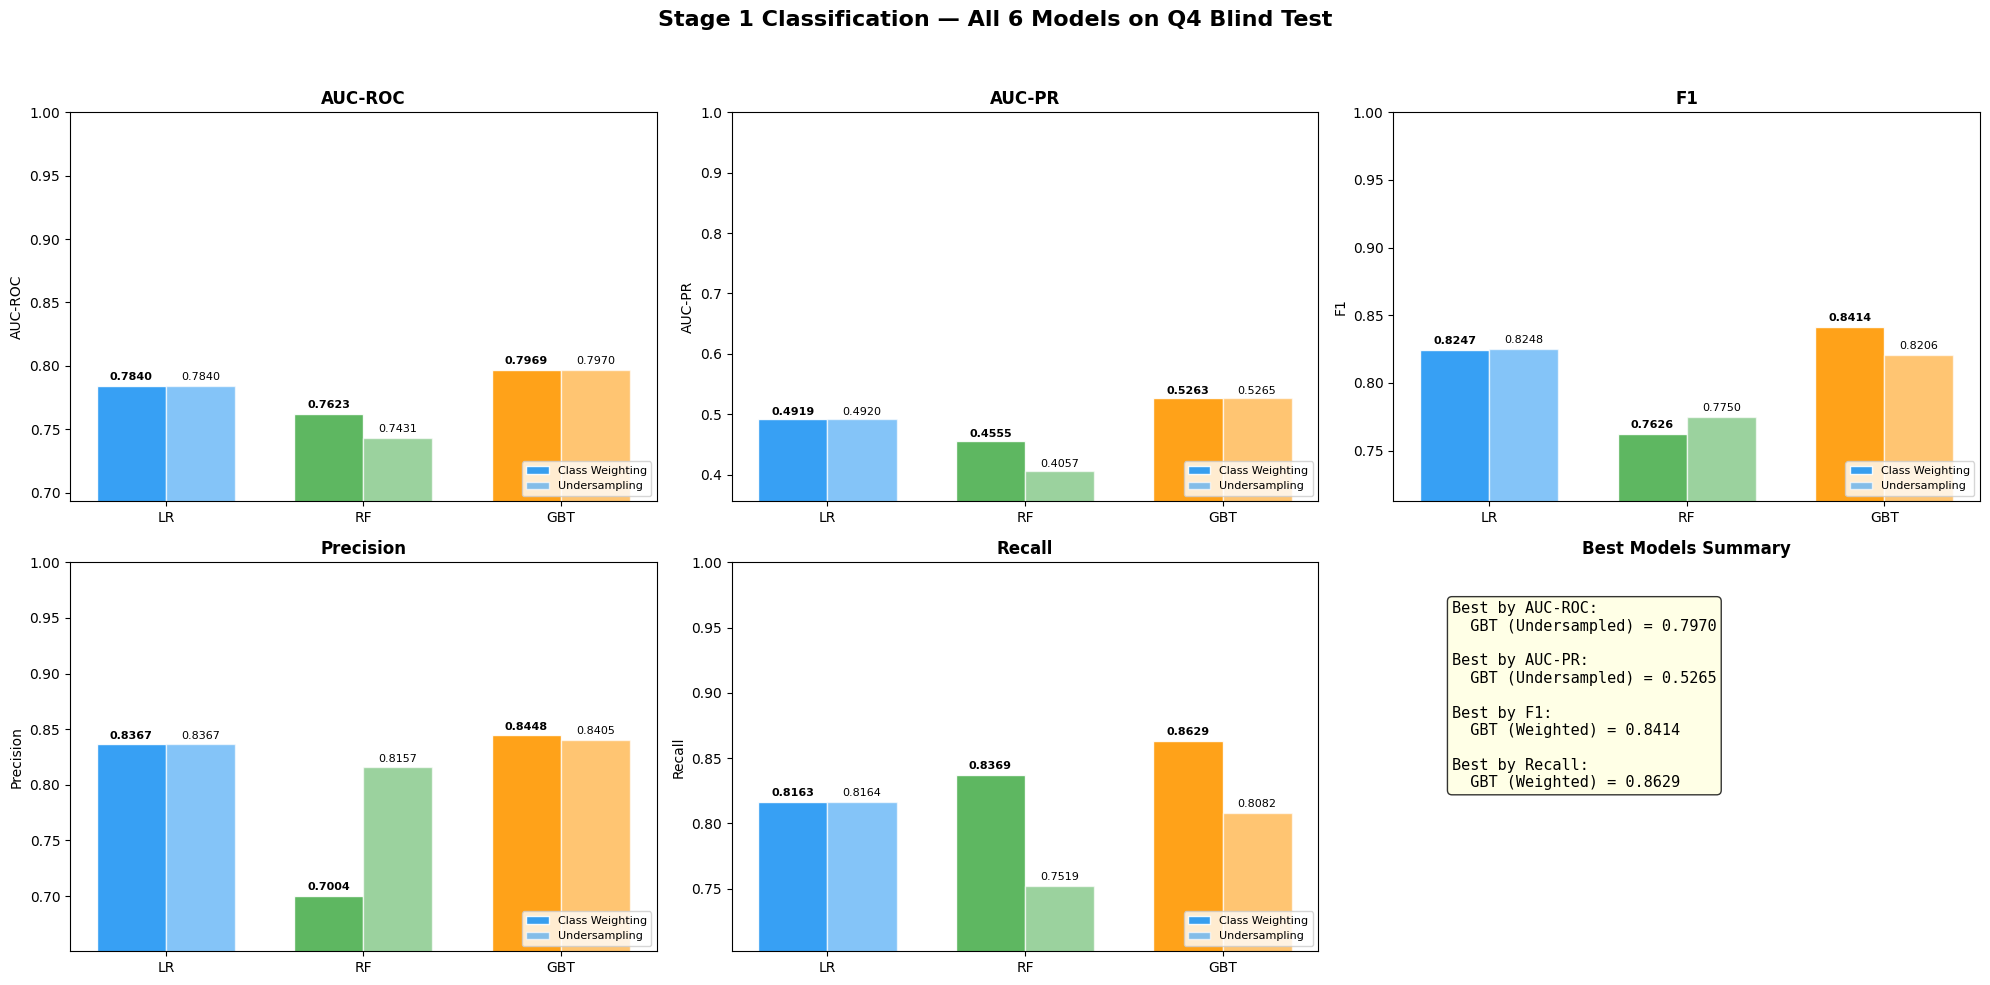

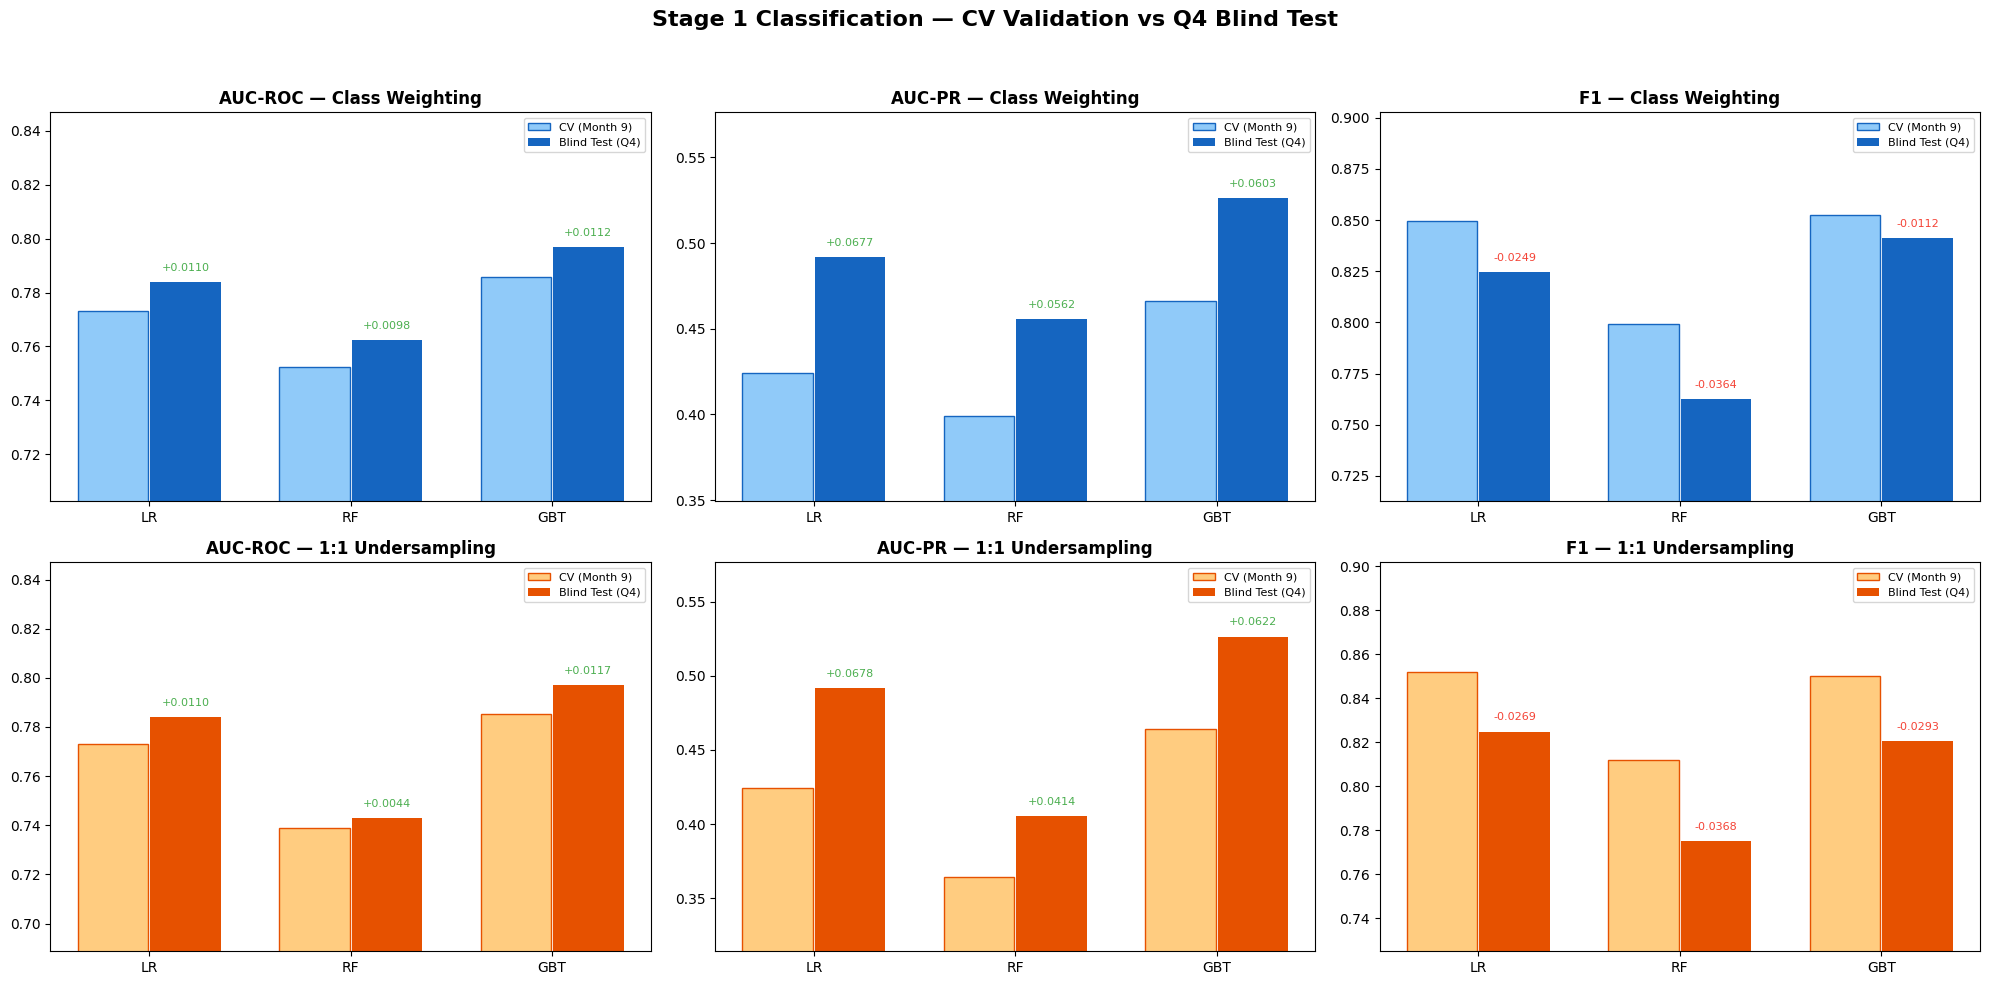

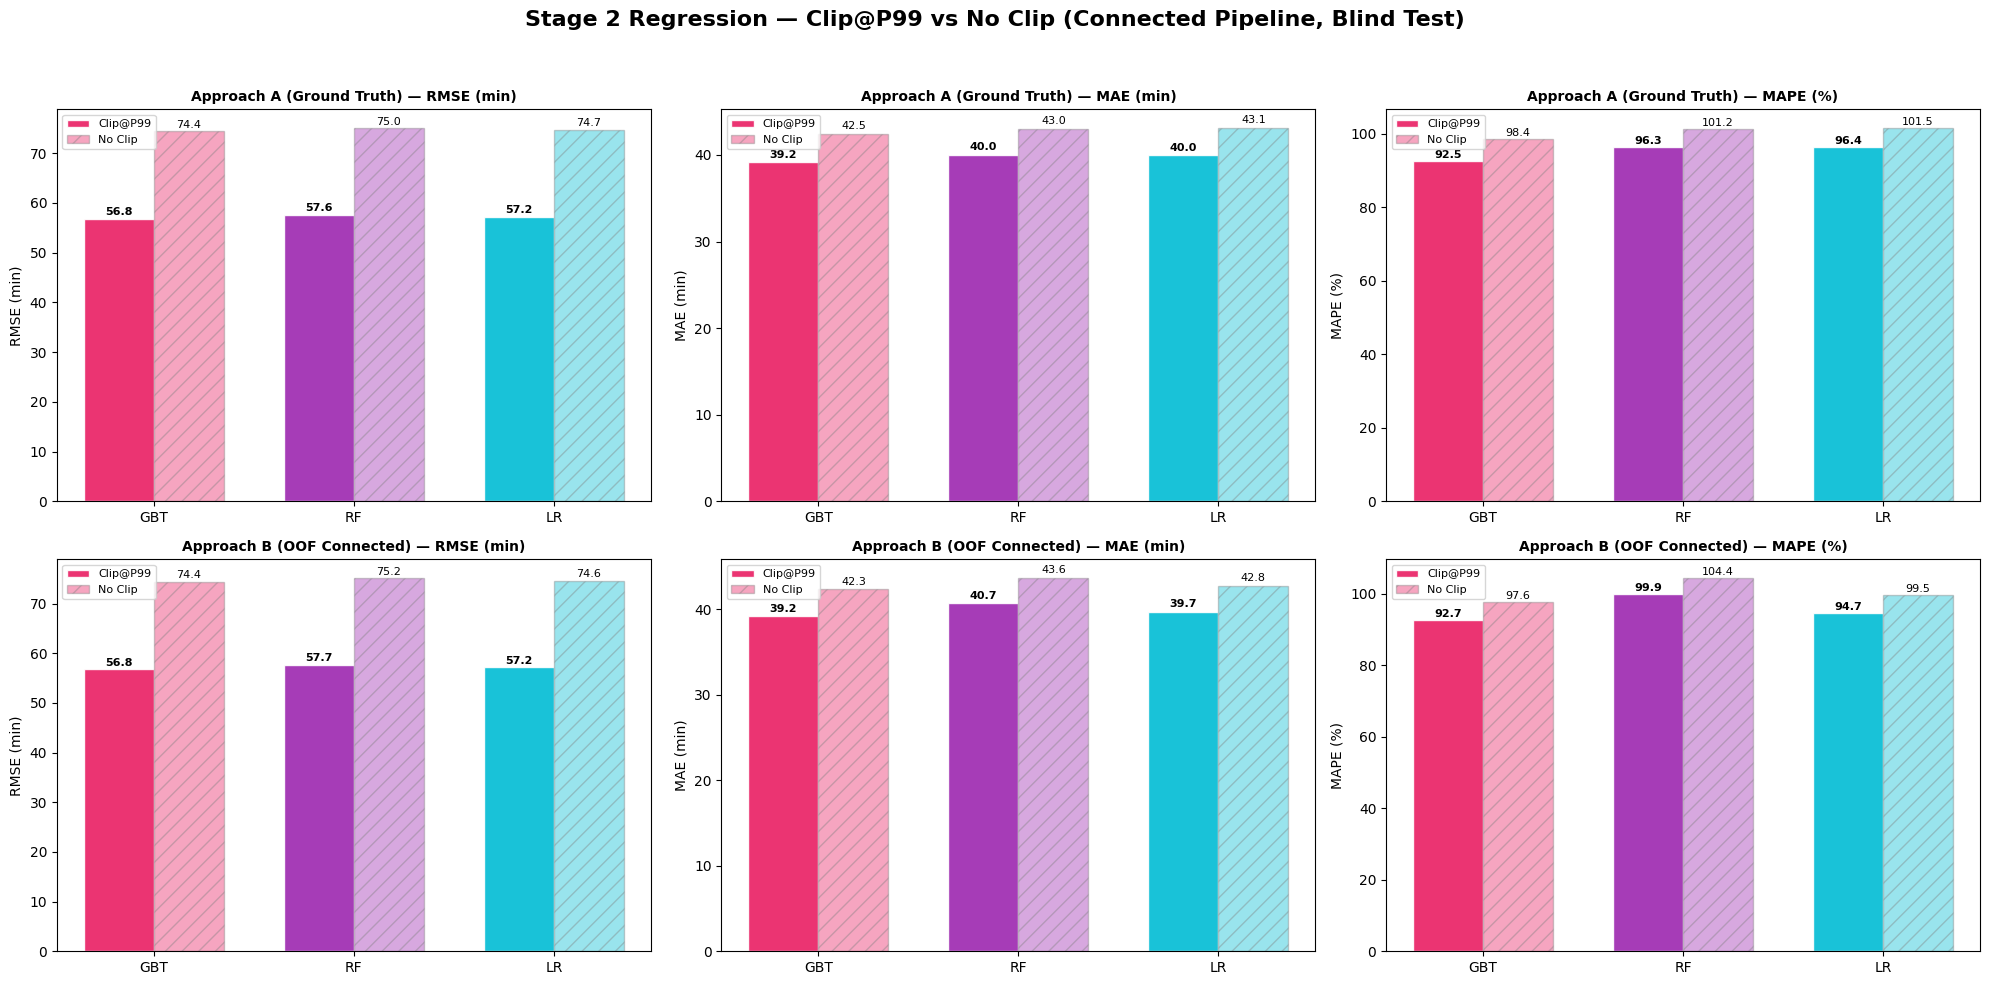

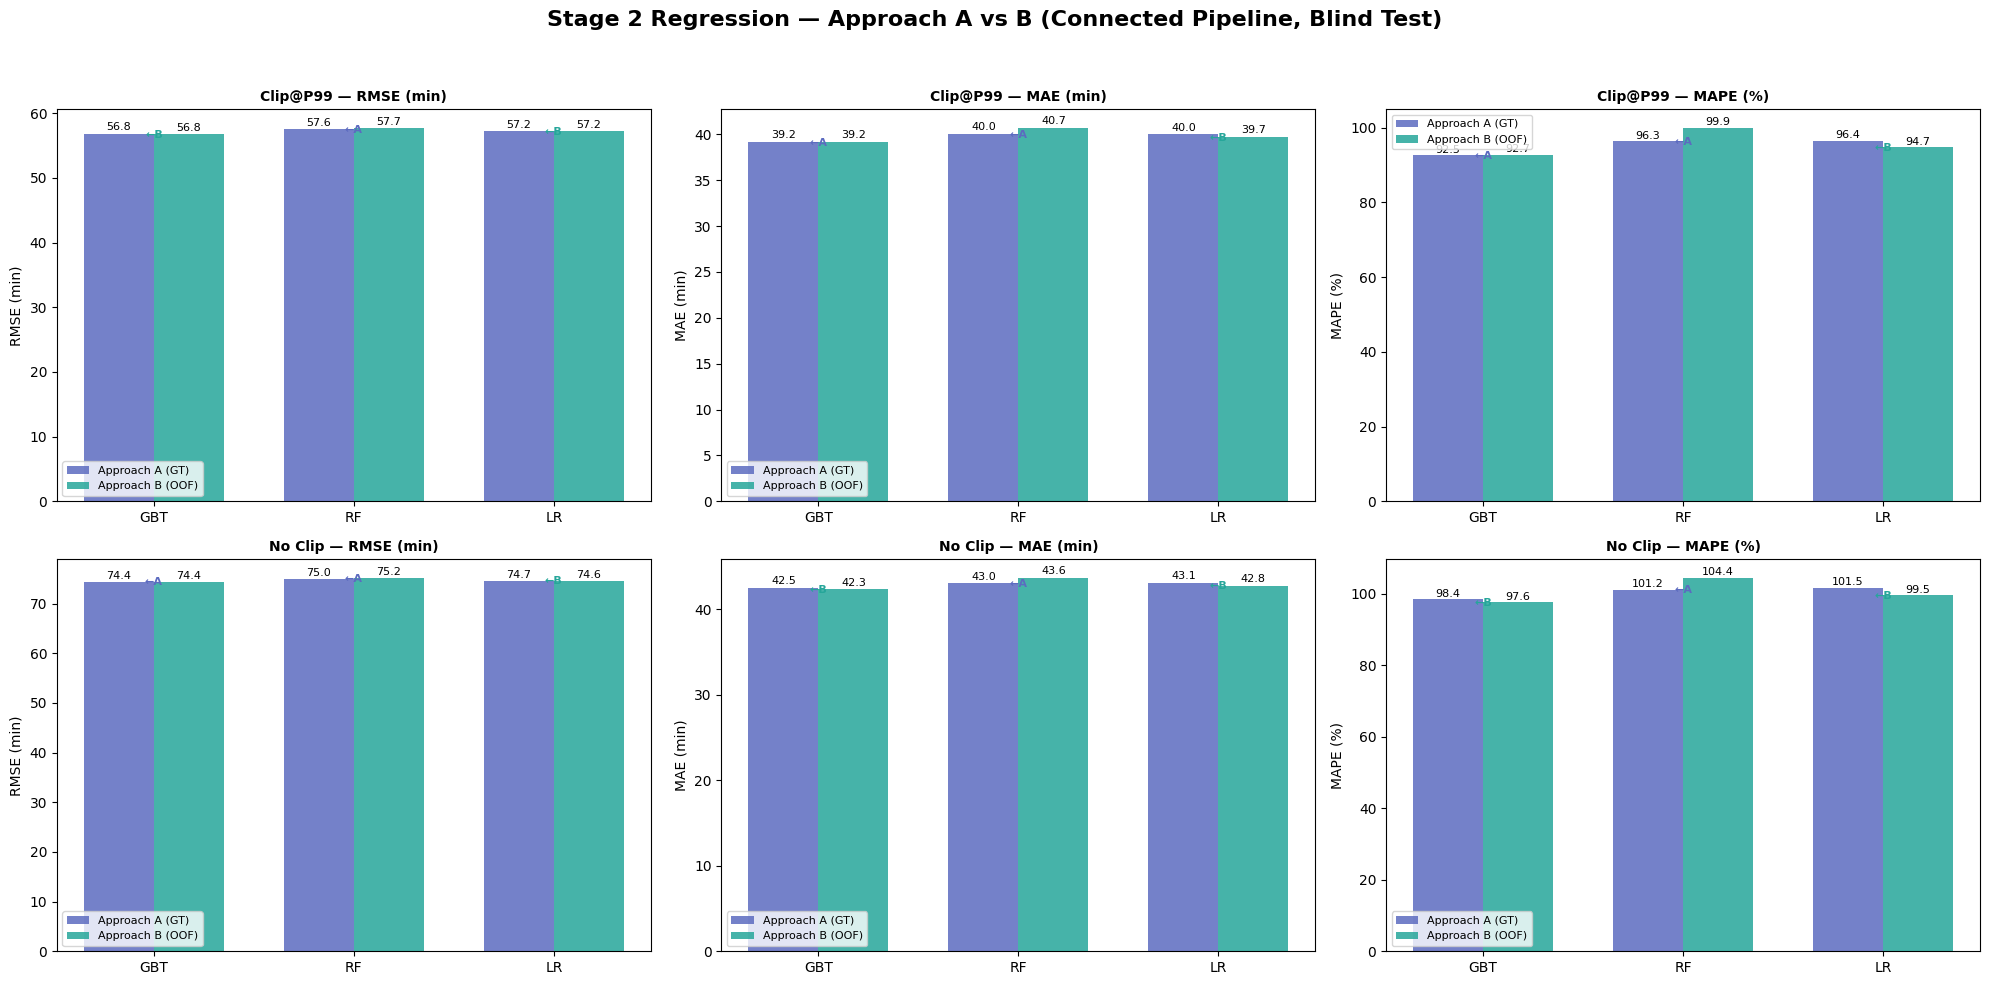

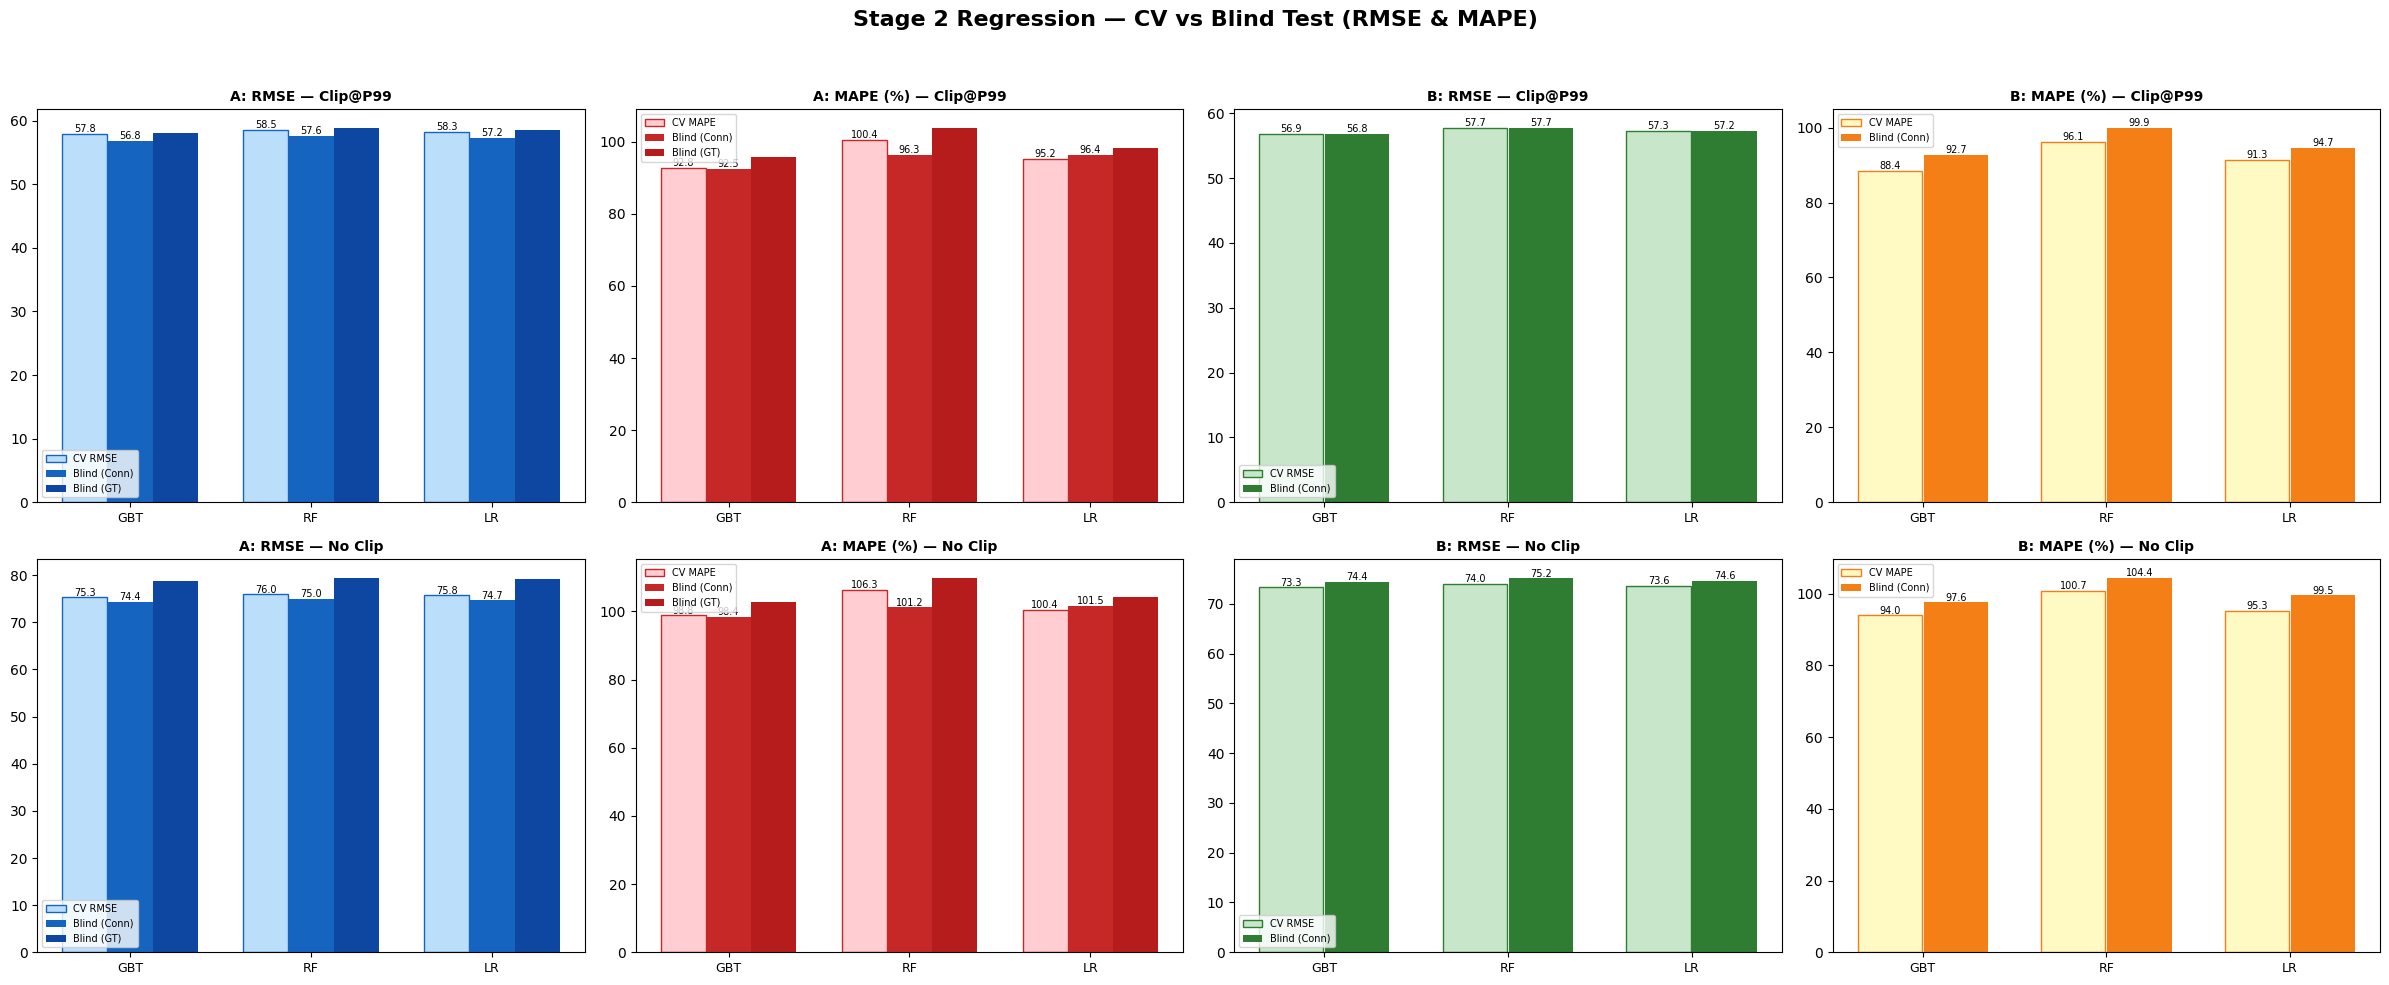

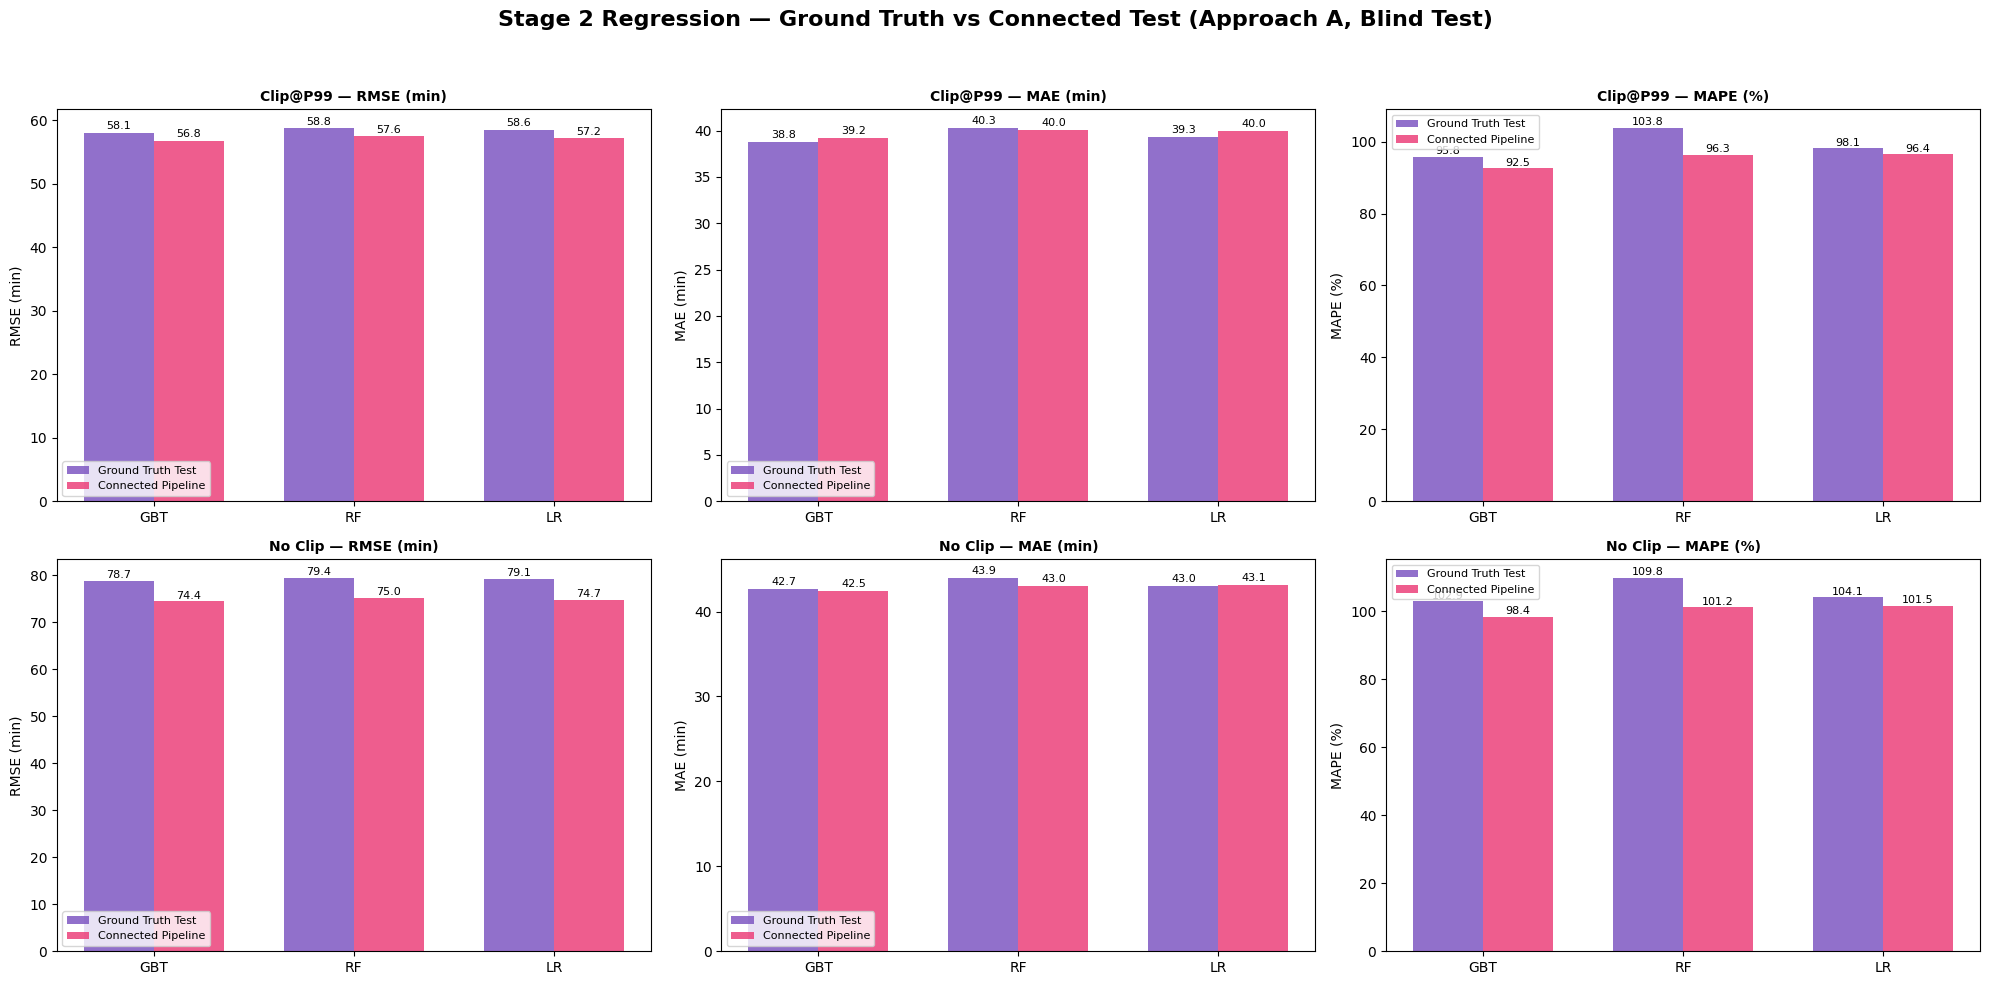

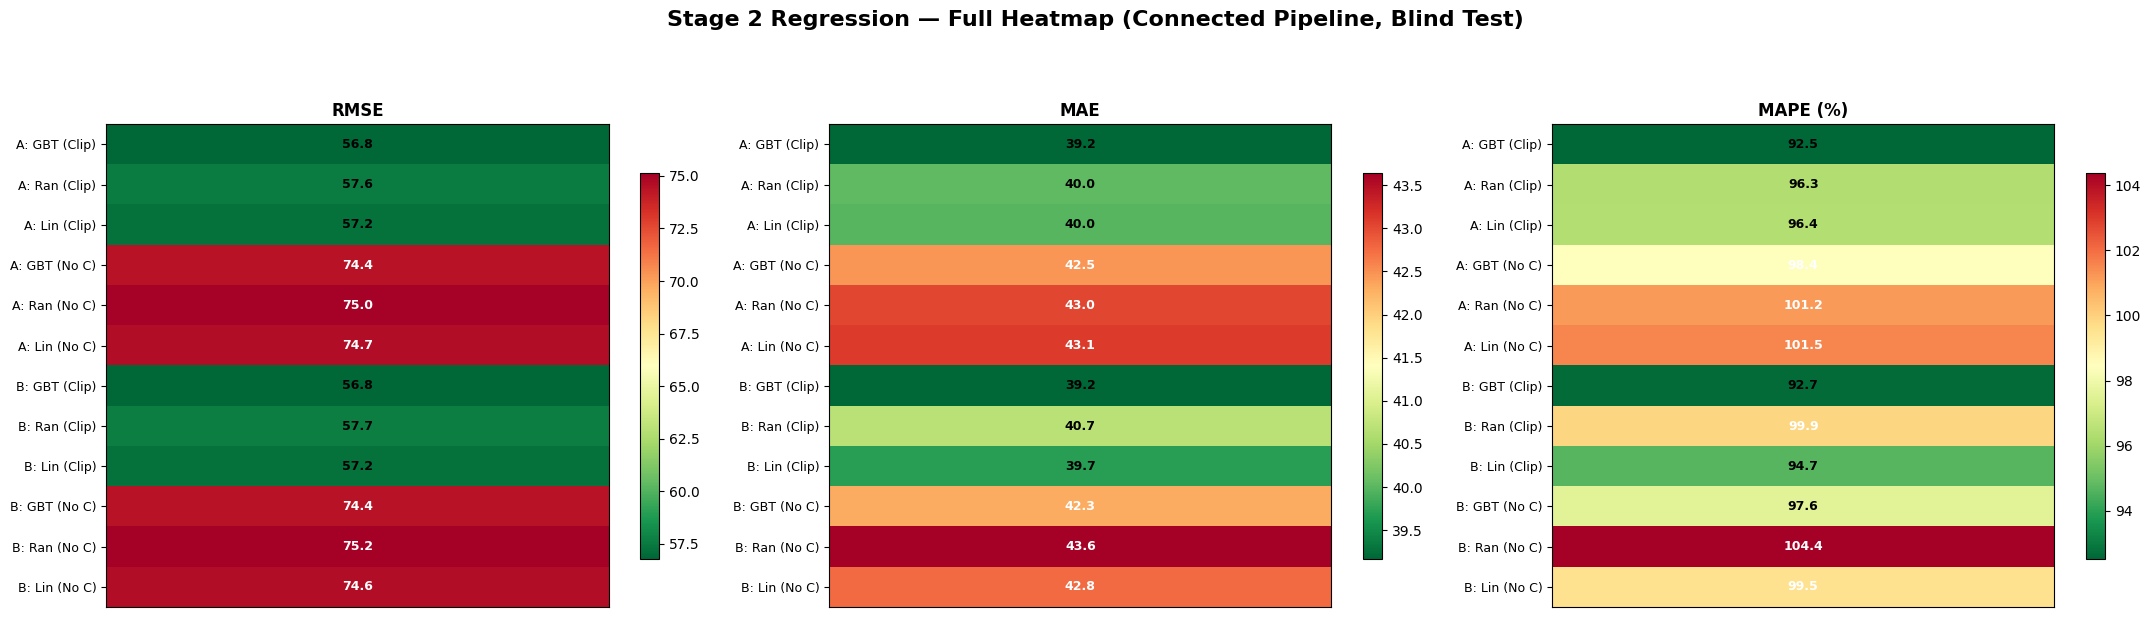

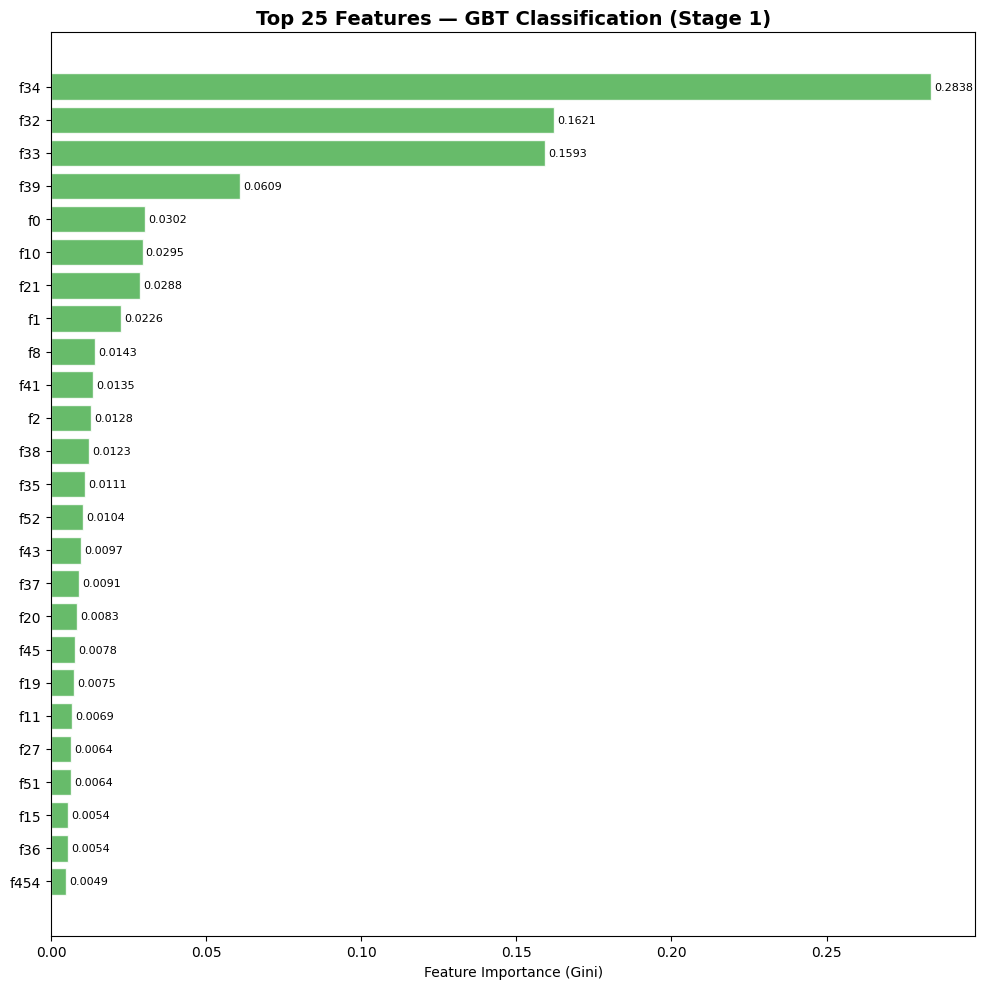

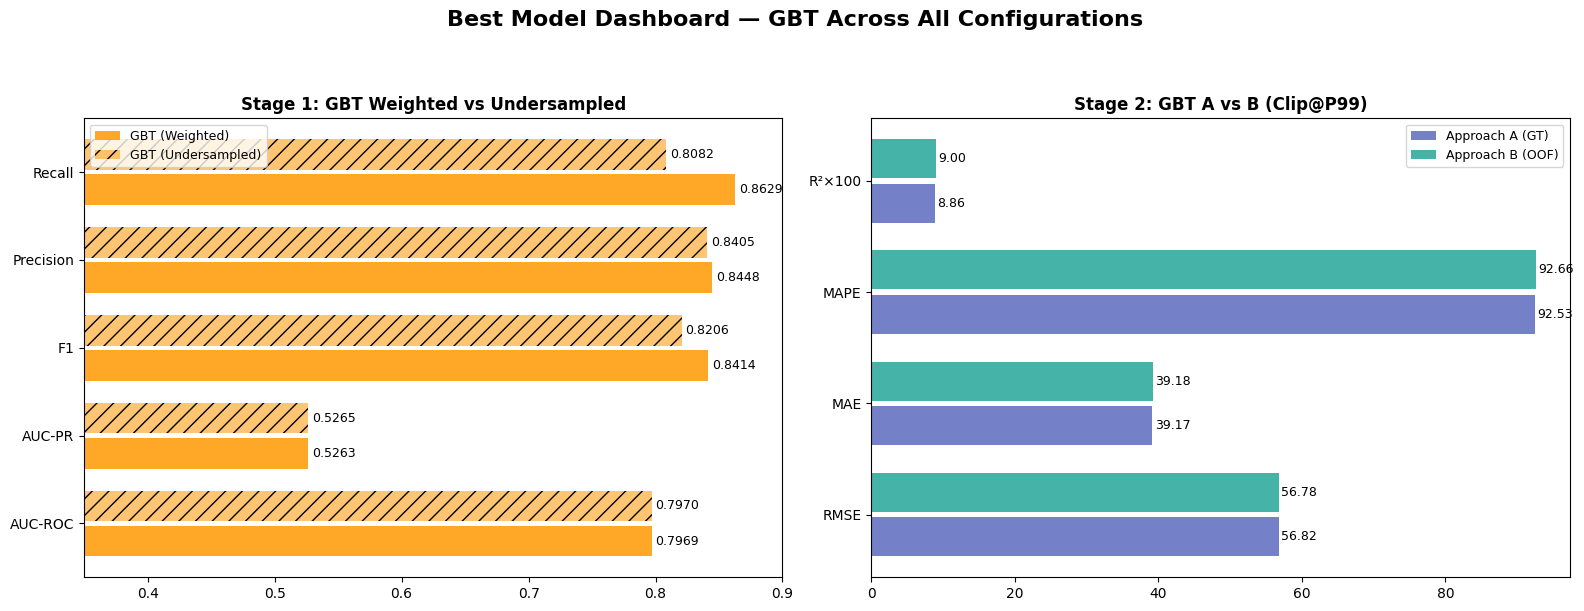


All 9 figures generated successfully.


In [0]:
# ============================================================
# Step 14: VISUALIZATIONS (Comprehensive)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10})
COLORS = {'LR': '#2196F3', 'RF': '#4CAF50', 'GBT': '#FF9800',
          'LR_us': '#42A5F5', 'RF_us': '#66BB6A', 'GBT_us': '#FFA726'}

# ═══════════════════════════════════════════════════════════════
# FIGURE 1: STAGE 1 — ALL 6 MODELS BLIND TEST COMPARISON
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Stage 1 Classification — All 6 Models on Q4 Blind Test', fontsize=16, fontweight='bold', y=0.98)

metrics_cls = ['AUC-ROC', 'AUC-PR', 'F1', 'Precision', 'Recall']
colors_w = ['#2196F3', '#4CAF50', '#FF9800']
colors_u = ['#42A5F5', '#66BB6A', '#FFA726']

for idx, metric in enumerate(metrics_cls):
    row, col_idx = divmod(idx, 3)
    ax = axes[row, col_idx]
    x = np.arange(3)
    w = 0.35
    vals_w = cls_blind_df[metric].values
    vals_u = us_blind_df[metric].values
    bars_w = ax.bar(x - w/2, vals_w, w, label='Class Weighting', color=colors_w, alpha=0.9, edgecolor='white')
    bars_u = ax.bar(x + w/2, vals_u, w, label='Undersampling', color=colors_u, alpha=0.65, edgecolor='white')
    for bar in bars_w:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    for bar in bars_u:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'RF', 'GBT'], fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ymin = min(min(vals_w), min(vals_u))
    ax.set_ylim(ymin - 0.05, 1.0)

# Use last subplot for strategy summary
ax = axes[1, 2]
ax.axis('off')
summary_text = (
    'Best by AUC-ROC:\n'
    f'  GBT (Undersampled) = {us_blind_df["AUC-ROC"].values[2]:.4f}\n\n'
    'Best by AUC-PR:\n'
    f'  GBT (Undersampled) = {us_blind_df["AUC-PR"].values[2]:.4f}\n\n'
    'Best by F1:\n'
    f'  GBT (Weighted) = {cls_blind_df["F1"].values[2]:.4f}\n\n'
    'Best by Recall:\n'
    f'  GBT (Weighted) = {cls_blind_df["Recall"].values[2]:.4f}'
)
ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('Best Models Summary', fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

# ═══════════════════════════════════════════════════════════════
# FIGURE 2: STAGE 1 — CV vs BLIND TEST (Weighted + Undersampled)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Stage 1 Classification — CV Validation vs Q4 Blind Test', fontsize=16, fontweight='bold', y=0.98)

for idx, metric in enumerate(['AUC-ROC', 'AUC-PR', 'F1']):
    # Top row: Class Weighting
    ax = axes[0, idx]
    x = np.arange(3)
    cv_vals = cls_cv_summary[metric].values
    blind_vals = cls_blind_df[metric].values
    ax.bar(x - 0.18, cv_vals, 0.35, label='CV (Month 9)', color='#90CAF9', edgecolor='#1565C0')
    ax.bar(x + 0.18, blind_vals, 0.35, label='Blind Test (Q4)', color='#1565C0')
    for j in range(3):
        delta = blind_vals[j] - cv_vals[j]
        color = '#4CAF50' if delta >= 0 else '#F44336'
        ax.annotate(f'{delta:+.4f}', xy=(x[j]+0.18, blind_vals[j]),
                    xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8, color=color)
    ax.set_title(f'{metric} — Class Weighting', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'RF', 'GBT'], fontsize=10)
    ax.legend(fontsize=8)
    ymin = min(min(cv_vals), min(blind_vals))
    ax.set_ylim(ymin - 0.05, max(max(cv_vals), max(blind_vals)) + 0.05)

    # Bottom row: Undersampling
    ax = axes[1, idx]
    cv_vals_u = us_cv_summary[metric].values
    blind_vals_u = us_blind_df[metric].values
    ax.bar(x - 0.18, cv_vals_u, 0.35, label='CV (Month 9)', color='#FFCC80', edgecolor='#E65100')
    ax.bar(x + 0.18, blind_vals_u, 0.35, label='Blind Test (Q4)', color='#E65100')
    for j in range(3):
        delta = blind_vals_u[j] - cv_vals_u[j]
        color = '#4CAF50' if delta >= 0 else '#F44336'
        ax.annotate(f'{delta:+.4f}', xy=(x[j]+0.18, blind_vals_u[j]),
                    xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8, color=color)
    ax.set_title(f'{metric} — 1:1 Undersampling', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'RF', 'GBT'], fontsize=10)
    ax.legend(fontsize=8)
    ymin = min(min(cv_vals_u), min(blind_vals_u))
    ax.set_ylim(ymin - 0.05, max(max(cv_vals_u), max(blind_vals_u)) + 0.05)

fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

# ═══════════════════════════════════════════════════════════════
# FIGURE 3: STAGE 2 — P99 vs NO CLIP COMPARISON
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Stage 2 Regression — Clip@P99 vs No Clip (Connected Pipeline, Blind Test)', fontsize=16, fontweight='bold', y=0.98)

reg_metrics = ['RMSE (Avg Error)', 'MAE (Typical Error)', 'MAPE (%)']
reg_labels = ['RMSE (min)', 'MAE (min)', 'MAPE (%)']
models_reg = ['GBT', 'Random Forest', 'Linear Regression']
colors_reg = ['#E91E63', '#9C27B0', '#00BCD4']

for row_idx, (approach_name, df_conn) in enumerate([('Approach A (Ground Truth)', df_a_conn), ('Approach B (OOF Connected)', df_b_conn)]):
    for col_idx, (metric, label) in enumerate(zip(reg_metrics, reg_labels)):
        ax = axes[row_idx, col_idx]
        p99_vals = df_conn[df_conn['Variant'] == 'Clip@P99'].set_index('Model').reindex(models_reg)[metric].values
        raw_vals = df_conn[df_conn['Variant'] == 'No Clip'].set_index('Model').reindex(models_reg)[metric].values
        x = np.arange(3)
        w = 0.35
        bars_p99 = ax.bar(x - w/2, p99_vals, w, label='Clip@P99', color=colors_reg, alpha=0.9, edgecolor='white')
        bars_raw = ax.bar(x + w/2, raw_vals, w, label='No Clip', color=colors_reg, alpha=0.4, edgecolor='gray', hatch='//')
        for bar in bars_p99:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        for bar in bars_raw:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{approach_name} — {label}', fontweight='bold', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(['GBT', 'RF', 'LR'], fontsize=10)
        ax.legend(fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

# ═══════════════════════════════════════════════════════════════
# FIGURE 4: STAGE 2 — APPROACH A vs APPROACH B (Connected Pipeline)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Stage 2 Regression — Approach A vs B (Connected Pipeline, Blind Test)', fontsize=16, fontweight='bold', y=0.98)

for row_idx, variant in enumerate(['Clip@P99', 'No Clip']):
    a_vals = df_a_conn[df_a_conn['Variant'] == variant].set_index('Model').reindex(models_reg)
    b_vals = df_b_conn[df_b_conn['Variant'] == variant].set_index('Model').reindex(models_reg)
    for col_idx, (metric, label) in enumerate(zip(reg_metrics, reg_labels)):
        ax = axes[row_idx, col_idx]
        x = np.arange(3)
        w = 0.35
        vals_a = a_vals[metric].values
        vals_b = b_vals[metric].values
        ax.bar(x - w/2, vals_a, w, label='Approach A (GT)', color='#5C6BC0', alpha=0.85)
        ax.bar(x + w/2, vals_b, w, label='Approach B (OOF)', color='#26A69A', alpha=0.85)
        for j in range(3):
            ax.text(x[j] - w/2, vals_a[j] + 0.2, f'{vals_a[j]:.1f}', ha='center', va='bottom', fontsize=8)
            ax.text(x[j] + w/2, vals_b[j] + 0.2, f'{vals_b[j]:.1f}', ha='center', va='bottom', fontsize=8)
        # Highlight winner
        for j in range(3):
            if metric == 'R\u00b2':
                winner = 'B' if vals_b[j] > vals_a[j] else 'A'
            else:
                winner = 'B' if vals_b[j] < vals_a[j] else 'A'
            color = '#26A69A' if winner == 'B' else '#5C6BC0'
            ax.annotate(f'\u2190{winner}', xy=(x[j], min(vals_a[j], vals_b[j]) * 0.99),
                        fontsize=8, ha='center', color=color, fontweight='bold')
        ax.set_ylabel(label)
        ax.set_title(f'{variant} — {label}', fontweight='bold', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(['GBT', 'RF', 'LR'], fontsize=10)
        ax.legend(fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

# ═══════════════════════════════════════════════════════════════
# FIGURE 5: STAGE 2 — CV RMSE & CV MAPE vs BLIND TEST
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('Stage 2 Regression — CV vs Blind Test (RMSE & MAPE)', fontsize=16, fontweight='bold', y=0.98)

for row_idx, variant in enumerate(['Clip@P99', 'No Clip']):
    # Approach A: CV RMSE vs Blind RMSE
    cv_a = reg_cv_summary_a[reg_cv_summary_a['Variant'] == variant].set_index('Model').reindex(models_reg)
    blind_a_conn = df_a_conn[df_a_conn['Variant'] == variant].set_index('Model').reindex(models_reg)
    blind_a_gt = df_a_gt[df_a_gt['Variant'] == variant].set_index('Model').reindex(models_reg)

    # Col 0: Approach A RMSE
    ax = axes[row_idx, 0]
    x = np.arange(3)
    ax.bar(x - 0.25, cv_a['CV RMSE'].values, 0.25, label='CV RMSE', color='#BBDEFB', edgecolor='#1565C0')
    ax.bar(x, blind_a_conn['RMSE (Avg Error)'].values, 0.25, label='Blind (Conn)', color='#1565C0')
    ax.bar(x + 0.25, blind_a_gt['RMSE (Avg Error)'].values, 0.25, label='Blind (GT)', color='#0D47A1')
    for j in range(3):
        ax.text(x[j] - 0.25, cv_a['CV RMSE'].values[j] + 0.3, f"{cv_a['CV RMSE'].values[j]:.1f}", ha='center', fontsize=7)
        ax.text(x[j], blind_a_conn['RMSE (Avg Error)'].values[j] + 0.3, f"{blind_a_conn['RMSE (Avg Error)'].values[j]:.1f}", ha='center', fontsize=7)
    ax.set_title(f'A: RMSE — {variant}', fontweight='bold', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(['GBT', 'RF', 'LR'], fontsize=9)
    ax.legend(fontsize=7)

    # Col 1: Approach A MAPE
    ax = axes[row_idx, 1]
    ax.bar(x - 0.25, cv_a['CV MAPE (%)'].values, 0.25, label='CV MAPE', color='#FFCDD2', edgecolor='#C62828')
    ax.bar(x, blind_a_conn['MAPE (%)'].values, 0.25, label='Blind (Conn)', color='#C62828')
    ax.bar(x + 0.25, blind_a_gt['MAPE (%)'].values, 0.25, label='Blind (GT)', color='#B71C1C')
    for j in range(3):
        ax.text(x[j] - 0.25, cv_a['CV MAPE (%)'].values[j] + 0.5, f"{cv_a['CV MAPE (%)'].values[j]:.1f}", ha='center', fontsize=7)
        ax.text(x[j], blind_a_conn['MAPE (%)'].values[j] + 0.5, f"{blind_a_conn['MAPE (%)'].values[j]:.1f}", ha='center', fontsize=7)
    ax.set_title(f'A: MAPE (%) — {variant}', fontweight='bold', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(['GBT', 'RF', 'LR'], fontsize=9)
    ax.legend(fontsize=7)

    # Approach B: CV RMSE vs Blind RMSE
    cv_b = reg_cv_summary_b[reg_cv_summary_b['Variant'] == variant].set_index('Model').reindex(models_reg)
    blind_b_conn = df_b_conn[df_b_conn['Variant'] == variant].set_index('Model').reindex(models_reg)

    # Col 2: Approach B RMSE
    ax = axes[row_idx, 2]
    ax.bar(x - 0.18, cv_b['CV RMSE'].values, 0.35, label='CV RMSE', color='#C8E6C9', edgecolor='#2E7D32')
    ax.bar(x + 0.18, blind_b_conn['RMSE (Avg Error)'].values, 0.35, label='Blind (Conn)', color='#2E7D32')
    for j in range(3):
        ax.text(x[j] - 0.18, cv_b['CV RMSE'].values[j] + 0.3, f"{cv_b['CV RMSE'].values[j]:.1f}", ha='center', fontsize=7)
        ax.text(x[j] + 0.18, blind_b_conn['RMSE (Avg Error)'].values[j] + 0.3, f"{blind_b_conn['RMSE (Avg Error)'].values[j]:.1f}", ha='center', fontsize=7)
    ax.set_title(f'B: RMSE — {variant}', fontweight='bold', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(['GBT', 'RF', 'LR'], fontsize=9)
    ax.legend(fontsize=7)

    # Col 3: Approach B MAPE
    ax = axes[row_idx, 3]
    ax.bar(x - 0.18, cv_b['CV MAPE (%)'].values, 0.35, label='CV MAPE', color='#FFF9C4', edgecolor='#F57F17')
    ax.bar(x + 0.18, blind_b_conn['MAPE (%)'].values, 0.35, label='Blind (Conn)', color='#F57F17')
    for j in range(3):
        ax.text(x[j] - 0.18, cv_b['CV MAPE (%)'].values[j] + 0.5, f"{cv_b['CV MAPE (%)'].values[j]:.1f}", ha='center', fontsize=7)
        ax.text(x[j] + 0.18, blind_b_conn['MAPE (%)'].values[j] + 0.5, f"{blind_b_conn['MAPE (%)'].values[j]:.1f}", ha='center', fontsize=7)
    ax.set_title(f'B: MAPE (%) — {variant}', fontweight='bold', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(['GBT', 'RF', 'LR'], fontsize=9)
    ax.legend(fontsize=7)

fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

# ═══════════════════════════════════════════════════════════════
# FIGURE 6: STAGE 2 — GROUND TRUTH vs CONNECTED TEST (Approach A)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Stage 2 Regression — Ground Truth vs Connected Test (Approach A, Blind Test)', fontsize=16, fontweight='bold', y=0.98)

reg_metrics_full = ['RMSE (Avg Error)', 'MAE (Typical Error)', 'MAPE (%)']
reg_labels_full = ['RMSE (min)', 'MAE (min)', 'MAPE (%)']

for row_idx, variant in enumerate(['Clip@P99', 'No Clip']):
    gt_v = df_a_gt[df_a_gt['Variant'] == variant].set_index('Model').reindex(models_reg)
    conn_v = df_a_conn[df_a_conn['Variant'] == variant].set_index('Model').reindex(models_reg)
    for col_idx, (metric, label) in enumerate(zip(reg_metrics_full, reg_labels_full)):
        ax = axes[row_idx, col_idx]
        x = np.arange(3)
        w = 0.35
        vals_gt = gt_v[metric].values
        vals_conn = conn_v[metric].values
        ax.bar(x - w/2, vals_gt, w, label='Ground Truth Test', color='#7E57C2', alpha=0.85)
        ax.bar(x + w/2, vals_conn, w, label='Connected Pipeline', color='#EC407A', alpha=0.85)
        for j in range(3):
            ax.text(x[j] - w/2, vals_gt[j] + 0.2, f'{vals_gt[j]:.1f}', ha='center', va='bottom', fontsize=8)
            ax.text(x[j] + w/2, vals_conn[j] + 0.2, f'{vals_conn[j]:.1f}', ha='center', va='bottom', fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{variant} — {label}', fontweight='bold', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(['GBT', 'RF', 'LR'], fontsize=10)
        ax.legend(fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

# ═══════════════════════════════════════════════════════════════
# FIGURE 7: HEATMAP — ALL REGRESSION RESULTS (Connected Pipeline)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Stage 2 Regression — Full Heatmap (Connected Pipeline, Blind Test)', fontsize=16, fontweight='bold', y=1.02)

# Build combined dataframe for heatmap
heatmap_rows = []
for approach, df_conn in [('A', df_a_conn), ('B', df_b_conn)]:
    for _, row in df_conn.iterrows():
        heatmap_rows.append({
            'Config': f"{approach}: {row['Model'][:3]} ({row['Variant'][:4]})",
            'RMSE': row['RMSE (Avg Error)'],
            'MAE': row['MAE (Typical Error)'],
            'MAPE (%)': row['MAPE (%)']
        })
heatmap_df = pd.DataFrame(heatmap_rows).set_index('Config')

for idx, metric in enumerate(['RMSE', 'MAE', 'MAPE (%)']):
    ax = axes[idx]
    vals = heatmap_df[metric].values.reshape(-1, 1)
    im = ax.imshow(vals, cmap='RdYlGn_r', aspect='auto')
    ax.set_yticks(range(len(heatmap_df)))
    ax.set_yticklabels(heatmap_df.index, fontsize=9)
    ax.set_xticks([])
    ax.set_title(metric, fontweight='bold', fontsize=12)
    for i, v in enumerate(vals.flatten()):
        fmt = '.1f' if metric != 'MAPE (%)' else '.1f'
        ax.text(0, i, f'{v:{fmt}}', ha='center', va='center', fontsize=9,
                fontweight='bold', color='white' if v > np.median(vals) else 'black')
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

# ═══════════════════════════════════════════════════════════════
# FIGURE 8: GBT FEATURE IMPORTANCE (Classification)
# ═══════════════════════════════════════════════════════════════
try:
    gbt_model_for_fi = cls_models.get('gbt', us_cls_models.get('gbt_us', None))
    if gbt_model_for_fi is not None:
        fi = gbt_model_for_fi.featureImportances.toArray()
        assembler_stage = [s for s in pipeline_model.stages if isinstance(s, VectorAssembler)][0]
        feat_names = assembler_stage.getInputCols()
        fi_df = pd.DataFrame({
            'feature': feat_names[:len(fi)] if len(feat_names) >= len(fi) else [f'f{i}' for i in range(len(fi))],
            'importance': fi
        })
        fi_df = fi_df.sort_values('importance', ascending=True).tail(25)

        fig, ax = plt.subplots(figsize=(10, 10))
        bars = ax.barh(fi_df['feature'], fi_df['importance'], color='#4CAF50', alpha=0.85, edgecolor='white')
        ax.set_xlabel('Feature Importance (Gini)')
        ax.set_title('Top 25 Features — GBT Classification (Stage 1)', fontweight='bold', fontsize=14)
        for bar in bars:
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{bar.get_width():.4f}', va='center', fontsize=8)
        fig.tight_layout()
        display(fig)
        plt.close(fig)
except Exception as e:
    print(f"Feature importance chart skipped: {e}")

# ═══════════════════════════════════════════════════════════════
# FIGURE 9: RADAR CHART — BEST MODELS COMPARISON
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Best Model Dashboard — GBT Across All Configurations', fontsize=16, fontweight='bold', y=1.01)

# Left: Classification — GBT Weighted vs GBT Undersampled
ax = axes[0]
metrics_radar = ['AUC-ROC', 'AUC-PR', 'F1', 'Precision', 'Recall']
gbt_w = cls_blind_df[cls_blind_df['Model'] == 'GBT'][metrics_radar].values[0]
gbt_u = us_blind_df[us_blind_df['Model'] == 'GBT (Undersampled)'][metrics_radar].values[0]
x_pos = np.arange(len(metrics_radar))
ax.barh(x_pos - 0.2, gbt_w, 0.35, label='GBT (Weighted)', color='#FF9800', alpha=0.85)
ax.barh(x_pos + 0.2, gbt_u, 0.35, label='GBT (Undersampled)', color='#FFA726', alpha=0.65, hatch='//')
for j in range(len(metrics_radar)):
    ax.text(gbt_w[j] + 0.003, x_pos[j] - 0.2, f'{gbt_w[j]:.4f}', va='center', fontsize=9)
    ax.text(gbt_u[j] + 0.003, x_pos[j] + 0.2, f'{gbt_u[j]:.4f}', va='center', fontsize=9)
ax.set_yticks(x_pos)
ax.set_yticklabels(metrics_radar, fontsize=10)
ax.set_title('Stage 1: GBT Weighted vs Undersampled', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0.35, 0.90)

# Right: Regression — GBT A vs B (P99) key metrics
ax = axes[1]
reg_compare_metrics = ['RMSE', 'MAE', 'MAPE', 'R\u00b2\u00d7100']
gbt_a_p99 = df_a_conn[df_a_conn['Variant'] == 'Clip@P99'].set_index('Model').loc['GBT']
gbt_b_p99 = df_b_conn[df_b_conn['Variant'] == 'Clip@P99'].set_index('Model').loc['GBT']
vals_a = [gbt_a_p99['RMSE (Avg Error)'], gbt_a_p99['MAE (Typical Error)'], gbt_a_p99['MAPE (%)'], gbt_a_p99['R\u00b2']*100]
vals_b = [gbt_b_p99['RMSE (Avg Error)'], gbt_b_p99['MAE (Typical Error)'], gbt_b_p99['MAPE (%)'], gbt_b_p99['R\u00b2']*100]
x_pos = np.arange(4)
ax.barh(x_pos - 0.2, vals_a, 0.35, label='Approach A (GT)', color='#5C6BC0', alpha=0.85)
ax.barh(x_pos + 0.2, vals_b, 0.35, label='Approach B (OOF)', color='#26A69A', alpha=0.85)
for j in range(4):
    fmt = '.2f' if j < 3 else '.2f'
    ax.text(vals_a[j] + 0.3, x_pos[j] - 0.2, f'{vals_a[j]:{fmt}}', va='center', fontsize=9)
    ax.text(vals_b[j] + 0.3, x_pos[j] + 0.2, f'{vals_b[j]:{fmt}}', va='center', fontsize=9)
ax.set_yticks(x_pos)
ax.set_yticklabels(reg_compare_metrics, fontsize=10)
ax.set_title('Stage 2: GBT A vs B (Clip@P99)', fontweight='bold')
ax.legend(fontsize=9)

fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

print(f"\nAll {9} figures generated successfully.")

## Two-Stage Flight Delay Prediction Pipeline — Full Summary (60M)

### Goal
Predict flight departure delays **2 hours before departure** using a connected two-stage approach on the 60-month OTPW dataset.

---

### Pipeline Architecture

| Stage | Task | Target | Models | Primary Metric |
| --- | --- | --- | --- | --- |
| **Stage 1** | Binary Classification | `DEP_DEL15` (delayed >= 15 min?) | LR, RF, GBT | **AUC-ROC** |
| **Stage 2** | Regression (delayed flights only) | `DEP_DELAY` (minutes) | Linear Reg, RF, GBT | **MAE** |

**Connected Flow:** Stage 1 classifies all flights → flights predicted as delayed AND actually delayed (`DEP_DEL15 = 1`) are fed into Stage 2 → Stage 2 predicts delay duration in minutes.

---

### Steps 0–1: Setup & Configuration
* Data path: `dbfs:/mnt/mids-w261/OTPW_60M_Backup/` (parquet)
* Checkpoints saved to `dbfs:/mnt/mids-w261/student-groups/Group_01_01/nithya_60m_pipeline/`
* Targets: `DEP_DEL15` (Stage 1), `DEP_DELAY` (Stage 2)

### Step 2: Data Loading
* **31,197,330 rows** loaded from the 60M OTPW parquet
* **216 columns** in raw data

### Step 3: Column Selection & Leakage Removal
* Reduced from 216 → **34 columns** (only features available >= 2 hours before departure)
* `DEP_DELAY` kept as regression target (never used as a feature)
* Rows with null targets removed
* **Temporal train/test split:**

| Split | Period | Rows |
| --- | --- | --- |
| Train + Validation | Q1–Q3 (Jan–Sep) | **23,431,665** |
| Blind Test | Q4 (Oct–Dec) | **7,765,665** |

### Step 4: Data Cleaning & Imputation
* 12 weather string columns cast to numeric (strip quality flags via regex)
* Weather nulls imputed: airport+month mean → overall mean fallback
* 12 flight numeric columns: overall mean imputation

### Step 5: Feature Engineering

Raw columns expanded from 34 → **\~70 columns** after engineering.

| Category | Count | Features | Purpose |
| --- | --- | --- | --- |
| **Time** | 8 | dep_hour, cyclical hour/month (sin/cos), is_weekend, is_peak_hour, days_to_holiday | Temporal patterns |
| **Weather Composites** | 5 | dew_point_depression, has_precipitation, low_visibility, high_wind, weather_severity | Combined severity index |
| **Congestion** | 4 | origin/dest/tail rolling delay rate, hourly flight count | Cascade effects |
| **RFM** | 12 | 7d/14d/30d avg_delay, flight_freq, pct_delayed (origin + carrier) | Multi-horizon trends |
| **Target Encoding** | 4 | origin/dest/carrier/route avg delay rate | Historical delay propensity |

### Step 6: Feature Assembly (Checkpoint 1)
* **52 numeric features** (including 12 RFM) + 4 categorical columns OHE’d: `OP_UNIQUE_CARRIER`, `ORIGIN`, `DEST`, `DEP_TIME_BLK`
* `VectorAssembler` combines numeric + OHE features → **823-dimensional feature vector**
* `StandardScaler(withMean=False, withStd=True)` keeps vectors **sparse** (\~54 non-zero per 823-dim → 93% sparse, 15× less memory vs dense)

---

### Stage 1: Classification (Steps 7–9)

#### Temporal Validation Split

Models train on folds 0–3 (months 1–8, 20,899,836 rows) and validate on fold 4 (month 9, 2,531,829 rows). Best config retrained on all folds (months 1–9) before blind test.

| Fold | Months | Rows |
| --- | --- | --- |
| 0 | Jan–Feb | 4,709,322 |
| 1 | Mar–Apr | 5,243,343 |
| 2 | May–Jun | 5,383,764 |
| 3 | Jul–Aug | 5,563,407 |
| 4 (val) | Sep | 2,531,829 |

#### Two Class-Balancing Strategies

| Strategy | How | Applied to | Train Size |
| --- | --- | --- | --- |
| **A: Class Weighting** | 4.3× `weightCol` for delayed | All 3 models | 23,431,665 |
| **B: 1:1 Undersampling** | Downsample majority to match minority | All 3 models | \~8,118,612 |

#### Models & Grids
| Model | Grid | Key Params |
| --- | --- | --- |
| Logistic Regression | regParam=[0.01, 0.1] × elasticNetParam=[0.0, 0.5] = 4 configs | weightCol (Strategy A only) |
| Random Forest | numTrees=[50, 100], maxDepth=5 = 2 configs | maxMemoryInMB=512 |
| GBT | maxIter=[20, 50], maxDepth=5 = 2 configs | subsamplingRate=0.8, maxMemoryInMB=512 |

#### CV Validation (fold 4 = Sep)

**Class Weighting:**

| Model | AUC-ROC | AUC-PR | F1 | Precision | Recall | Time |
| --- | --- | --- | --- | --- | --- | --- |
| Logistic Regression | 0.7730 | 0.4242 | 0.8496 | 0.8529 | 0.8467 | 865s |
| Random Forest | 0.7525 | 0.3993 | 0.7990 | 0.7442 | 0.8626 | 909s |
| **GBT** | **0.7857** | **0.4660** | **0.8526** | **0.8571** | **0.8779** | 10,667s |

**1:1 Undersampling:**

| Model | AUC-ROC | AUC-PR | F1 | Precision | Recall | Time |
| --- | --- | --- | --- | --- | --- | --- |
| LR (Undersampled) | 0.7730 | 0.4242 | 0.8517 | 0.8531 | 0.8503 | 573s |
| RF (Undersampled) | 0.7387 | 0.3643 | 0.8118 | 0.8361 | 0.7952 | 526s |
| **GBT (Undersampled)** | **0.7853** | **0.4643** | **0.8499** | **0.8580** | **0.8435** | 5,758s |

#### Blind Test (Q4) — All 6 Models

| Strategy | Model | AUC-ROC | AUC-PR | F1 | Precision | Recall |
| --- | --- | --- | --- | --- | --- | --- |
| Class Weighting | Logistic Regression | 0.7840 | 0.4919 | 0.8247 | 0.8367 | 0.8163 |
| Class Weighting | Random Forest | 0.7623 | 0.4555 | 0.7626 | 0.7004 | 0.8369 |
| Class Weighting | GBT | 0.7969 | 0.5263 | 0.8414 | 0.8448 | 0.8629 |
| 1:1 Undersampling | LR (Undersampled) | 0.7840 | 0.4920 | 0.8248 | 0.8367 | 0.8164 |
| 1:1 Undersampling | RF (Undersampled) | 0.7431 | 0.4057 | 0.7750 | 0.8157 | 0.7519 |
| **1:1 Undersampling** | **GBT (Undersampled)** | **0.7970** | **0.5265** | 0.8206 | 0.8405 | 0.8082 |

**Best classifier by AUC-ROC: GBT (Undersampled) = 0.7970** (used for Stage 2 pipeline)\
**Best classifier by AUC-PR: GBT (Undersampled) = 0.5265**

#### Classification vs Ground Truth (Q4)
| | Count | % of Q4 |
| --- | --- | --- |
| Actually delayed (DEP_DEL15=1) | 1,266,723 | 16.3% |
| Predicted delayed (GBT) | 1,787,266 | 23.0% |
| True positives | 782,409 | |
| False positives | 1,004,857 | |
| False negatives | 484,314 | |
| True negatives | 5,494,085 | |

All 6 models (3 weighted + 3 undersampled) saved to **Checkpoint 2**.

---

### Stage 2: Regression Setup (Step 10)

#### Two Approaches

| | Training (Q1–Q3) | Testing (Q4) |
| --- | --- | --- |
| **Approach A** | Ground truth: `DEP_DEL15 = 1` (4,409,306 rows) | Both: GT `DEP_DEL15 = 1` (1,266,723) + Connected pred=1 & `DEP_DEL15 = 1` (782,409) |
| **Approach B** | Out-of-fold classifier pred=1 AND `DEP_DEL15 = 1` (2,932,511 rows) | Connected: pred=1 & `DEP_DEL15 = 1` (782,409) |

All regression data filtered to `DEP_DEL15 = 1`. Since `DEP_DEL15 = 1` means delay >= 15 min, the target `DEP_DELAY` ranges from 15 to 2,755 minutes.

#### Two Label Clipping Variants
| Variant | Threshold | Mean | Median | Max | Rows Clipped | Purpose |
| --- | --- | --- | --- | --- | --- | --- |
| **Clip@P99** | 359 min | 63.8 | 41.0 | 359 | 44,076 (1.0%) | Removes extreme tail |
| **No Clip** | None | 66.1 | 41.0 | 2,755 | 0 | Full distribution |

---

### Stage 2: Regression Training (Step 11)

**12 best models** (3 models × 2 variants × 2 approaches), completed in **248 min (4.1 hrs)**.

#### CV Results — Approach A (Ground-Truth Trained)
| Variant | Model | CV RMSE | MAE | MAPE (%) | Time |
| --- | --- | --- | --- | --- | --- |
| Clip@P99 | **GBT** | **57.83** | **38.54** | 92.8 | 2,648s |
| Clip@P99 | Random Forest | 58.50 | 39.98 | 100.5 | 1,218s |
| Clip@P99 | Linear Regression | 58.26 | 39.12 | 95.2 | 29s |
| No Clip | GBT | 75.33 | 41.80 | 98.8 | 3,262s |
| No Clip | Random Forest | 76.01 | 43.19 | 106.3 | 1,271s |
| No Clip | Linear Regression | 75.77 | 42.25 | 100.4 | 28s |

#### CV Results — Approach B (Out-of-Fold Classifier Trained)
| Variant | Model | CV RMSE | MAE | MAPE (%) | Time |
| --- | --- | --- | --- | --- | --- |
| Clip@P99 | **GBT** | **56.86** | **39.19** | 88.4 | 2,614s |
| Clip@P99 | Random Forest | 57.72 | 40.77 | 96.1 | 661s |
| Clip@P99 | Linear Regression | 57.29 | 39.86 | 91.3 | 38s |
| No Clip | GBT | 73.35 | 42.21 | 94.0 | 2,571s |
| No Clip | Random Forest | 74.04 | 43.54 | 100.7 | 521s |
| No Clip | Linear Regression | 73.59 | 42.55 | 95.3 | 38s |

---

### Stage 2: Blind Test (Step 12)

#### Approach A — Connected Pipeline (Production-Realistic)
| Variant | Model | RMSE | MAE | R² | MAPE (%) |
| --- | --- | --- | --- | --- | --- |
| Clip@P99 | **GBT** | **56.82** | **39.17** | 0.089 | 92.5 |
| Clip@P99 | Random Forest | 57.57 | 40.04 | 0.064 | 96.3 |
| Clip@P99 | Linear Regression | 57.21 | 39.98 | 0.076 | 96.4 |
| No Clip | **GBT** | **74.40** | **42.47** | 0.063 | 98.4 |
| No Clip | Random Forest | 75.04 | 43.03 | 0.046 | 101.2 |
| No Clip | Linear Regression | 74.65 | 43.12 | 0.056 | 101.5 |

#### Approach A — Ground Truth Test (Upper Bound)
| Variant | Model | RMSE | MAE | R² | MAPE (%) |
| --- | --- | --- | --- | --- | --- |
| Clip@P99 | **GBT** | **58.09** | **38.76** | 0.085 | 95.8 |
| Clip@P99 | Random Forest | 58.82 | 40.28 | 0.062 | 103.8 |
| Clip@P99 | Linear Regression | 58.56 | 39.35 | 0.070 | 98.1 |
| No Clip | **GBT** | **78.74** | **42.67** | 0.060 | 102.9 |
| No Clip | Random Forest | 79.39 | 43.95 | 0.045 | 109.8 |
| No Clip | Linear Regression | 79.14 | 43.05 | 0.051 | 104.1 |

#### Approach B — Connected Pipeline
| Variant | Model | RMSE | MAE | R² | MAPE (%) |
| --- | --- | --- | --- | --- | --- |
| Clip@P99 | **GBT** | **56.78** | **39.18** | 0.090 | 92.7 |
| Clip@P99 | Random Forest | 57.71 | 40.69 | 0.060 | 99.9 |
| Clip@P99 | Linear Regression | 57.20 | 39.71 | 0.076 | 94.7 |
| No Clip | **GBT** | **74.42** | **42.31** | 0.062 | 97.6 |
| No Clip | Random Forest | 75.16 | 43.65 | 0.043 | 104.4 |
| No Clip | Linear Regression | 74.65 | 42.77 | 0.056 | 99.5 |

#### Best Model Per Variant (Connected RMSE)
| Variant | Approach A | Approach B | Winner |
| --- | --- | --- | --- |
| Clip@P99 | GBT RMSE=56.82, MAE=39.17 | GBT RMSE=56.78, MAE=39.18 | **B** |
| No Clip | GBT RMSE=74.40, MAE=42.47 | GBT RMSE=74.42, MAE=42.31 | **A** |

All models saved to **Checkpoint 3**.

---

### End-to-End Connected Pipeline (Step 13)

Full production simulation: GBT classifier (Undersampled) → filter predicted delayed & actually delayed → GBT regressor (Clip@P99).

| Metric | Value |
| --- | --- |
| **Stage 1 AUC-ROC** | 0.7970 (GBT, Undersampled) |
| **Stage 1 F1** | 0.8206 |
| **Stage 1 Precision** | 0.8405 |
| **Stage 1 Recall** | 0.8082 |
| **Stage 2 MAE** | **41.28 min** |
| **Stage 2 RMSE** | 74.30 min |
| **Stage 2 R²** | 0.0650 |
| **Stage 2 MAPE** | 92.59% |
| Flights evaluated by Stage 2 | 782,409 true delayed (pred=1 & DEP_DEL15=1) |
| Pipeline coverage | 1,787,266 of 7,765,665 flagged (23.0%) |

---

### Key Design Decisions

| Decision | Rationale |
| --- | --- |
| **AUC-ROC for model selection (Stage 1)** | GBT (Undersampled) selected with AUC-ROC=0.7970; also has best AUC-PR=0.5265 |
| **MAE as primary (Stage 2)** | Directly interpretable in minutes for operations teams |
| **Simple temporal train/val split** | Train months 1–8, validate month 9; CrossValidator hangs with 823-dim sparse vectors |
| **Two class-balancing strategies** | Undersampling yields best AUC-ROC and AUC-PR, 46% faster GBT training |
| **P99 clipping** (359 min) | Data-driven; preserves 99% of distribution (44,076 rows clipped) |
| **Out-of-fold classifier** for Approach B | Prevents in-sample bias; 132 min for 5 fresh GBT classifiers |
| **DEP_DEL15 = 1 filter** on regression | Regression only on flights delayed >= 15 min; target ranges 15–2,755 min |
| **Sparse vectors** (withMean=False) | \~54 non-zeros per 823-dim vector → 93% sparse, 15× memory savings |
| **maxMemoryInMB=512 + repartition(400)** | Prevents OOM on m6g.xlarge workers (16GB) during GBT/RF training |

### Experiment Scale

| Stage | Configs | Retrains | Total |
| --- | --- | --- | --- |
| Stage 1 (weighted) | 8 | 3 | 11 |
| Stage 1 (undersampled) | 8 | 3 | 11 |
| Stage 2 (2 variants × 2 approaches × 3 models) | 32 | 12 | 44 |
| **Total pipeline** | **48** | **18** | **66 model fits** |

## Data Flow Summary: Classification → Regression (Row Counts)

### Source
**60-Month OTPW** — `dbfs:/mnt/mids-w261/OTPW_60M_Backup/` (parquet)
* Raw: **31,197,330 rows** (Train 23,431,665 + Test 7,765,665)
* Feature vector: **823 dimensions** (52 numeric + OHE of 4 categoricals), 93% sparse

---

### Stage 1: Classification (all flights)

| Dataset | Source | Filter | Rows |
| --- | --- | --- | --- |
| **Train + Val** | Q1–Q3 (Jan–Sep) | All flights | **23,431,665** |
| **Blind Test** | Q4 (Oct–Dec) | All flights | **7,765,665** |

Classifier (GBT, Undersampled) trained on **23,431,665** rows, tested on **7,765,665** rows.

---

### Stage 2: Regression (delayed flights only)

#### Approach A — Train on Ground Truth

| Dataset | Source | Filter | Rows |
| --- | --- | --- | --- |
| **Train** | Q1–Q3 full train set | `DEP_DEL15 = 1` (delays >= 15 min) | **4,409,306** |
| **Test (Connected)** | Q4 blind test | GBT `pred=1` AND `DEP_DEL15 = 1` | **782,409** |
| **Test (GT upper bound)** | Q4 blind test | `DEP_DEL15 = 1` (delays >= 15 min) | **1,266,723** |

> Train on the cleanest labels (historical ground truth). Test on both classifier output (production-realistic) and ground truth (upper bound).

#### Approach B — Train on Out-of-Fold Classifier Predictions

| Dataset | Source | Filter | Rows |
| --- | --- | --- | --- |
| **Train** | Q1–Q3 via 5 OOF GBT classifiers | OOF `pred=1` AND `DEP_DEL15 = 1` | **2,932,511** |
| **Test (Connected)** | Q4 blind test | GBT `pred=1` AND `DEP_DEL15 = 1` | **782,409** |

> Train and test distributions match (both from classifier predictions). Each training example predicted by a classifier that **never saw it** (out-of-fold). OOF took 132 min for 5 fresh GBT classifiers.

---

### Label Clipping Variants

| Variant | Threshold | Effect |
| --- | --- | --- |
| **Clip@P99** | 359 min | Top 1% of delays capped (44,076 rows); preserves 99% of distribution |
| **No Clip** | None | Full distribution retained (max=2,755 min) |

---

### Visual Data Flow

```
RAW DATA: 31,197,330 rows (60M OTPW parquet)
    |
    |── Column selection (34 cols) + null target removal
    |   Feature engineering → 70 cols → 823-dim sparse vector
    |
    |── Q1–Q3 → 23,431,665 (TRAIN)
    |       |
    |       |── Stage 1: Classification → trained on ALL 23,431,665
    |       |       Class ratio: 4.3:1 (neg:pos)
    |       |
    |       |── Approach A train: DEP_DEL15 = 1 → 4,409,306
    |       |
    |       +── Approach B train: OOF pred=1 & DEP_DEL15 = 1 → 2,932,511
    |               (5 fresh classifiers, each on 4 folds, predict held-out fold)
    |               Total OOF predicted delayed: 6,700,063
    |               After DEP_DEL15=1 filter: 2,932,511
    |               FPs removed: 3,767,552
    |
    +── Q4 → 7,765,665 (BLIND TEST)
            |
            |── Stage 1 test: ALL 7,765,665
            |       |
            |       |── Predicted delayed: 1,787,266 (23.0%)
            |       +── Actually delayed:  1,266,723 (16.3%)
            |
            |── Stage 2 Connected test: pred=1 & DEP_DEL15 = 1 → 782,409
            |       (used by BOTH Approach A and B)
            |
            +── Stage 2 GT test: DEP_DEL15 = 1 → 1,266,723
                    (upper-bound reference for Approach A only)
```

---

### Key Differences Between Approaches

| | Approach A | Approach B |
| --- | --- | --- |
| **Train source** | Ground truth (`DEP_DEL15 = 1`) | OOF classifier predictions (`pred=1 & DEP_DEL15 = 1`) |
| **Train rows** | 4,409,306 | 2,932,511 |
| **Why fewer in B?** | | Classifier only flags \~29% of Q1–Q3 as delayed via OOF; after removing FPs (3,767,552), 2.9M remain |
| **Test set** | Both: connected (782,409) + GT (1,266,723) | Connected only: 782,409 |
| **Train-test match** | Mismatch (GT train vs classifier test) | Matched (both from classifier) |
| **Blind test winner** | GBT RMSE=56.82 (Clip@P99) | **GBT RMSE=56.78** (Clip@P99, slight edge from distribution match) |